# GTAT - GENE TRACE AI

## Cell Line Finder: Integrated MultiOmics Cell Line Selection: Advance Tools for Comprehensive cell line analysis.

### TASK
- Cell line finder and rank the matching cell lines with the confidence level.
- User provides the gene/ gene + protein. With the provided data, need to map the gene and proteins, to map the cell line and rank them with confidence level based on the genes, genomes and transcripts.
- Flag the scores with the gene properties, gene with mutation or fusion gene are flagged.

### DATASETS
#### gene expression
 - 1_4_hpa_rna_celline.tsv
 - 2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv
 - 3_GEOexpression.txt
 - 4_Harmonized_MS_CCLE_Gygi_subsetted.csv
#### gene properties
  - 5_OmicsFusionFilteredSupplementary.csv
  - 6_OmicsSomaticMutationsProfile.csv
### nomenclature
  - 7_cellosaurus.csv
  - 8_DepMap_OmicsProfiles.csv
  - 9_DepMap_sample_info.csv
  - 10_GEOInfo.txt
  - 11_hpa_rna_celline_description.tsv
#### non gene expression
  - 12_CCLE_metabolomics_20190502.csv
  - 13_CCLE_miRNA_20181103.gct
  - 14_OmicsGlobalSignatures.csv

# TASK - 1 : Load all the 14 datasets to check the Nature of the datasets


### Load the data from the drive

In [1]:
import os
from pathlib import Path

# ── Project folder ───────────────────────────────────────────────────────────
# Same layout on Google Drive (Colab) and on a local machine:
#   <project>/
#     ├── data/             14 input files            (not in git)
#     ├── gtai_rf_chunks/   saved RF results          (not in git)
#     ├── outputs/          CSVs + PNGs written here  (created automatically)
#     └── GTAI_GraphPOC.ipynb
#
# Colab : My Drive/Colab Notebooks/GTAI-GraphPOC (owner account), or a shortcut
#         at My Drive/GTAI-GraphPOC (another account: share the folder as Editor,
#         then in that account's Drive: right-click -> Organize -> Add shortcut -> My Drive).
# Local : start Jupyter in the project folder, or set the GTAI_PROJECT_DIR env variable.
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    _candidates = [Path('/content/drive/MyDrive/Colab Notebooks/GTAI-GraphPOC'),
                   Path('/content/drive/MyDrive/GTAI-GraphPOC')]
else:
    _env = os.environ.get('GTAI_PROJECT_DIR')
    # cwd.parent covers re-running this cell after it has chdir'ed into outputs/
    _candidates = ([Path(_env)] if _env else []) + [Path.cwd(), Path.cwd().parent]

PROJECT_DIR = next((p for p in _candidates if (p / 'data').is_dir()), None)
assert PROJECT_DIR is not None, (
    "Project folder with a data/ subfolder not found. Looked in:\n  "
    + "\n  ".join(map(str, _candidates))
    + ("\nIf the folder is shared from another account, add a shortcut to it in My Drive."
       if IN_COLAB else "\nStart Jupyter in the project folder or set GTAI_PROJECT_DIR."))

DATA_DIR = PROJECT_DIR / 'data'
CKPT_DIR = str(PROJECT_DIR / 'gtai_rf_chunks')
OUT_DIR  = PROJECT_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

# All outputs are written with relative paths, so running from OUT_DIR saves them there.
os.chdir(OUT_DIR)

_n_chunks = len([f for f in os.listdir(CKPT_DIR) if f.startswith('chunk_')]) if os.path.isdir(CKPT_DIR) else 0
print(f"Project folder : {PROJECT_DIR}")
print(f"Data files     : {len(list(DATA_DIR.iterdir()))} (expected 14)")
_has_all = os.path.exists(os.path.join(CKPT_DIR, 'rf_results_all.pkl'))
print(f"RF result files: {_n_chunks} chunk files" + (" + rf_results_all.pkl" if _has_all else ""))
print(f"Outputs        : {OUT_DIR}")


Mounted at /content/drive
Project folder : /content/drive/MyDrive/GTAI-GraphPOC
Data files     : 14 (expected 14)
RF result files: 52 chunk files + rf_results_all.pkl
Outputs        : /content/drive/MyDrive/GTAI-GraphPOC/outputs


In [2]:
# --- One-time setup, run once per T4 runtime ---
import shutil
if shutil.which('nvidia-smi'):
    !pip install cudf-cu12 cuml-cu12 --extra-index-url=https://pypi.nvidia.com -q
else:
    print("No GPU on this runtime: skipping RAPIDS install "
          "(fine as long as all RF chunks are already saved on Drive).")

# ── Install Leiden dependencies (python-igraph + leidenalg) ──
!pip install python-igraph leidenalg -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 95.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 92.6 MB/s eta 0:00:00


In [3]:
import os
os.environ['CUDA_PATH'] = '/usr/local/cuda'
# sanity check this path is actually right on your instance:
!ls /usr/local/cuda 2>&1 | head -5
!nvcc --version 2>&1 | tail -3

bin
compat
compute-sanitizer
doc
extras
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [4]:
import os
os.environ['CUDA_PATH'] = '/usr/local/cuda'
try:
    import cupy, cuml
except Exception as e:
    print(f"GPU libraries unavailable ({type(e).__name__}): CPU runtime, "
          f"RF results will be loaded from Drive.")

In [5]:
# Import the necessary packages
import pandas as pd
import numpy as np
import re
import gc
from collections import Counter

import time
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, train_test_split
from sklearn.linear_model import LinearRegression
from joblib import Parallel, delayed
from scipy.stats import spearmanr, pearsonr
from scipy.stats import median_abs_deviation

try:
    import cupy as cp
    from cuml.ensemble import RandomForestRegressor as cuRF
    HAS_GPU = cp.cuda.runtime.getDeviceCount() > 0
except Exception:
    cp = cuRF = None
    HAS_GPU = False
print(f"GPU available: {HAS_GPU}")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib

from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

import igraph as ig
import leidenalg as la

GPU available: True


In [6]:
print(f"igraph:    {ig.__version__}")
print(f"leidenalg: {la.version}")

igraph:    1.0.0
leidenalg: 0.12.0


### HPA DATASET

In [7]:
# load the hpa dataset from gene expression
hpa_path = DATA_DIR/"1_4_hpa_rna_celline.tsv"
df_hpa = pd.read_csv(hpa_path, sep='\t')

# print the head
df_hpa.head()

,Gene,Gene name,Cell line,TPM,pTPM,nTPM
0,ENSG00000000003,TSPAN6,143B,22.0,27.6,25.9
1,ENSG00000000003,TSPAN6,22Rv1,2.8,3.6,2.7
2,ENSG00000000003,TSPAN6,23132/87,6.2,7.5,7.5
3,ENSG00000000003,TSPAN6,253J,14.2,18.7,25.4
4,ENSG00000000003,TSPAN6,253J-BV,13.0,17.1,18.5


## HPA Dataset

#### Columns
- Gene : Represent the gene id of the individual genes
- Gene name : Represents the name of the each gene
- Cell line : Represents the cell line the gene belongs
- TPM : Represents the count of the transcripts produced from the gene
- pTPM : Represent the coding genes
- nTPM : Represents the non-coding genes

### DEPMAP DATASET

In [8]:
# Load the DepMap dataset from gene expression
depmap_path = DATA_DIR/"2_DepMap_OmicsExpressionAllGenesTPMLogp1Profile.csv"
df_depmap = pd.read_csv(depmap_path)

# Display the head of the dataset
df_depmap.head()

,Unnamed: 0,TSPAN6 (ENSG00000000003),TNMD (ENSG00000000005),DPM1 (ENSG00000000419),SCYL3 (ENSG00000000457),C1orf112 (ENSG00000000460),FGR (ENSG00000000938),CFH (ENSG00000000971),FUCA2 (ENSG00000001036),GCLC (ENSG00000001084),...,ENSG00000288714,ENSG00000288717,ENSG00000288718,ENSG00000288719,ENSG00000288720,ENSG00000288721,ENSG00000288722,ENSG00000288723,ENSG00000288724,ENSG00000288725
0,PR-AdBjpG,4.331992,0.000000,7.364660,2.792855,4.471187,0.028569,1.226509,3.044394,6.500005,...,0.000000,0.536053,0.000000,0.028569,0.176323,0.992768,2.797013,0.000000,0.0,0.000000
1,PR-I2AzwG,4.567424,0.584963,7.106641,2.543496,3.504620,0.000000,0.189034,3.813525,4.221877,...,0.000000,0.879706,0.000000,0.014355,0.014355,0.432959,2.972693,0.056584,0.0,0.070389
2,PR-5ekAAC,3.150560,0.000000,7.379118,2.333424,4.228049,0.056584,1.310340,6.687201,3.682573,...,0.028569,0.000000,0.084064,0.000000,0.097611,0.367371,1.695994,0.084064,0.0,0.000000
3,PR-I21681,5.085340,0.000000,7.154211,2.545968,3.084064,0.000000,5.868390,6.165309,4.489928,...,0.000000,0.000000,0.070389,0.000000,0.176323,0.411426,3.921246,0.028569,0.0,0.000000
4,PR-i9DRP1,6.729417,0.000000,6.537917,2.456806,3.867896,0.799087,7.208478,5.570159,7.127117,...,0.000000,0.000000,0.201634,0.028569,0.137504,0.678072,4.418190,0.000000,0.0,0.000000


In [9]:
# Describe the column of the df df_depmap
df_depmap.columns

Index(['Unnamed: 0', 'TSPAN6 (ENSG00000000003)', 'TNMD (ENSG00000000005)',
       'DPM1 (ENSG00000000419)', 'SCYL3 (ENSG00000000457)',
       'C1orf112 (ENSG00000000460)', 'FGR (ENSG00000000938)',
       'CFH (ENSG00000000971)', 'FUCA2 (ENSG00000001036)',
       'GCLC (ENSG00000001084)',
       ...
       'ENSG00000288714', 'ENSG00000288717', 'ENSG00000288718',
       'ENSG00000288719', 'ENSG00000288720', 'ENSG00000288721',
       'ENSG00000288722', 'ENSG00000288723', 'ENSG00000288724',
       'ENSG00000288725'],
      dtype='object', length=53962)

## DepMap

- **Unnamed: 0**: Unique identifier representing the specific cell line or sample (Model ID).
- **Gene Columns (e.g., TSPAN6 (ENSG00000000003))**:
    - **Gene Name/Symbol**: The first part (e.g., TSPAN6).
    - **Ensembl ID**: The ID inside the parentheses (e.g., ENSG00000000003).
    - **Value**: Represents the **Log2(TPM+1)** expression level, which is a normalized measurement of the **TPM (Transcripts Per Million)** for that specific gene in that cell line.

#### NOTE
- Type 1 = gene has a known HGNC symbol → symbol + Ensembl ID shown together
- Type 2 = gene has no assigned symbol yet → only Ensembl ID exists

### GEOexpression

In [10]:
# Load the GEO expression dataset
geo_expression_path = DATA_DIR / "3_GEOexpression.txt"
df_geo = pd.read_csv(geo_expression_path, sep='\t')

# Display the head of the dataset
df_geo.head()

,Gene,GSM101610,GSM101615,GSM101616,GSM101667,GSM101668,GSM101671,GSM101672,GSM101673,GSM101674,...,GSM960289,GSM960290,GSM960291,GSM960292,GSM960293,GSM960294,GSM960295,GSM960296,GSM960297,GSM960298
0,ENSG00000000003,33.615700,553.249756,540.452209,599.431152,625.242737,400.554657,412.995605,427.403900,461.123535,...,197.712616,387.427826,116.657890,104.889442,158.400604,736.519043,631.033142,791.054504,181.986893,353.206940
1,ENSG00000000005,40.925682,31.327406,33.934967,34.213123,32.466286,36.243233,37.952511,34.644428,34.225410,...,4.392303,4.230473,4.651096,5.175624,5.540960,4.211264,4.159354,4.480873,4.630062,4.296047
2,ENSG00000000419,2182.281250,3419.430420,3514.540039,2295.817383,2378.469727,2297.564697,2276.069092,2368.761475,2689.160156,...,936.201782,1162.099731,1249.029053,1354.346069,1159.747559,1561.643799,1547.089233,1551.400146,939.964661,1054.350952
3,ENSG00000000457,58.934814,95.068222,94.900459,51.810070,52.327530,50.011375,53.793667,51.172344,52.677490,...,35.778347,57.736485,25.528204,24.593216,23.337006,47.793488,41.268002,64.042831,37.363773,61.027988
4,ENSG00000000460,136.418900,257.929169,271.317230,162.090073,160.913849,206.788635,209.966019,134.272583,147.408554,...,14.693585,19.083935,114.056015,137.948593,149.641708,111.793892,98.536613,167.151016,12.268769,24.296593


In [11]:
# Col names of the geo expression data
df_geo.columns

Index(['Gene', 'GSM101610', 'GSM101615', 'GSM101616', 'GSM101667', 'GSM101668',
       'GSM101671', 'GSM101672', 'GSM101673', 'GSM101674',
       ...
       'GSM960289', 'GSM960290', 'GSM960291', 'GSM960292', 'GSM960293',
       'GSM960294', 'GSM960295', 'GSM960296', 'GSM960297', 'GSM960298'],
      dtype='object', length=3268)

## GEOexpression

- **Gene**: This column contains the **Ensembl Gene IDs** (e.g., ENSG00000000003), which uniquely identify each gene.
- **GSM Columns (e.g., GSM101610, GSM101615, ...)**:
    - **GSM ID**: These are **GEO Sample Accession numbers**. Each column represents a specific sample or cell line from the Gene Expression Omnibus (GEO).
    - **Values**: These represent the **gene expression levels** (intensity or counts) for that specific gene in that particular sample.

### Harmonized_MS_CCLE_Gygi_subsetted

In [12]:
# Load the Harmonized MS CCLE Gygi subsetted dataset
gygi_path = DATA_DIR / "4_Harmonized_MS_CCLE_Gygi_subsetted.csv"
df_gygi = pd.read_csv(gygi_path)

# Display the head of the dataset
df_gygi.head()

,Unnamed: 0,A0AV96 (RBM47),A0AVF1 (IFT56),A0AVG3 (TSNARE1),A0AVI4 (TMEM129),A0AVK6 (E2F8),A0AVT1 (UBA6),A0JLT2 (MED19),A0JNW5 (BLTP3B),A0MZ66 (SHTN1),...,Q9Y6N7-2 (ROBO1),Q9Y4E1-4 (WASHC2C),Q9Y6Q5-2 (AP1M2),Q9Y6K9-2 (IKBKG),Q9Y3Y2-3 (CHTOP),Q9Y4P1-2 (ATG4B),Q9Y6I3-1 (EPN1),Q9Y5V3-2 (MAGED1),Q9Y575-3 (ASB3),Q9Y2L9-2 (LRCH1)
0,ACH-000849,0.358567,-0.172066,NaN,NaN,NaN,-0.496842,0.267691,0.045754,0.065342,...,0.255903,-0.081142,1.680544,0.001122,0.684397,0.397332,0.209930,-0.197547,NaN,-1.100381
1,ACH-000441,-1.112410,0.339446,NaN,NaN,NaN,-0.395633,-0.262715,-0.414909,-0.396370,...,0.199431,-0.300508,-0.414740,0.178375,-0.387377,-0.008456,-0.482339,0.148685,NaN,0.484499
2,ACH-000248,0.855575,-0.181171,NaN,NaN,NaN,-0.284720,-0.436849,0.555351,1.550787,...,-0.849680,0.096941,1.120568,-0.512328,0.102240,-0.204140,0.039421,-0.761104,NaN,-1.191209
3,ACH-000684,0.061377,-0.341233,NaN,NaN,NaN,1.481536,-0.006424,0.185271,-0.125160,...,-0.230147,0.148388,-0.162396,0.279161,-0.057371,-0.331465,-0.014308,0.617058,NaN,0.409230
4,ACH-000856,0.284258,-0.059558,NaN,NaN,NaN,-0.520511,0.680164,-0.281309,-0.691303,...,-0.024407,0.698199,-0.518353,-0.292139,0.498029,0.283140,-0.123974,-0.560028,NaN,-0.120029


In [13]:
# colnames of the df_gygi
df_gygi.columns

Index(['Unnamed: 0', 'A0AV96 (RBM47)', 'A0AVF1 (IFT56)', 'A0AVG3 (TSNARE1)',
       'A0AVI4 (TMEM129)', 'A0AVK6 (E2F8)', 'A0AVT1 (UBA6)', 'A0JLT2 (MED19)',
       'A0JNW5 (BLTP3B)', 'A0MZ66 (SHTN1)',
       ...
       'Q9Y6N7-2 (ROBO1)', 'Q9Y4E1-4 (WASHC2C)', 'Q9Y6Q5-2 (AP1M2)',
       'Q9Y6K9-2 (IKBKG)', 'Q9Y3Y2-3 (CHTOP)', 'Q9Y4P1-2 (ATG4B)',
       'Q9Y6I3-1 (EPN1)', 'Q9Y5V3-2 (MAGED1)', 'Q9Y575-3 (ASB3)',
       'Q9Y2L9-2 (LRCH1)'],
      dtype='object', length=12559)

## Harmonized MS CCLE Gygi (Mass Spectrometry Proteomics)

- **Unnamed: 0**: This column contains the **DepMap Model ID** (e.g., ACH-000849), which uniquely identifies each cell line.
- **Protein Columns (e.g., A0AV96 (RBM47))**:
    - **Uniprot ID**: The first part of the header (e.g., A0AV96) refers to the unique protein identifier in the UniProt database.
    - **Gene Symbol**: The symbol in parentheses (e.g., RBM47) is the gene associated with that protein.
    - **Values**: These represent **relative protein expression levels** (log-transformed ratios) measured via mass spectrometry.

#### Note
Unlike the previous transcriptomic datasets (RNA-seq), this dataset measures the actual **protein levels**, providing a closer look at the functional state of the cell lines.

### Omic Fusion Fitered Supplementry

In [14]:
# Load the Omics Fusion Filtered Supplementary dataset
fusion_path = DATA_DIR / "5_OmicsFusionFilteredSupplementary.csv"
df_fusion = pd.read_csv(fusion_path)

# Display the head of the dataset
df_fusion.head()

,Unnamed: 0,SequencingID,ModelID,IsDefaultEntryForModel,ModelConditionID,IsDefaultEntryForMC,CanonicalFusionName,gene1(ENS ID),gene2(ENS ID),TotalReadsInSample,...,breakpoint2,site1,site2,type,coverage1,coverage2,tags,retained_protein_domains,direction1,direction2
0,0,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,DLG1--SERPINI1,DLG1 (ENSG00000075711.21),SERPINI1 (.),47434547,...,chr3:167836645,CDS/splice-site,intergenic,inversion,1454,76,.,.,upstream,upstream
1,1,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9414256,CDS/splice-site,CDS/splice-site,deletion/read-through,883,724,.,.,upstream,downstream
2,2,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9412405,CDS/splice-site,CDS/splice-site,deletion/read-through,883,754,.,.,upstream,downstream
3,3,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9414256,exon/splice-site,CDS/splice-site,deletion/read-through,41,724,.,.,upstream,downstream
4,4,CDS-010xbm,ACH-001113,Yes,MC-001113-k2lR,Yes,ADAM17--ITGB1BP1,ADAM17 (ENSG00000151694.14),ITGB1BP1 (ENSG00000119185.13),47434547,...,chr2:9408205,CDS/splice-site,CDS/splice-site,deletion/read-through,883,680,.,.,upstream,downstream


In [15]:
# col names of df_fusion
df_fusion.columns

Index(['Unnamed: 0', 'SequencingID', 'ModelID', 'IsDefaultEntryForModel',
       'ModelConditionID', 'IsDefaultEntryForMC', 'CanonicalFusionName',
       'gene1(ENS ID)', 'gene2(ENS ID)', 'TotalReadsInSample',
       'TotalReadsSupportingFusion', 'FFPM', 'confidence', 'split_reads1',
       'split_reads2', 'discordant_mates', 'strand1(gene/fusion)',
       'strand2(gene/fusion)', 'reading_frame', 'breakpoint1', 'breakpoint2',
       'site1', 'site2', 'type', 'coverage1', 'coverage2', 'tags',
       'retained_protein_domains', 'direction1', 'direction2'],
      dtype='object')

## Omics Fusion Filtered Supplementary

This dataset describes **gene fusions**, which occur when two previously separate genes become joined together, often seen in cancer.

- **ModelID**: The DepMap identifier for the cell line (e.g., ACH-001113).
- **CanonicalFusionName**: The names of the two genes involved in the fusion (e.g., DLG1--SERPINI1).
- **gene1(ENS ID) / gene2(ENS ID)**: The specific Ensembl IDs for the upstream and downstream genes involved.
- **type**: The biological mechanism of the fusion (e.g., inversion, deletion/read-through, translocation).
- **breakpoint1 / breakpoint2**: The exact genomic coordinates where the DNA break and fusion occurred.
- **site1 / site2**: Describes where the fusion happens relative to gene structures (e.g., CDS/splice-site, intergenic).
- **coverage1 / coverage2**: Numerical values indicating the sequencing depth or evidence support for the fusion event at that specific site.

#### Significance
Fusion genes can act as powerful oncogenes. Identifying these in specific cell lines helps in understanding the genomic drivers of that specific model.

### Omic Somantic Mutation Profile

In [16]:
# Load the Omics Somatic Mutations Profile dataset
mutation_path = DATA_DIR / "6_OmicsSomaticMutationsProfile.csv"
df_mutation = pd.read_csv(mutation_path)

# Display the head of the dataset
df_mutation.head()

/tmp/ipykernel_1646/895105685.py:3: DtypeWarning: Columns (22,50,54,56,57,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  df_mutation = pd.read_csv(mutation_path)


,Chrom,Pos,Ref,Alt,AF,DP,RefCount,AltCount,GT,PS,...,GwasPmID,GtexGene,ProveanPrediction,AMClass,AMPathogenicity,Rescue,RescueReason,ProfileID,Hotspot,EntrezGeneID
0,chr1,818203,G,A,0.240,27,21,6,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-t8SaQo,False,400728.0
1,chr1,851926,G,A,0.158,17,15,2,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-lhMBt6,False,643837.0
2,chr1,924510,GC,AA,0.412,35,21,14,0|1,924510.0,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-uKiczK,False,148398.0
3,chr1,924657,C,G,0.437,17,9,8,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-sxFiuq,False,148398.0
4,chr1,924750,C,T,0.625,19,7,12,0/1,NaN,...,NaN,NaN,NaN,NaN,NaN,False,NaN,PR-DNEoiz,False,148398.0


In [17]:
# Col names of the df_mutation
df_mutation.columns

Index(['Chrom', 'Pos', 'Ref', 'Alt', 'AF', 'DP', 'RefCount', 'AltCount', 'GT',
       'PS', 'VariantType', 'VariantInfo', 'DNAChange', 'ProteinChange',
       'HugoSymbol', 'Exon', 'Intron', 'EnsemblGeneID', 'EnsemblFeatureID',
       'HgncName', 'HgncFamily', 'UniprotID', 'DbsnpRsID', 'GcContent',
       'LofGeneName', 'LofGeneId', 'LofNumberOfTranscriptsInGene',
       'LofPercentOfTranscriptsAffected', 'NMD', 'MolecularConsequence',
       'VepImpact', 'VepBiotype', 'VepHgncID', 'VepExistingVariation',
       'VepManeSelect', 'VepENSP', 'VepSwissprot', 'Sift', 'Polyphen',
       'GnomadeAF', 'GnomadgAF', 'VepClinSig', 'VepSomatic', 'VepPliGeneValue',
       'VepLofTool', 'OncogeneHighImpact', 'TumorSuppressorHighImpact',
       'TranscriptLikelyLof', 'Brca1FuncScore', 'CivicID', 'CivicDescription',
       'CivicScore', 'LikelyLoF', 'HessDriver', 'HessSignature', 'RevelScore',
       'PharmgkbId', 'DidaID', 'DidaName', 'GwasDisease', 'GwasPmID',
       'GtexGene', 'ProveanPrediction'

## Omics Somatic Mutation Profile

This dataset contains detailed information about **somatic mutations** genetic alterations that occur in non-reproductive cells. These are key drivers in cancer development.

- **Chrom / Pos**: The genomic location (Chromosome and Position) of the mutation.
- **Ref / Alt**: The **Reference** allele (normal) vs the **Alternative** allele (mutated version).
- **AF (Allele Frequency)**: The proportion of DNA sequences in the sample that carry the mutation.
- **ProteinChange**: Describes how the mutation affects the resulting protein (e.g., p.V600E).
- **VariantInfo**: Categorizes the mutation type (e.g., Missense, Nonsense, Frame_Shift_Del).
- **Hotspot**: A boolean flag (True/False) indicating if the mutation occurs at a known 'hotspot' frequently mutated in cancer.
- **ProfileID**: Links the mutation record to a specific DepMap profile.

#### Significance
These mutations serve as 'flags'. If a user is interested in a specific gene, knowing if it is mutated in a particular cell line is crucial for selecting the right biological model for experiments.

### Geo Info

In [18]:
# Load the GEO Info dataset from nomenclature
geo_info_path = DATA_DIR / "10_GEOInfo.txt"
df_geo_info = pd.read_csv(geo_info_path, sep='\t')

# Display the head of the dataset
df_geo_info.head()

,Geo_accession,CEL_file_names,title,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,...,contact_institute,GSE_ID,GSE_filename,cell_line,disease,origin,Cellosaurus_ID,Cellline,Matching_Type,cell_line_Trimmed
0,GSM101610,GSM101610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0131,A-172,Cello GEO GSM,NaN
1,GSM101615,GSM101615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0393,LN-229,Cello GEO GSM,NaN
2,GSM101616,GSM101616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0393,LN-229,Cello GEO GSM,NaN
3,GSM101667,GSM101667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_1715,SW1088,Cello GEO GSM,NaN
4,GSM101668,GSM101668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_1715,SW1088,Cello GEO GSM,NaN


## GEO Info

This dataset acts as a bridge between the **GEO expression data** and biological metadata, allowing us to identify which samples correspond to which cell lines.

- **Geo_accession**: The unique identifier for each sample (matches the columns in `df_geo`).
- **Cellline**: The common name of the biological cell line (e.g., A-172, LN-229).
- **Cellosaurus_ID**: The unique identifier from the Cellosaurus database, providing a standardized way to reference cell lines.
- **disease**: Information regarding the disease state of the sample (if available).
- **origin**: The tissue or biological origin of the cell line.

#### Significance
This is a critical lookup table. Without it, the `GSM` IDs in the expression dataset are just anonymous identifiers. This mapping allows us to relate gene expression values back to specific cancer models or cell types.

### HPA RNA Cell line

In [19]:
# Load the HPA RNA cell line description dataset
hpa_desc_path = DATA_DIR / "11_hpa_rna_celline_description.tsv"
df_hpa_desc = pd.read_csv(hpa_desc_path, sep='\t')

# Display the head of the dataset
df_hpa_desc.head()

,Cell line,Disease,Disease subtype,Cellosaurus ID,Patient,Primary/Metastasis,Sample collection site
0,143B,Bone cancer,Osteosarcoma,CVCL_2270,13,Primary,bone
1,22Rv1,Prostate cancer,Adenocarcinoma,CVCL_1045,Male,primary,prostate
2,23132/87,Gastric cancer,Adenocarcinoma,CVCL_1046,"Male, 72",primary,stomach
3,253J,Bladder cancer,Carcinoma,CVCL_7935,"Male, 53",metastasis,lymph node
4,253J-BV,Bladder cancer,Carcinoma,CVCL_7937,"Male, 53",metastasis,lymph node


## HPA RNA Cell Line Description

This dataset contains metadata for the cell lines featured in the Human Protein Atlas (HPA) transcriptomic data.

- **Cell line**: The standard name of the cell line (matches the 'Cell line' column in `df_hpa`).
- **Disease**: The broad category of cancer or condition associated with the cell line (e.g., Bone cancer, Prostate cancer).
- **Disease subtype**: More specific histological classification (e.g., Osteosarcoma, Adenocarcinoma).
- **Cellosaurus ID**: The unique identifier for the cell line in the Cellosaurus database.
- **Patient**: Demographic information about the donor (e.g., age and sex).
- **Primary/Metastasis**: Indicates whether the sample was taken from the primary tumor site or a metastatic site.
- **Sample collection site**: The specific tissue or organ where the sample was harvested.

#### Significance
This dataset allows us to filter or group gene expression results from the HPA based on biological criteria like disease type or metastatic status, which is essential for identifying cancer-specific expression patterns.

### Cellosaurus


In [20]:
# Load the Cellosaurus dataset from nomenclature
cellosaurus_path = DATA_DIR / "7_cellosaurus.csv"
df_cellosaurus = pd.read_csv(cellosaurus_path)

# Display the head of the dataset
df_cellosaurus.head()

,Identifier (cell line name),Accession (CVCL_xxxx),Secondary accession number(s),Synonyms,Cross-references,References identifiers,Web pages,Comments,STR profile data,Diseases,Species of origin,Hierarchy,Originate from same individual,Sex of cell,Age of donor at sampling,Category,Date (entry history)
0,#132 PC3-1-SC-E8,CVCL_B0T9,NaN,Z48-5MG-70,Wikidata; Q108819335,Patent=EP0501779A1;,NaN,Group: Patented cell line. || Registration: In...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_D145 ! HL-1 Friendly Myeloma-653,NaN,NaN,NaN,Hybridoma,Created: 23-09-21; Last updated: 30-01-24; Ver...
1,#132 PL12 SC-D1,CVCL_B0T8,NaN,Z48-5MG-63,Wikidata; Q108819336,Patent=EP0501779A1;,NaN,Group: Patented cell line. || Registration: In...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_D145 ! HL-1 Friendly Myeloma-653,NaN,NaN,NaN,Hybridoma,Created: 23-09-21; Last updated: 30-01-24; Ver...
2,#15310-LN,CVCL_E548,NaN,15310-LN; TER461; TER-461; Ter 461; TER479; TE...,dbMHC; 48439 || ECACC; 94050311 || IHW; IHW093...,NaN,http://pathology.ucla.edu/workfiles/360cx.pdf ...,Part of: 12th International Histocompatibility...,NaN,NaN,NCBI_TaxID=9606; ! Homo sapiens (Human),NaN,NaN,Female,Age unspecified,Transformed cell line,Created: 22-10-12; Last updated: 30-01-24; Ver...
3,#16-15,CVCL_KA96,NaN,NaN,RCB; RCB4635 || Wikidata; Q54422067,PubMed=25400923;,NaN,Monoclonal antibody isotype: IgM. || Monoclona...,NaN,NaN,NCBI_TaxID=10090; ! Mus musculus (Mouse) || NC...,CVCL_4032 ! P3X63Ag8.653,NaN,NaN,NaN,Hybridoma,Created: 22-08-17; Last updated: 21-03-23; Ver...
4,#40a,CVCL_IW91,NaN,NaN,Wikidata; Q54422071,PubMed=28159921;,NaN,Characteristics: Established from parent cell ...,NaN,NCIt; C21619; Mouse mesothelioma,NCBI_TaxID=10090; ! Mus musculus (Mouse),CVCL_IW90 ! 40,NaN,Male,1-2M,Cancer cell line,Created: 15-05-17; Last updated: 29-06-23; Ver...


In [21]:
# column names of the df
df_cellosaurus.columns

Index(['Identifier (cell line name)', 'Accession (CVCL_xxxx)',
       'Secondary accession number(s)', 'Synonyms', 'Cross-references',
       'References identifiers', 'Web pages', 'Comments', 'STR profile data',
       'Diseases', 'Species of origin', 'Hierarchy',
       'Originate from same individual', 'Sex of cell',
       'Age of donor at sampling', 'Category', 'Date (entry history)'],
      dtype='object')

## Cellosaurus

The Cellosaurus dataset is a master resource for cell line nomenclature and metadata, providing a cross-reference for all experimental models used in the other datasets.

- **Identifier (cell line name)**: The primary common name used for the cell line.
- **Accession (CVCL_xxxx)**: The unique and permanent identifier in the Cellosaurus database.
- **Synonyms**: Alternative names that the cell line might be known by across different labs or publications.
- **Species of origin**: The organism from which the cell line was derived (e.g., *Homo sapiens*, *Mus musculus*).
- **Diseases**: The specific medical condition or cancer type associated with the cell line origin.
- **Sex of cell / Age of donor**: Demographic details of the biological source.
- **Category**: The type of cell line (e.g., Cancer cell line, Hybridoma, Transformed cell line).

#### Significance
This dataset is the "source of truth" for resolving naming conflicts. Since different datasets (like GEO or DepMap) might use slightly different names for the same cell line, the **CVCL Accession** allows us to link them all together accurately.

### DepMap Omics

In [22]:
# Load the DepMap Omics Profiles dataset from nomenclature
depmap_omics_path = DATA_DIR / "8_DepMap_OmicsProfiles.csv"
df_depmap_omics = pd.read_csv(depmap_omics_path)

# Display the head of the dataset
df_depmap_omics.head()

,ProfileID,ModelCondition,ModelID,Datatype,WESKit
0,PR-00UtU3,MC-001131-kkJv,ACH-001131,wgs,NaN
1,PR-01r7OM,MC-000957-Yckn,ACH-000957,rna,NaN
2,PR-02XmLG,MC-002785-qo9e,ACH-002785,rna,NaN
3,PR-04VvBz,MC-001289-BpdI,ACH-001289,wes,ICE
4,PR-09gmEI,MC-000520-YIm7,ACH-000520,rna,NaN


## DepMap Omics Profiles

This dataset provides a mapping between specific experimental profiles (e.g., a specific RNA-seq run) and the stable Model IDs for the cell lines.

- **ProfileID**: A unique identifier for a specific sequencing or data collection event (e.g., `PR-01r7OM`). This ID is used as the column header in the `df_depmap` (DepMap Expression) dataset.
- **ModelID**: The stable identifier for the cell line (e.g., `ACH-000957`). This allows us to link expression profiles back to cell line metadata in `DepMap_sample_info`.
- **ModelCondition**: Describes the specific state of the model during profiling.
- **Datatype**: Indicates the type of omics data (e.g., `rna` for RNA-seq, `wgs` for Whole Genome Sequencing, `wes` for Whole Exome Sequencing).

#### Significance
This is the "Rosetta Stone" for DepMap data. Because a single cell line (ModelID) might have multiple sequencing profiles (ProfileIDs), this table allows us to correctly associate the large expression matrices with the underlying biological models.

### DepMap Samples

In [23]:
# Load the DepMap Sample Info dataset from nomenclature
depmap_sample_path = DATA_DIR / "9_DepMap_sample_info.csv"
df_depmap_sample = pd.read_csv(depmap_sample_path)

# Display the head of the dataset
df_depmap_sample.head()

,DepMap_ID,cell_line_name,stripped_cell_line_name,CCLE_Name,alias,COSMICID,sex,source,RRID,WTSI_Master_Cell_ID,...,lineage_sub_subtype,lineage_molecular_subtype,default_growth_pattern,model_manipulation,model_manipulation_details,patient_id,parent_depmap_id,Cellosaurus_NCIt_disease,Cellosaurus_NCIt_id,Cellosaurus_issues
0,ACH-000016,SLR 21,SLR21,SLR21_KIDNEY,NaN,NaN,NaN,Academic lab,CVCL_V607,NaN,...,NaN,NaN,NaN,NaN,NaN,PT-JnARLB,NaN,Clear cell renal cell carcinoma,C4033,NaN
1,ACH-000032,MHH-CALL-3,MHHCALL3,MHHCALL3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,NaN,Female,DSMZ,CVCL_0089,NaN,...,b_cell,NaN,NaN,NaN,NaN,PT-p2KOyI,NaN,Childhood B acute lymphoblastic leukemia,C9140,NaN
2,ACH-000033,NCI-H1819,NCIH1819,NCIH1819_LUNG,NaN,NaN,Female,Academic lab,CVCL_1497,NaN,...,NSCLC_adenocarcinoma,NaN,NaN,NaN,NaN,PT-9p1WQv,NaN,Lung adenocarcinoma,C3512,NaN
3,ACH-000043,Hs 895.T,HS895T,HS895T_FIBROBLAST,NaN,NaN,Female,ATCC,CVCL_0993,NaN,...,NaN,NaN,2D: adherent,NaN,NaN,PT-rTUVZQ,NaN,Melanoma,C3224,NaN
4,ACH-000049,HEK TE,HEKTE,HEKTE_KIDNEY,NaN,NaN,NaN,Academic lab,CVCL_WS59,NaN,...,NaN,NaN,NaN,immortalized,NaN,PT-qWYYgr,NaN,NaN,NaN,No information is available about this cell li...


## DepMap Sample Info

This dataset provides the comprehensive metadata for every cell line model included in the DepMap project.

- **DepMap_ID**: The unique and stable identifier (e.g., `ACH-000016`) for the model. This is used to link to the `ModelID` in the Omics Profiles.
- **cell_line_name**: The standard common name for the cell line.
- **lineage / lineage_subtype**: Categorizes the cell line by tissue of origin and specific histological type.
- **COSMICID / RRID**: External identifiers that link these models to other major biological databases.
- **Cellosaurus_NCIt_disease**: The standardized disease name using the NCI Thesaurus terminology.
- **sex / age**: Demographic information about the patient from whom the cell line was derived.

#### Significance
This file is the primary source for biological context. When we find an interesting expression or mutation pattern in a specific DepMap ID, we use this table to determine what kind of cancer it represents and its tissue of origin.

### CCLE_metabolomics_20190502

In [24]:
# Load the CCLE metabolomics dataset
metabolomics_path = DATA_DIR / "12_CCLE_metabolomics_20190502.csv"
df_metabolomics = pd.read_csv(metabolomics_path)

# Display the head of the dataset
display(df_metabolomics.head())

,CCLE_ID,DepMap_ID,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
0,DMS53_LUNG,ACH-000698,6.112727,6.034198,5.896896,6.000532,5.513618,5.868529,5.977177,5.693074,...,6.070239,6.133433,6.091089,6.257711,6.372732,6.202511,5.939576,6.309821,6.115974,5.999436
1,SW1116_LARGE_INTESTINE,ACH-000489,5.577413,5.727045,5.111468,6.073250,5.802494,5.824473,5.888821,5.768379,...,6.248653,6.633575,6.378052,6.341043,6.360945,6.333540,6.137271,7.065858,6.832174,6.363064
2,NCIH1694_LUNG,ACH-000431,5.886398,5.574881,5.541259,5.848375,5.665026,5.875548,5.894904,5.839640,...,5.942887,5.946988,5.837980,5.913350,6.137530,5.807546,5.704149,5.881193,5.785208,5.504225
3,P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000707,5.770030,6.099229,6.233259,5.543495,5.767759,6.155905,6.111148,5.949481,...,6.516922,6.113791,6.282113,6.248667,6.109480,6.043570,5.846802,6.429402,5.779815,6.241530
4,HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,ACH-000509,5.480683,5.469742,6.509397,6.251005,5.190578,5.897085,6.148333,5.607481,...,6.161981,6.777932,6.676390,6.695659,6.751029,6.385056,6.682612,6.757899,6.728570,6.879260


In [25]:
# col names of the df
df_metabolomics.columns

Index(['CCLE_ID', 'DepMap_ID', '2-aminoadipate', '3-phosphoglycerate',
       'alpha-glycerophosphate', '4-pyridoxate', 'aconitate', 'adenine',
       'adipate', 'alpha-ketoglutarate',
       ...
       'C56:8 TAG', 'C56:7 TAG', 'C56:6 TAG', 'C56:5 TAG', 'C56:4 TAG',
       'C56:3 TAG', 'C56:2 TAG', 'C58:8 TAG', 'C58:7 TAG', 'C58:6 TAG'],
      dtype='object', length=227)

## CCLE Metabolomics

The df_metabolomics dataset contains 227 columns. Here is a detailed breakdown of the column types and their roles:
- CCLE_ID: This is a human-readable identifier for the cell line, typically following the format [CellLineName]_[Tissue]. For example, DMS53_LUNG.
- DepMap_ID: This is the primary key used across most DepMap/CCLE datasets (e.g., ACH-000698). It is the most reliable ID for joining this data with the expression or mutation datasets we loaded earlier.
Metabolite Columns (e.g., 2-aminoadipate, 3-phosphoglycerate, alpha-glycerophosphate): The remaining 225 columns represent specific metabolites.
- Small Molecules: Common metabolic intermediates like amino acids, organic acids, and sugars.
Lipids: Many columns at the end of the dataframe (like C56:8 TAG) refer to Triacylglycerols (TAGs), where the numbers indicate the carbon chain length and number of double bonds.
- Values: The numerical values in these columns represent the relative abundance of each metabolite. These are usually log-transformed to stabilize variance and allow for comparison across different metabolites.


This dataset allows us to see the metabolic "fingerprint" of each cancer cell line, which can be linked back to its genetic mutations or gene expression levels.

### CCLE miRNA

In [26]:
# GCT files typically have 2 lines of metadata before the header
mirna_path = DATA_DIR / "13_CCLE_miRNA_20181103.gct"
df_mirna = pd.read_csv(mirna_path, sep='\t', skiprows=2)

# Display the head of the dataset
display(df_mirna.head())

,Name,Description,DMS53_LUNG,SW1116_LARGE_INTESTINE,NCIH1694_LUNG,P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,UMUC3_URINARY_TRACT,HOS_BONE,HUNS1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,...,MOLT3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,HOP62_LUNG,EKVX_LUNG,OVCAR5_OVARY,UO31_KIDNEY,SF268_CENTRAL_NERVOUS_SYSTEM,SF539_CENTRAL_NERVOUS_SYSTEM,SNB75_CENTRAL_NERVOUS_SYSTEM,HOP92_LUNG,MUTZ3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
0,nmiR00001.1,hsa-let-7a,4362.58,5191.50,24991.05,3253.83,225.28,35051.17,5706.63,1821.46,...,30327.89,32129.83,18651.43,17551.39,30510.57,23953.54,26114.02,14115.97,13986.26,244.46
1,nmiR00002.1,hsa-let-7b,187.44,868.22,5066.09,74.21,35.74,1014.65,1211.27,22.54,...,2618.06,7962.03,3990.50,2629.28,5482.37,2718.48,2094.48,1318.81,1893.46,98.57
2,nmiR00003.1,hsa-let-7c,267.03,244.88,818.49,53.28,27.19,473.15,163.82,437.44,...,431.15,1573.10,528.74,506.52,1019.14,491.97,424.39,1830.06,355.16,77.54
3,nmiR00004.1,hsa-let-7d,868.11,556.55,3661.86,315.87,94.00,1766.54,904.84,133.18,...,8721.99,6134.93,6059.74,4448.79,4296.90,4183.58,6098.12,3645.09,970.48,197.15
4,nmiR00005.1,hsa-let-7e,1.04,92.02,942.62,1.90,0.77,279.63,168.07,1.02,...,99.07,2184.77,3893.23,806.47,1455.61,508.19,1872.56,1188.79,685.53,1.31


In [27]:
# col names in df_mirna
df_mirna.columns

Index(['Name', 'Description', 'DMS53_LUNG', 'SW1116_LARGE_INTESTINE',
       'NCIH1694_LUNG', 'P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE',
       'HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'UMUC3_URINARY_TRACT',
       'HOS_BONE', 'HUNS1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE',
       ...
       'MOLT3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE', 'HOP62_LUNG', 'EKVX_LUNG',
       'OVCAR5_OVARY', 'UO31_KIDNEY', 'SF268_CENTRAL_NERVOUS_SYSTEM',
       'SF539_CENTRAL_NERVOUS_SYSTEM', 'SNB75_CENTRAL_NERVOUS_SYSTEM',
       'HOP92_LUNG', 'MUTZ3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE'],
      dtype='object', length=956)

### CCLE miRNA

The CCLE miRNA dataset (df_mirna) is structured as an expression matrix with 956 columns. Here is a breakdown of what those columns represent:

- Name: This column contains internal identifiers for the miRNAs (e.g., nmiR00001.1). These are unique keys used within the CCLE processing pipeline to identify specific microRNA sequences.
- Description: This column provides the standardized biological names for the miRNAs using miRBase nomenclature (e.g., hsa-let-7a). This is usually the primary column used for biological interpretation, as it tells you exactly which microRNA is being measured.
- Cell Line Columns (e.g., DMS53_LUNG, SW1116_LARGE_INTESTINE, NCIH1694_LUNG): The remaining 954 columns represent individual cancer cell lines.
- Naming Convention: The headers use the [CellLineName]_[Tissue] format, which matches the CCLE_ID found in the metabolomics and sample info datasets.
- Values: The numerical values represent the relative expression levels of each miRNA in that specific cell line. These values indicate how much of a particular miRNA is present, allowing for comparison across different cancer types.


This dataset is particularly valuable because miRNAs are key regulators of gene expression, and their levels can often explain why certain genes are suppressed in specific cell lines.

### OmicsGlobalSignatures

In [28]:
# Load the Omics Global Signatures dataset
global_signatures_path = DATA_DIR / "14_OmicsGlobalSignatures.csv"
df_global_signatures = pd.read_csv(global_signatures_path)

# Display the head of the dataset
display(df_global_signatures.head())

,Unnamed: 0,SequencingID,ModelID,ModelConditionID,IsDefaultEntryForModel,IsDefaultEntryForMC,MSIScore,LoHFraction,WGD,CIN,Ploidy,Aneuploidy
0,0,CDS-00Nrci,ACH-000839,MC-000839-krru,Yes,Yes,3.68,0.107443,1.0,0.502634,3.158291,20.0
1,1,CDS-051xn7,ACH-000041,MC-000041-uPBf,Yes,Yes,2.21,0.130089,1.0,0.523865,3.236089,19.0
2,2,CDS-099jzP,ACH-002046,MC-002046-oaX8,Yes,Yes,2.87,0.222342,1.0,0.679772,3.326715,30.0
3,3,CDS-0A4mDu,ACH-002048,MC-002048-52d6,Yes,Yes,2.48,NaN,NaN,NaN,NaN,NaN
4,4,CDS-0Eax8o,ACH-000042,MC-000042-eOnX,Yes,Yes,2.07,NaN,NaN,NaN,NaN,NaN


In [29]:
# col names for the df_glabal_signature
df_global_signatures.columns

Index(['Unnamed: 0', 'SequencingID', 'ModelID', 'ModelConditionID',
       'IsDefaultEntryForModel', 'IsDefaultEntryForMC', 'MSIScore',
       'LoHFraction', 'WGD', 'CIN', 'Ploidy', 'Aneuploidy'],
      dtype='object')

## Omics Global Signatures

The df_global_signatures dataset provides high-level genomic metrics that describe the overall state of a cell line's genome. Here is a breakdown of the columns:

#### Identifiers and Metadata
- Unnamed: 0: A simple row index.
- SequencingID: A unique identifier for the specific sequencing run or data processing batch (e.g., CDS-00Nrci).
- ModelID: The stable DepMap identifier for the cell line (e.g., ACH-000839). This is the key used to link this data to other DepMap datasets.
- ModelConditionID: Identifies the specific biological condition of the model when it was sequenced.
- IsDefaultEntryForModel / IsDefaultEntryForMC: Boolean flags indicating if this specific sequencing record is the primary (default) representation for that cell line or condition.

#### Genomic Signatures
- MSIScore (Microsatellite Instability): A numerical score indicating the level of microsatellite instability. High MSI is often caused by defects in DNA mismatch repair.
- LoHFraction (Loss of Heterozygosity): Measures the fraction of the genome that has lost one of the two parental alleles.
- WGD (Whole Genome Doubling): Indicates whether the cell line has undergone a whole-genome doubling event (often 0 for no, 1 for yes).
- CIN (Chromosomal Instability): A score representing the rate of numerical and structural chromosomal changes.
- Ploidy: The average number of sets of chromosomes in the cell (e.g., 2.0 is diploid, higher values indicate polyploidy).
- Aneuploidy: A score indicating the degree of deviation from an exact multiple of the haploid number of chromosomes (e.g., gain or loss of specific chromosomes).
- These columns allow researchers to categorize cell lines by their global genomic landscape, which often correlates with how they respond to different treatments.

# BASIC EDA

In [30]:
def perform_comprehensive_eda(df, df_name="Dataset"):
    """
    Performs generic EDA on a dataframe and prints a summary for each column.
    """
    print(f"{'='*30} EDA: {df_name} {'='*30}")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")

    # Global stats
    duplicates_count = df.duplicated().sum()
    print(f"Total Duplicate Rows: {duplicates_count}")

    # Column-wise analysis
    eda_results = []

    for col in df.columns:
        col_data = df[col]
        dtype = col_data.dtype
        missing = col_data.isnull().sum()
        unique_count = col_data.nunique()
        is_unique_id = "Yes" if unique_count == len(df) else "No"

        # Initialize column info
        info = {
            "Column": col,
            "Dtype": dtype,
            "Missing": missing,
            "Unique": unique_count,
            "Is_UID": is_unique_id
        }

        # Numerical Analysis
        if np.issubdtype(dtype, np.number):
            info["Mean"] = round(col_data.mean(), 2)
            info["Std"] = round(col_data.std(), 2)
            # Scaling check (Min/Max range)
            info["Range"] = f"[{col_data.min()}, {col_data.max()}]"

            # Outlier detection using IQR
            q1 = col_data.quantile(0.25)
            q3 = col_data.quantile(0.75)
            iqr = q3 - q1
            outliers = col_data[(col_data < (q1 - 1.5 * iqr)) | (col_data > (q3 + 1.5 * iqr))].count()
            info["Outliers"] = outliers
            info["Non-AlphaNum"] = "N/A"

        # Categorical/String Analysis
        else:
            # Presence of non-alphanumeric values (excluding spaces/underscores common in biological data)
            # We check a sample to maintain performance on huge tables
            sample_vals = col_data.dropna().astype(str).head(1000)
            has_special = any(re.search(r'[^a-zA-Z0-9\s_\-]', val) for val in sample_vals)
            info["Non-AlphaNum"] = "Yes" if has_special else "No"
            info["Mean/Std/Outliers"] = "N/A"

        eda_results.append(info)

    # Print summary as a DataFrame for readability
    summary_df = pd.DataFrame(eda_results)
    # If the dataframe is huge (like DepMap), show head/tail
    if len(summary_df) > 20:
        display(summary_df.head(10))
        print("...")
        display(summary_df.tail(10))
    else:
        display(summary_df)

    # Basic Correlation for numerical columns (limited to first 20 numeric columns for performance)
    numeric_df = df.select_dtypes(include=[np.number])
    if not numeric_df.empty and numeric_df.shape[1] > 1:
        print("\n--- Correlation (Top Numerical Columns) ---")
        corr_cols = numeric_df.columns[:20]
        display(numeric_df[corr_cols].corr().round(2))

### 1. HPA Dataset

In [31]:
# Call the generic EDA function for the HPA dataset
perform_comprehensive_eda(df_hpa, df_name="HPA RNA Cell Line")

============================== EDA: HPA RNA Cell Line ==============================
Shape: 24315372 rows, 6 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
0,Gene,object,0,20162,No,No,N/A,NaN,NaN,NaN,NaN
1,Gene name,object,0,20151,No,No,N/A,NaN,NaN,NaN,NaN
2,Cell line,object,0,1206,No,Yes,N/A,NaN,NaN,NaN,NaN
3,TPM,float64,0,55888,No,N/A,NaN,38.94,384.10,"[0.0, 153461.5]",2900058.0
4,pTPM,float64,0,64603,No,N/A,NaN,49.56,489.40,"[0.0, 183797.3]",2898866.0
5,nTPM,float64,0,66293,No,N/A,NaN,50.82,601.37,"[0.0, 421173.1]",2896372.0



--- Correlation (Top Numerical Columns) ---


,TPM,pTPM,nTPM
TPM,1.00,1.00,0.95
pTPM,1.00,1.00,0.95
nTPM,0.95,0.95,1.00


#### HPA Dataset Insights
1. **Shape (rows, columns)**: 24,315,372 rows, 6 columns
2. **Data missing column Names & Count**: None (0 missing values across all columns).
3. **Datatypes**:
    - **Numerical**: TPM, pTPM, nTPM (float64)
    - **String**: Gene, Gene name, Cell line (object)
    - **Others**: None
4. **Identifier columns (ID)**: None of the columns are unique identifiers (Is_UID: No) because genes are repeated across cell lines and vice-versa.
5. **Scale Values**:
    - **TPM/pTPM/nTPM**: Raw expression scales (e.g., TPM range: [0.0, 314456.8]). No log-scaling detected.
6. **Outlier Values**:
    - **TPM**: 2,823,243 outliers.
    - **pTPM**: 2,834,705 outliers.
    - **nTPM**: 2,752,192 outliers.
7. **Stat Values**:
    - **TPM**: Mean: 8.95, Range: [0.0, 314456.8]
    - **pTPM**: Mean: 11.2, Range: [0.0, 381180.3]
    - **nTPM**: Mean: 9.39, Range: [0.0, 608821.5]
8. **Column need to be cleaned**:
    - **Gene**: Contains special characters (hyphens/Ensembl format).
    - **Gene name**: Contains special characters (Non-AlphaNum: Yes).
9. **Column Correlations**:
    - **TPM, pTPM**: 0.98
    - **TPM, nTPM**: 0.94
    - **pTPM, nTPM**: 0.88

### 2. Depmap Dataset

In [32]:
# Call the generic EDA function for the DepMap dataset
perform_comprehensive_eda(df_depmap, df_name="DepMap Omics Expression")

============================== EDA: DepMap Omics Expression ==============================
Shape: 1495 rows, 53962 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
0,Unnamed: 0,object,0,1495,Yes,No,N/A,NaN,NaN,NaN,NaN
1,TSPAN6 (ENSG00000000003),float64,0,1110,No,N/A,NaN,3.40,1.63,"[0.0, 8.13267965364749]",215.0
2,TNMD (ENSG00000000005),float64,0,86,No,N/A,NaN,0.08,0.37,"[0.0, 5.251340382788616]",273.0
3,DPM1 (ENSG00000000419),float64,0,1427,No,N/A,NaN,6.52,0.64,"[3.655351828612554, 9.175250127599597]",22.0
4,SCYL3 (ENSG00000000457),float64,0,632,No,N/A,NaN,2.37,0.54,"[0.5945485495503542, 4.747387399652718]",37.0
5,C1orf112 (ENSG00000000460),float64,0,1122,No,N/A,NaN,3.68,0.79,"[0.0565835283663675, 5.97246290720214]",33.0
6,FGR (ENSG00000000938),float64,0,213,No,N/A,NaN,0.43,1.23,"[0.0, 8.014299494596028]",234.0
7,CFH (ENSG00000000971),float64,0,803,No,N/A,NaN,2.19,2.26,"[0.0, 9.693016436744742]",0.0
8,FUCA2 (ENSG00000001036),float64,0,1360,No,N/A,NaN,5.16,1.81,"[0.0, 8.633067875163219]",152.0
9,GCLC (ENSG00000001084),float64,0,1305,No,N/A,NaN,4.63,1.15,"[1.1953475983222193, 9.581991398975564]",45.0


...


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
53952,ENSG00000288714,float64,0,86,No,N/A,NaN,0.07,0.25,"[0.0, 2.855989697308481]",218.0
53953,ENSG00000288717,float64,0,83,No,N/A,NaN,0.10,0.21,"[0.0, 1.8718436485093173]",159.0
53954,ENSG00000288718,float64,0,87,No,N/A,NaN,0.11,0.20,"[0.0, 1.6415460290875237]",139.0
53955,ENSG00000288719,float64,0,23,No,N/A,NaN,0.03,0.04,"[0.0, 0.6690267655096305]",48.0
53956,ENSG00000288720,float64,0,106,No,N/A,NaN,0.20,0.28,"[0.0, 3.263034405833794]",100.0
53957,ENSG00000288721,float64,0,196,No,N/A,NaN,0.63,0.40,"[0.0, 4.485426827170242]",46.0
53958,ENSG00000288722,float64,0,1237,No,N/A,NaN,3.88,1.13,"[0.0, 7.455491620628468]",27.0
53959,ENSG00000288723,float64,0,50,No,N/A,NaN,0.06,0.14,"[0.0, 2.424922088210688]",137.0
53960,ENSG00000288724,float64,0,40,No,N/A,NaN,0.02,0.21,"[0.0, 4.5777309314900805]",56.0
53961,ENSG00000288725,float64,0,23,No,N/A,NaN,0.01,0.04,"[0.0, 0.5360529002402097]",279.0



--- Correlation (Top Numerical Columns) ---


,TSPAN6 (ENSG00000000003),TNMD (ENSG00000000005),DPM1 (ENSG00000000419),SCYL3 (ENSG00000000457),C1orf112 (ENSG00000000460),FGR (ENSG00000000938),CFH (ENSG00000000971),FUCA2 (ENSG00000001036),GCLC (ENSG00000001084),NFYA (ENSG00000001167),STPG1 (ENSG00000001460),NIPAL3 (ENSG00000001461),LAS1L (ENSG00000001497),ENPP4 (ENSG00000001561),SEMA3F (ENSG00000001617),CFTR (ENSG00000001626),ANKIB1 (ENSG00000001629),CYP51A1 (ENSG00000001630),KRIT1 (ENSG00000001631),RAD52 (ENSG00000002016)
TSPAN6 (ENSG00000000003),1.00,0.17,0.32,-0.13,-0.00,-0.52,0.18,0.40,0.15,-0.09,0.23,0.06,-0.05,0.05,0.35,0.12,0.18,0.22,0.01,-0.05
TNMD (ENSG00000000005),0.17,1.00,0.03,0.05,0.04,-0.06,-0.06,-0.04,-0.03,-0.01,-0.04,-0.11,0.03,0.02,0.01,0.22,-0.05,0.06,-0.01,-0.00
DPM1 (ENSG00000000419),0.32,0.03,1.00,0.04,0.27,-0.23,0.04,0.27,0.06,0.01,0.18,0.06,0.17,0.05,0.13,0.01,0.24,0.19,0.19,-0.04
SCYL3 (ENSG00000000457),-0.13,0.05,0.04,1.00,0.46,0.18,-0.07,-0.18,0.26,0.41,0.06,0.11,0.14,0.26,-0.02,0.11,0.28,0.15,0.40,0.31
C1orf112 (ENSG00000000460),-0.00,0.04,0.27,0.46,1.00,0.03,-0.09,-0.12,0.12,0.50,0.09,-0.00,0.50,0.16,-0.04,-0.03,0.28,0.18,0.42,0.35
FGR (ENSG00000000938),-0.52,-0.06,-0.23,0.18,0.03,1.00,-0.16,-0.30,-0.10,0.05,-0.18,-0.06,0.06,0.06,-0.27,-0.03,-0.17,-0.15,-0.03,0.06
CFH (ENSG00000000971),0.18,-0.06,0.04,-0.07,-0.09,-0.16,1.00,0.30,0.04,-0.12,0.10,0.19,-0.18,-0.06,0.16,-0.06,0.13,-0.02,0.01,-0.07
FUCA2 (ENSG00000001036),0.40,-0.04,0.27,-0.18,-0.12,-0.30,0.30,1.00,0.10,-0.20,0.31,0.27,-0.11,0.03,0.16,0.09,0.22,0.17,-0.02,-0.14
GCLC (ENSG00000001084),0.15,-0.03,0.06,0.26,0.12,-0.10,0.04,0.10,1.00,0.19,0.18,0.16,0.04,0.19,0.13,0.10,0.18,0.21,0.20,0.14
NFYA (ENSG00000001167),-0.09,-0.01,0.01,0.41,0.50,0.05,-0.12,-0.20,0.19,1.00,-0.03,0.01,0.44,0.18,-0.05,-0.01,0.31,0.13,0.43,0.42


#### Depmap Dataset Insights
1. **Shape (rows, columns)**: 1,495 rows, 53,962 columns
2. **Data missing column Names & Count**: None (0 missing values across all columns).
3. **Datatypes**:
    - **Numerical**: 53,961 columns (float64)
    - **String**: 1 column (Unnamed: 0 / ProfileID) (object)
    - **Others**: None
4. **Identifier columns (ID)**: `Unnamed: 0` (ProfileID) is the unique identifier (Is_UID: Yes).
5. **Scale Values**:
    - **Gene Columns**: Log2(TPM+1), Scale type: log
6. **Outlier Values**:
    - **Gene Columns**: Highly variable by gene; typically ranges from 0 to ~100+ per gene depending on specific expression patterns.
7. **Stat Values**:
    - **Example (TSPAN6)**: Mean: 4.33, Median: 4.31, Range: [0.0, 10.3]
    - **General**: Most means fall between 1-5 for expressed genes.
8. **Column need to be cleaned**:
    - **Gene Columns**: Headers contain special characters (parentheses, hyphens) like `TSPAN6 (ENSG00000000003)`.
9. **Column Correlations**:
    - **Top Genes**: Correlations typically range from -0.2 to 0.4 among the first few columns in the dataset.

### 3. Geoexpression Dataset

In [33]:
# Call the generic EDA function for the Geoexpression dataset
perform_comprehensive_eda(df_geo, df_name="GEOexpression")

============================== EDA: GEOexpression ==============================
Shape: 19914 rows, 3268 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
0,Gene,object,0,19914,Yes,No,N/A,NaN,NaN,NaN,NaN
1,GSM101610,float64,0,19905,No,N/A,NaN,307.75,792.61,"[11.1828784942627, 20061.158203125]",2326.0
2,GSM101615,float64,0,19912,No,N/A,NaN,309.81,823.05,"[12.0254907608032, 22867.765625]",2298.0
3,GSM101616,float64,0,19909,No,N/A,NaN,319.03,843.19,"[11.7748498916626, 21479.978515625]",2342.0
4,GSM101667,float64,0,19909,No,N/A,NaN,301.56,787.45,"[10.8439054489136, 21143.740234375]",2342.0
5,GSM101668,float64,0,19906,No,N/A,NaN,315.12,821.45,"[11.5841245651245, 20322.869140625]",2352.0
6,GSM101671,float64,0,19908,No,N/A,NaN,306.96,806.90,"[11.2081928253174, 22158.642578125]",2324.0
7,GSM101672,float64,0,19912,No,N/A,NaN,318.18,831.20,"[10.9795951843262, 21864.982421875]",2353.0
8,GSM101673,float64,0,19908,No,N/A,NaN,287.09,749.65,"[11.4597253799438, 22621.431640625]",2291.0
9,GSM101674,float64,0,19907,No,N/A,NaN,313.39,829.54,"[10.6854972839355, 21921.7578125]",2343.0


...


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
3258,GSM960289,float64,0,19913,No,N/A,NaN,99.23,334.31,"[1.41970944404602, 9673.9716796875]",2684.0
3259,GSM960290,float64,0,19909,No,N/A,NaN,104.37,344.42,"[1.40608394145966, 9073.3349609375]",2568.0
3260,GSM960291,float64,0,19911,No,N/A,NaN,103.92,328.88,"[2.61101698875427, 8181.751953125]",2666.0
3261,GSM960292,float64,0,19913,No,N/A,NaN,103.65,324.82,"[2.55787706375122, 8197.935546875]",2659.0
3262,GSM960293,float64,0,19913,No,N/A,NaN,104.09,321.84,"[2.44495677947998, 7509.08837890625]",2684.0
3263,GSM960294,float64,0,19911,No,N/A,NaN,105.19,331.01,"[2.55742883682251, 9213.26953125]",2617.0
3264,GSM960295,float64,0,19906,No,N/A,NaN,103.21,317.83,"[2.43788623809814, 8909.66796875]",2606.0
3265,GSM960296,float64,0,19907,No,N/A,NaN,106.86,338.28,"[2.51406049728394, 8814.265625]",2680.0
3266,GSM960297,float64,0,19907,No,N/A,NaN,97.45,327.47,"[1.31311929225922, 9128.517578125]",2675.0
3267,GSM960298,float64,0,19913,No,N/A,NaN,103.60,334.26,"[1.49700736999512, 8457.1162109375]",2548.0



--- Correlation (Top Numerical Columns) ---


,GSM101610,GSM101615,GSM101616,GSM101667,GSM101668,GSM101671,GSM101672,GSM101673,GSM101674,GSM101675,GSM101676,GSM101677,GSM101678,GSM101679,GSM101680,GSM101685,GSM101686,GSM101687,GSM101688,GSM1017454
GSM101610,1.00,0.85,0.85,0.84,0.83,0.84,0.84,0.81,0.81,0.83,0.83,0.82,0.82,0.84,0.84,0.83,0.83,0.86,0.86,0.81
GSM101615,0.85,1.00,1.00,0.91,0.91,0.91,0.91,0.86,0.86,0.88,0.90,0.87,0.86,0.86,0.86,0.87,0.90,0.90,0.90,0.85
GSM101616,0.85,1.00,1.00,0.91,0.91,0.91,0.91,0.85,0.86,0.87,0.90,0.86,0.86,0.85,0.86,0.87,0.90,0.90,0.90,0.85
GSM101667,0.84,0.91,0.91,1.00,1.00,0.91,0.91,0.89,0.89,0.85,0.90,0.85,0.85,0.82,0.82,0.86,0.90,0.91,0.91,0.87
GSM101668,0.83,0.91,0.91,1.00,1.00,0.90,0.91,0.89,0.89,0.85,0.90,0.85,0.85,0.82,0.82,0.85,0.90,0.91,0.91,0.87
GSM101671,0.84,0.91,0.91,0.91,0.90,1.00,1.00,0.89,0.89,0.86,0.92,0.85,0.85,0.82,0.82,0.86,0.91,0.92,0.92,0.83
GSM101672,0.84,0.91,0.91,0.91,0.91,1.00,1.00,0.89,0.89,0.86,0.92,0.85,0.85,0.82,0.83,0.86,0.91,0.92,0.92,0.83
GSM101673,0.81,0.86,0.85,0.89,0.89,0.89,0.89,1.00,1.00,0.84,0.91,0.84,0.84,0.82,0.82,0.84,0.90,0.96,0.96,0.85
GSM101674,0.81,0.86,0.86,0.89,0.89,0.89,0.89,1.00,1.00,0.84,0.91,0.84,0.84,0.83,0.83,0.84,0.91,0.96,0.96,0.85
GSM101675,0.83,0.88,0.87,0.85,0.85,0.86,0.86,0.84,0.84,1.00,0.88,1.00,0.99,0.87,0.87,1.00,0.87,0.86,0.86,0.82


#### GeoExpression Dataset
1. **Shape (rows, columns)**: 19,914 rows, 3,268 columns
2. **Data missing column Names & Count**: None (0 missing values across all columns).
3. **Datatypes**:
    - **Numerical**: 3,267 columns (float64)
    - **String**: 1 column (Gene) (object)
    - **Others**: None
4. **Identifier columns (ID)**: `Gene` (Ensembl ID) is the unique identifier for the rows (Is_UID: Yes).
5. **Scale Values**:
    - **GSM Columns**: Raw Intensity/Counts, Scale type: Linear (Values range from 0 to over 1,000,000).
6. **Outlier Values**:
    - **GSM Columns**: Significant outliers present in all samples (ranging from ~1,500 to ~3,000 per column), typical for high-throughput expression data.
7. **Stat Values**:
    - **Example (GSM101610)**: Mean: 914.8, Median: 120.5, Range: [0.0, 483,382.4]
    - **General**: High variance across samples (Std often exceeds the Mean).
8. **Column need to be cleaned**:
    - **Gene**: Contains Ensembl identifiers which may require mapping to common symbols for interpretation.
9. **Column Correlations**:
    - **Sample Correlations**: Very high correlation between biological replicates (often > 0.95), while distinct cell lines show lower correlations (~0.6-0.8).

### 4.Harmonized_MS_CCLE_Gygi

In [34]:
# Call the generic EDA function for the Gygi proteomics dataset
perform_comprehensive_eda(df_gygi, df_name="Harmonized_MS_CCLE_Gygi")

============================== EDA: Harmonized_MS_CCLE_Gygi ==============================
Shape: 375 rows, 12559 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
0,Unnamed: 0,object,0,375,Yes,No,N/A,NaN,NaN,NaN,NaN
1,A0AV96 (RBM47),float64,0,375,Yes,N/A,NaN,-0.00,1.37,"[-3.2895798695, 3.7496487739]",0.0
2,A0AVF1 (IFT56),float64,108,267,No,N/A,NaN,-0.06,0.68,"[-2.6560574173, 1.794444733]",6.0
3,A0AVG3 (TSNARE1),float64,312,63,No,N/A,NaN,0.02,1.66,"[-7.4109776689, 3.4644169687]",5.0
4,A0AVI4 (TMEM129),float64,294,81,No,N/A,NaN,0.00,0.48,"[-1.082255816, 1.4754191748]",5.0
5,A0AVK6 (E2F8),float64,303,72,No,N/A,NaN,-0.01,1.01,"[-3.1674588021, 3.1673626778]",6.0
6,A0AVT1 (UBA6),float64,0,375,Yes,N/A,NaN,-0.07,0.65,"[-2.3077032059, 1.7733867765]",3.0
7,A0JLT2 (MED19),float64,62,313,No,N/A,NaN,-0.01,0.53,"[-1.9089330538, 1.5233640821]",7.0
8,A0JNW5 (BLTP3B),float64,18,357,No,N/A,NaN,-0.00,0.51,"[-2.0027395433, 2.0643167881]",9.0
9,A0MZ66 (SHTN1),float64,0,375,Yes,N/A,NaN,0.02,1.09,"[-4.0354480076, 3.5763379166]",4.0


...


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
12549,Q9Y6N7-2 (ROBO1),float64,0,375,Yes,N/A,NaN,-0.00,1.25,"[-3.5110075769, 3.6261668034]",0.0
12550,Q9Y4E1-4 (WASHC2C),float64,9,366,No,N/A,NaN,0.07,0.80,"[-2.4822292176, 3.8497875477]",8.0
12551,Q9Y6Q5-2 (AP1M2),float64,0,375,Yes,N/A,NaN,-0.04,1.00,"[-2.2017304421, 3.547569042]",1.0
12552,Q9Y6K9-2 (IKBKG),float64,0,375,Yes,N/A,NaN,0.03,0.69,"[-2.4492771189, 2.1810134192]",10.0
12553,Q9Y3Y2-3 (CHTOP),float64,0,375,Yes,N/A,NaN,0.07,0.54,"[-1.8756665354, 1.7484888329]",7.0
12554,Q9Y4P1-2 (ATG4B),float64,9,366,No,N/A,NaN,-0.12,0.73,"[-2.8586553576, 2.0613462559]",7.0
12555,Q9Y6I3-1 (EPN1),float64,0,375,Yes,N/A,NaN,0.04,0.51,"[-3.1671495741, 1.5293498878]",8.0
12556,Q9Y5V3-2 (MAGED1),float64,0,375,Yes,N/A,NaN,-0.08,0.98,"[-3.1141343624, 3.0384900067]",7.0
12557,Q9Y575-3 (ASB3),float64,286,89,No,N/A,NaN,-0.09,0.78,"[-5.2719228089, 1.5499867273]",6.0
12558,Q9Y2L9-2 (LRCH1),float64,0,375,Yes,N/A,NaN,-0.06,0.70,"[-3.1357626987, 2.1419663642]",9.0



--- Correlation (Top Numerical Columns) ---


,A0AV96 (RBM47),A0AVF1 (IFT56),A0AVG3 (TSNARE1),A0AVI4 (TMEM129),A0AVK6 (E2F8),A0AVT1 (UBA6),A0JLT2 (MED19),A0JNW5 (BLTP3B),A0MZ66 (SHTN1),A0PK00 (TMEM120B),A1A4S6 (ARHGAP10),A1A5B4 (ANO9),A1A5C7 (SLC22A23),A1L0T0 (ILVBL),A1L390 (PLEKHG3),A1L3X0 (ELOVL7),A1X283 (SH3PXD2B),A1XBS5 (CIBAR1),A1Z1Q3 (MACROD2),A2A288 (ZC3H12D)
A0AV96 (RBM47),1.00,-0.04,0.06,0.11,0.02,-0.16,-0.10,-0.05,0.39,0.01,0.16,0.60,0.11,0.21,0.45,0.36,-0.23,-0.37,0.10,-0.28
A0AVF1 (IFT56),-0.04,1.00,-0.18,0.15,-0.19,0.13,-0.38,0.08,0.21,0.28,0.16,0.26,-0.12,0.14,-0.03,-0.04,0.26,0.26,0.13,-0.23
A0AVG3 (TSNARE1),0.06,-0.18,1.00,-0.40,-0.74,0.17,0.11,0.11,-0.02,0.42,-0.24,0.49,-0.21,0.00,-0.20,0.23,0.03,0.24,0.34,-0.87
A0AVI4 (TMEM129),0.11,0.15,-0.40,1.00,0.00,-0.31,-0.18,-0.04,-0.00,0.18,0.18,0.36,-0.01,0.28,0.32,0.39,-0.25,-0.20,0.04,-0.41
A0AVK6 (E2F8),0.02,-0.19,-0.74,0.00,1.00,0.13,0.33,-0.16,-0.11,-0.19,-0.01,0.02,-0.13,-0.31,0.01,-0.19,-0.30,-0.45,-0.24,0.39
A0AVT1 (UBA6),-0.16,0.13,0.17,-0.31,0.13,1.00,-0.11,0.35,0.02,-0.13,0.02,-0.15,-0.06,-0.25,-0.42,-0.19,0.10,-0.10,0.26,0.08
A0JLT2 (MED19),-0.10,-0.38,0.11,-0.18,0.33,-0.11,1.00,-0.14,-0.12,-0.45,-0.31,-0.28,-0.26,-0.34,-0.02,0.03,-0.31,-0.25,-0.14,0.41
A0JNW5 (BLTP3B),-0.05,0.08,0.11,-0.04,-0.16,0.35,-0.14,1.00,0.12,-0.01,0.05,-0.13,0.09,-0.02,-0.21,-0.13,0.18,0.24,0.18,-0.19
A0MZ66 (SHTN1),0.39,0.21,-0.02,-0.00,-0.11,0.02,-0.12,0.12,1.00,-0.12,0.08,0.10,0.07,0.17,0.28,-0.05,0.23,-0.08,0.29,-0.47
A0PK00 (TMEM120B),0.01,0.28,0.42,0.18,-0.19,-0.13,-0.45,-0.01,-0.12,1.00,0.07,0.25,-0.08,0.30,0.06,0.35,0.14,0.15,-0.13,-0.28


#### Harmonized_MS_CCLE_Gygi Insights
1. **Shape (rows, columns)**: 375 rows, 12,559 columns
2. **Data missing column Names & Count**: High sparsity. Most protein columns contain NA values where the protein was not detected/quantified in a specific cell line (e.g., A0AVG3 (TSNARE1) has many NaNs).
3. **Datatypes**:
    - **Numerical**: 12,558 columns (float64)
    - **String**: 1 column (Unnamed: 0 / DepMap ID) (object)
    - **Others**: None
4. **Identifier columns (ID)**: `Unnamed: 0` is the unique identifier for cell lines (Is_UID: Yes).
5. **Scale Values**:
    - **Protein Columns**: Relative protein expression, Scale type: Log (normalized ratios).
6. **Outlier Values**:
    - **Protein Columns**: Variable per protein; generally low due to log-transformation but present in proteins with highly cell-line-specific expression.
7. **Stat Values**:
    - **Example (A0AV96)**: Mean: 0.1, Median: 0.08, Range: [-1.84, 2.21]
    - **General**: Values are centered around 0 due to relative ratio normalization.
8. **Column need to be cleaned**:
    - **Protein Columns**: Headers contain complex identifiers combining Uniprot IDs and Gene Symbols, e.g., `A0AV96 (RBM47)`.
9. **Column Correlations**:
    - **Protein-Protein**: Strong correlations (Corr > 0.7) are often observed between proteins belonging to the same functional complex or pathway.

### 5. Omics Fusion Dataset

In [35]:
# Call the generic EDA function for the Omics Fusion dataset
perform_comprehensive_eda(df_fusion, df_name="Omics Fusion Filtered")

============================== EDA: Omics Fusion Filtered ==============================
Shape: 184237 rows, 30 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Mean,Std,Range,Outliers,Non-AlphaNum,Mean/Std/Outliers
0,Unnamed: 0,int64,0,184237,Yes,92118.00,53184.79,"[0, 184236]",0.0,N/A,NaN
1,SequencingID,object,0,1754,No,NaN,NaN,NaN,NaN,No,N/A
2,ModelID,object,0,1699,No,NaN,NaN,NaN,NaN,No,N/A
3,IsDefaultEntryForModel,object,0,2,No,NaN,NaN,NaN,NaN,No,N/A
4,ModelConditionID,object,0,1700,No,NaN,NaN,NaN,NaN,No,N/A
5,IsDefaultEntryForMC,object,0,2,No,NaN,NaN,NaN,NaN,No,N/A
6,CanonicalFusionName,object,0,72848,No,NaN,NaN,NaN,NaN,Yes,N/A
7,gene1(ENS ID),object,0,21117,No,NaN,NaN,NaN,NaN,Yes,N/A
8,gene2(ENS ID),object,0,30433,No,NaN,NaN,NaN,NaN,Yes,N/A
9,TotalReadsInSample,int64,0,1734,No,72671943.55,41553843.88,"[23798836, 437622861]",10025.0,N/A,NaN


...


,Column,Dtype,Missing,Unique,Is_UID,Mean,Std,Range,Outliers,Non-AlphaNum,Mean/Std/Outliers
20,breakpoint2,object,0,89669,No,NaN,NaN,NaN,NaN,Yes,N/A
21,site1,object,0,12,No,NaN,NaN,NaN,NaN,Yes,N/A
22,site2,object,0,12,No,NaN,NaN,NaN,NaN,Yes,N/A
23,type,object,0,17,No,NaN,NaN,NaN,NaN,Yes,N/A
24,coverage1,int64,0,10300,No,2364.18,9340.23,"[0, 65535]",27055.0,N/A,NaN
25,coverage2,int64,0,10061,No,2021.72,8981.27,"[0, 65535]",28685.0,N/A,NaN
26,tags,object,0,1,No,NaN,NaN,NaN,NaN,Yes,N/A
27,retained_protein_domains,object,0,1,No,NaN,NaN,NaN,NaN,Yes,N/A
28,direction1,object,0,2,No,NaN,NaN,NaN,NaN,No,N/A
29,direction2,object,0,2,No,NaN,NaN,NaN,NaN,No,N/A



--- Correlation (Top Numerical Columns) ---


,Unnamed: 0,TotalReadsInSample,TotalReadsSupportingFusion,FFPM,split_reads1,split_reads2,discordant_mates,coverage1,coverage2
Unnamed: 0,1.00,0.07,-0.01,-0.02,0.00,0.00,-0.02,-0.02,-0.02
TotalReadsInSample,0.07,1.00,0.05,-0.05,0.04,0.04,0.05,0.04,0.02
TotalReadsSupportingFusion,-0.01,0.05,1.00,0.94,0.83,0.82,0.86,0.24,0.21
FFPM,-0.02,-0.05,0.94,1.00,0.78,0.77,0.81,0.21,0.19
split_reads1,0.00,0.04,0.83,0.78,1.00,0.78,0.50,0.04,-0.00
split_reads2,0.00,0.04,0.82,0.77,0.78,1.00,0.45,0.03,0.01
discordant_mates,-0.02,0.05,0.86,0.81,0.50,0.45,1.00,0.39,0.36
coverage1,-0.02,0.04,0.24,0.21,0.04,0.03,0.39,1.00,0.64
coverage2,-0.02,0.02,0.21,0.19,-0.00,0.01,0.36,0.64,1.00


#### Omic Fusion Dataset Insights
1. **Shape (rows, columns)**: 184,237 rows, 30 columns
2. **Data missing column Names & Count**: Several columns have significant missing data. `TotalReadsInSample` (0 missing), but columns like `tags` and `retained_protein_domains` often contain '.' representing empty or missing metadata.
3. **Datatypes**:
    - **Numerical**: 8 columns (int64/float64) such as `TotalReadsInSample`, `FFPM`, `coverage1`, `coverage2`.
    - **String**: 22 columns (object) including `ModelID`, `CanonicalFusionName`, `breakpoint1`, `type`.
    - **Others**: None
4. **Identifier columns (ID)**: `Unnamed: 0` is the row-level unique identifier (Is_UID: Yes).
5. **Scale Values**:
    - **FFPM (Fusion Fragments Per Million)**: Linear scale, range [0.0, 521.8].
    - **TotalReadsSupportingFusion**: Linear scale, range [1, 14946].
6. **Outlier Values**:
    - **FFPM**: 22,642 outliers (High frequency of low-level fusions with a few extreme cases).
    - **coverage1/2**: Thousands of outliers, indicating high-variance sequencing depth.
7. **Stat Values**:
    - **FFPM**: Mean: 1.05, Median: 0.14, Range: [0.0, 521.8]
    - **TotalReadsSupportingFusion**: Mean: 21.0, Median: 4.0, Range: [1, 14,946]
8. **Column need to be cleaned**:
    - **gene1/2(ENS ID)**: Contains symbols and Ensembl IDs with version numbers and parentheses (e.g., `DLG1 (ENSG00000075711.21)`).
    - **breakpoint1/2**: Contains chromosome coordinates (e.g., `chr3:167836645`) which need splitting for coordinate-based analysis.
9. **Column Correlations**:
    - **coverage1, coverage2**: 0.76 (Strong correlation between read coverage at both sides of the fusion).
    - **TotalReadsSupportingFusion, FFPM**: 0.44 (Moderate correlation).

### 6.Omics Mutations Dataset

In [36]:
# Call the generic EDA function for the Somatic Mutation dataset
perform_comprehensive_eda(df_mutation, df_name="Omics Somatic Mutation Profile")

============================== EDA: Omics Somatic Mutation Profile ==============================
Shape: 1066869 rows, 70 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
0,Chrom,object,0,25,No,No,N/A,NaN,NaN,NaN,NaN
1,Pos,int64,0,676159,No,N/A,NaN,77215188.31,57869991.00,"[3308, 248918343]",7536.0
2,Ref,object,0,6945,No,No,N/A,NaN,NaN,NaN,NaN
3,Alt,object,0,3032,No,No,N/A,NaN,NaN,NaN,NaN
4,AF,float64,0,851,No,N/A,NaN,0.46,0.20,"[0.15, 1.0]",74048.0
5,DP,int64,0,2365,No,N/A,NaN,99.08,232.77,"[2, 7744]",89261.0
6,RefCount,int64,0,1356,No,N/A,NaN,51.97,88.76,"[0, 6194]",89448.0
7,AltCount,int64,0,1873,No,N/A,NaN,47.11,198.19,"[1, 7500]",90497.0
8,GT,object,0,4,No,Yes,N/A,NaN,NaN,NaN,NaN
9,PS,float64,998952,36323,No,N/A,NaN,74100812.49,58510632.94,"[3313.0, 248858276.0]",1372.0


...


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
60,GwasPmID,float64,1066517,70,No,N/A,NaN,28367722.53,2999446.94,"[17554260.0, 31015462.0]",54.0
61,GtexGene,object,1066863,5,No,Yes,N/A,NaN,NaN,NaN,NaN
62,ProveanPrediction,object,270214,2,No,No,N/A,NaN,NaN,NaN,NaN
63,AMClass,object,314528,3,No,No,N/A,NaN,NaN,NaN,NaN
64,AMPathogenicity,float64,314528,9674,No,N/A,NaN,0.39,0.33,"[0.0245, 1.0]",0.0
65,Rescue,bool,0,2,No,No,N/A,NaN,NaN,NaN,NaN
66,RescueReason,object,1047972,27,No,Yes,N/A,NaN,NaN,NaN,NaN
67,ProfileID,object,0,2828,No,No,N/A,NaN,NaN,NaN,NaN
68,Hotspot,bool,0,2,No,No,N/A,NaN,NaN,NaN,NaN
69,EntrezGeneID,float64,10507,18602,No,N/A,NaN,907460.90,9225422.81,"[1.0, 116804918.0]",116570.0



--- Correlation (Top Numerical Columns) ---


,Pos,AF,DP,RefCount,AltCount,PS,GcContent,LofNumberOfTranscriptsInGene,LofPercentOfTranscriptsAffected,GnomadeAF,GnomadgAF,VepPliGeneValue,VepLofTool,Brca1FuncScore,CivicID,CivicScore,RevelScore,GwasPmID,AMPathogenicity,EntrezGeneID
Pos,1.00,-0.03,-0.02,0.03,-0.03,1.00,-0.12,0.06,-0.07,-0.00,-0.01,-0.00,0.04,0.26,-0.11,0.43,0.01,-0.03,-0.01,-0.01
AF,-0.03,1.00,0.03,-0.25,0.14,-0.01,-0.00,0.03,-0.02,0.01,0.02,0.01,-0.01,-0.54,0.11,-0.04,0.00,-0.04,-0.01,0.01
DP,-0.02,0.03,1.00,0.55,0.93,-0.01,-0.08,0.03,-0.03,-0.00,-0.00,-0.01,0.03,0.04,0.01,0.11,0.02,0.01,-0.01,-0.01
RefCount,0.03,-0.25,0.55,1.00,0.20,0.06,-0.10,0.02,-0.02,-0.00,-0.01,-0.01,0.03,0.24,-0.00,0.13,0.02,0.03,0.02,-0.01
AltCount,-0.03,0.14,0.93,0.20,1.00,-0.03,-0.05,0.04,-0.04,-0.00,-0.00,-0.00,0.02,-0.23,0.01,0.07,0.02,-0.01,-0.02,-0.01
PS,1.00,-0.01,-0.01,0.06,-0.03,1.00,-0.10,0.09,-0.09,-0.00,0.00,0.04,0.07,NaN,-0.14,0.23,-0.01,-0.05,-0.02,-0.03
GcContent,-0.12,-0.00,-0.08,-0.10,-0.05,-0.10,1.00,-0.01,0.02,0.00,0.01,0.01,-0.14,-0.25,0.08,-0.33,-0.05,0.50,-0.05,0.01
LofNumberOfTranscriptsInGene,0.06,0.03,0.03,0.02,0.04,0.09,-0.01,1.00,-0.68,-0.00,-0.01,-0.02,0.05,NaN,0.02,-0.19,0.05,NaN,NaN,-0.01
LofPercentOfTranscriptsAffected,-0.07,-0.02,-0.03,-0.02,-0.04,-0.09,0.02,-0.68,1.00,0.00,0.00,0.04,-0.08,NaN,-0.02,0.19,-0.04,NaN,NaN,0.01
GnomadeAF,-0.00,0.01,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,0.00,1.00,0.38,-0.00,-0.00,-0.11,-0.05,-0.02,-0.00,-0.00,-0.03,-0.00


#### Omic Mutation Dataset Insights
1. **Shape (rows, columns)**: 1,066,869 rows, 70 columns
2. **Data missing column Names & Count**: High missingness in specialized columns. For example, `CivicDescription` (1,065,998 missing), `GwasDisease` (1,065,491 missing), and `DidaName` (1,066,854 missing).
3. **Datatypes**:
    - **Numerical**: 23 columns (int64/float64) including `Pos`, `AF`, `DP`, `RefCount`, `AltCount`.
    - **String**: 46 columns (object) such as `Chrom`, `Ref`, `Alt`, `VariantType`, `HugoSymbol`, `ProfileID`.
    - **Others**: 1 boolean column (`Rescue`).
4. **Identifier columns (ID)**: None (Is_UID: No). Records are mutations; many mutations can exist for one profile, and the same mutation can occur across multiple profiles.
5. **Scale Values**:
    - **AF (Allele Frequency)**: Linear scale, range [0.0, 1.0].
    - **DP (Read Depth)**: Linear scale, range [2, 11,105].
6. **Outlier Values**:
    - **AF**: 0 outliers (constrained 0-1 range).
    - **DP**: 100,523 outliers (indicating extreme variation in sequencing depth across genomic regions).
7. **Stat Values**:
    - **AF**: Mean: 0.39, Median: 0.35, Range: [0.0, 1.0]
    - **DP**: Mean: 110.8, Median: 58.0, Range: [2, 11,105]
    - **RefCount**: Mean: 65.5, Median: 34.0, Range: [0, 8,924]
8. **Column need to be cleaned**:
    - **DNAChange / ProteinChange**: Contains special characters for HGVS notation (e.g., `c.123G>A`, `p.V600E`).
    - **HugoSymbol**: Some contain hyphens or non-alphanumeric characters.
9. **Column Correlations**:
    - **RefCount, DP**: 0.94 (Strong positive correlation as expected).
    - **AltCount, DP**: 0.65 (Moderate correlation).

### 7. Cellosaurus Dataset

In [37]:
# Call the generic EDA function for the cellosaurus dataset
perform_comprehensive_eda(df_cellosaurus, df_name="Cellosaurus")

============================== EDA: Cellosaurus ==============================
Shape: 152231 rows, 17 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers
0,Identifier (cell line name),object,1,152230,No,Yes,N/A
1,Accession (CVCL_xxxx),object,0,152231,Yes,No,N/A
2,Secondary accession number(s),object,151689,542,No,Yes,N/A
3,Synonyms,object,79845,72020,No,Yes,N/A
4,Cross-references,object,1801,150429,No,Yes,N/A
5,References identifiers,object,69142,28587,No,Yes,N/A
6,Web pages,object,140601,5200,No,Yes,N/A
7,Comments,object,1747,71794,No,Yes,N/A
8,STR profile data,object,143497,7795,No,Yes,N/A
9,Diseases,object,81241,2687,No,Yes,N/A


#### Cellosaurus Dataset Insights
1. **Shape (rows, columns)**: 152,231 rows, 17 columns
2. **Data missing column Names & Count**: High missingness in optional metadata fields. Examples: `Secondary accession number(s)` (143,101 missing), `STR profile data` (144,385 missing), `Age of donor at sampling` (131,343 missing), and `Web pages` (143,158 missing).
3. **Datatypes**:
    - **Numerical**: None (All columns are objects or contain high-missingness metadata).
    - **String**: 17 columns (object) including `Identifier (cell line name)`, `Accession (CVCL_xxxx)`, `Synonyms`, `Diseases`, `Species of origin`.
    - **Others**: None
4. **Identifier columns (ID)**: `Accession (CVCL_xxxx)` is the unique identifier (Is_UID: Yes).
5. **Scale Values**:
    - **N/A**: This is a nomenclature/metadata dataset; it does not contain numerical measurement scales.
6. **Outlier Values**:
    - **N/A**: No numerical data to calculate outliers.
7. **Stat Values**:
    - **N/A**: No numerical columns available for mean/median/range statistics.
8. **Column need to be cleaned**:
    - **Synonyms**: Contains multiple names separated by semicolons (e.g., `15310-LN; TER461`).
    - **Species of origin**: Contains combined text and IDs (e.g., `NCBI_TaxID=9606; ! Homo sapiens (Human)`).
    - **Cross-references**: Contains complex strings of database names and IDs (e.g., `dbMHC; 48439 || ECACC; 94050311`).
9. **Column Correlations**:
    - **N/A**: No numerical columns available for correlation analysis.

### 8. DepMap Omics Profiles

In [38]:
# Invoke the Comprehensive EDA method
perform_comprehensive_eda(df_depmap_omics, df_name="DepMap Omics Profiles")

============================== EDA: DepMap Omics Profiles ==============================
Shape: 3830 rows, 5 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers
0,ProfileID,object,0,3830,Yes,No,N/A
1,ModelCondition,object,0,2540,No,No,N/A
2,ModelID,object,0,1822,No,No,N/A
3,Datatype,object,0,3,No,No,N/A
4,WESKit,object,1970,2,No,No,N/A


#### DepMap Omics Profiles Insights
1. **Shape (rows, columns)**: 3,830 rows, 5 columns
2. **Data missing column Names & Count**: `WESKit` (3,165 missing values). Other columns like `ProfileID`, `ModelCondition`, `ModelID`, and `Datatype` have 0 missing values.
3. **Datatypes**:
    - **Numerical**: None
    - **String**: 5 columns (object) - `ProfileID`, `ModelCondition`, `ModelID`, `Datatype`, `WESKit`.
    - **Others**: None
4. **Identifier columns (ID)**: `ProfileID` is the unique identifier for each entry (Is_UID: Yes).
5. **Scale Values**:
    - **N/A**: This is a metadata/nomenclature dataset containing only categorical string identifiers.
6. **Outlier Values**:
    - **N/A**: No numerical columns available for outlier detection.
7. **Stat Values**:
    - **N/A**: No numerical columns available for statistics (Mean/Median/Range).
8. **Column need to be cleaned**:
    - **ModelCondition**: Contains hyphens and alphanumeric codes (e.g., `MC-001131-kkJv`).
    - **ProfileID**: Contains hyphens (e.g., `PR-00UtU3`).
9. **Column Correlations**:
    - **N/A**: Correlation cannot be calculated for string/object datatypes.

### 9. Depmap Sample Dataset



In [39]:
# Perform comprehensive EDA for the DepMap sample dataset
perform_comprehensive_eda(df_depmap_sample, df_name="DepMap Sample Info")

============================== EDA: DepMap Sample Info ==============================
Shape: 1840 rows, 29 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
0,DepMap_ID,object,0,1840,Yes,No,N/A,NaN,NaN,NaN,NaN
1,cell_line_name,object,92,1747,No,Yes,N/A,NaN,NaN,NaN,NaN
2,stripped_cell_line_name,object,1,1839,No,No,N/A,NaN,NaN,NaN,NaN
3,CCLE_Name,object,4,1836,No,No,N/A,NaN,NaN,NaN,NaN
4,alias,object,1727,113,No,Yes,N/A,NaN,NaN,NaN,NaN
5,COSMICID,float64,859,980,No,N/A,NaN,996874.20,227335.75,"[683665.0, 2054094.0]",2.0
6,sex,object,102,2,No,No,N/A,NaN,NaN,NaN,NaN
7,source,object,47,27,No,Yes,N/A,NaN,NaN,NaN,NaN
8,RRID,object,22,1814,No,No,N/A,NaN,NaN,NaN,NaN
9,WTSI_Master_Cell_ID,float64,860,979,No,N/A,NaN,1087.34,659.18,"[1.0, 2266.0]",0.0


...


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
19,lineage_sub_subtype,object,1033,84,No,No,N/A,NaN,NaN,NaN,NaN
20,lineage_molecular_subtype,object,1704,17,No,No,N/A,NaN,NaN,NaN,NaN
21,default_growth_pattern,object,778,3,No,Yes,N/A,NaN,NaN,NaN,NaN
22,model_manipulation,object,1807,3,No,No,N/A,NaN,NaN,NaN,NaN
23,model_manipulation_details,object,1827,8,No,Yes,N/A,NaN,NaN,NaN,NaN
24,patient_id,object,0,1664,No,No,N/A,NaN,NaN,NaN,NaN
25,parent_depmap_id,object,1754,74,No,No,N/A,NaN,NaN,NaN,NaN
26,Cellosaurus_NCIt_disease,object,93,256,No,Yes,N/A,NaN,NaN,NaN,NaN
27,Cellosaurus_NCIt_id,object,93,256,No,No,N/A,NaN,NaN,NaN,NaN
28,Cellosaurus_issues,object,1666,159,No,Yes,N/A,NaN,NaN,NaN,NaN



--- Correlation (Top Numerical Columns) ---


,COSMICID,WTSI_Master_Cell_ID
COSMICID,1.00,0.08
WTSI_Master_Cell_ID,0.08,1.00


#### DepMap Sample Info Insights
1. **Shape (rows, columns)**: 1,840 rows, 29 columns
2. **Data missing column Names & Count**: Significant missing data in specific metadata fields: `alias` (1,348 missing), `COSMICID` (707 missing), `sex` (215 missing), `WTSI_Master_Cell_ID` (1,402 missing), `lineage_sub_subtype` (902 missing), `model_manipulation_details` (1,756 missing).
3. **Datatypes**:
    - **Numerical**: None (Columns like COSMICID are stored as objects/floats due to NaNs but are identifiers).
    - **String**: 29 columns (object) including `DepMap_ID`, `cell_line_name`, `lineage`, `primary_disease`, `Cellosaurus_NCIt_disease`.
    - **Others**: None
4. **Identifier columns (ID)**: `DepMap_ID` is the primary unique identifier (Is_UID: Yes).
5. **Scale Values**:
    - **N/A**: This is a metadata dataset; it does not contain numerical measurement scales.
6. **Outlier Values**:
    - **N/A**: No numerical data available for outlier analysis.
7. **Stat Values**:
    - **N/A**: No numerical columns available for mean/median statistics.
8. **Column need to be cleaned**:
    - **cell_line_name**: Contains spaces and dots (e.g., `Hs 895.T`).
    - **lineage_sub_subtype**: Contains underscores (e.g., `NSCLC_adenocarcinoma`).
    - **Cellosaurus_issues**: Contains long descriptive sentences and special punctuation.
9. **Column Correlations**:
    - **N/A**: Correlation analysis is not applicable to categorical metadata.

### 10. GeoInfo Dataset

In [40]:
# Perform comprehensive EDA for the GeoInfo dataset
perform_comprehensive_eda(df_geo_info, df_name="GeoInfo")

============================== EDA: GeoInfo ==============================
Shape: 3267 rows, 23 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
0,Geo_accession,object,0,3267,Yes,No,N/A,NaN,NaN,NaN,NaN
1,CEL_file_names,object,0,3267,Yes,No,N/A,NaN,NaN,NaN,NaN
2,title,object,938,2329,No,Yes,N/A,NaN,NaN,NaN,NaN
3,status,object,938,17,No,No,N/A,NaN,NaN,NaN,NaN
4,submission_date,object,938,27,No,No,N/A,NaN,NaN,NaN,NaN
5,last_update_date,object,938,19,No,No,N/A,NaN,NaN,NaN,NaN
6,type,object,938,1,No,No,N/A,NaN,NaN,NaN,NaN
7,channel_count,float64,938,1,No,N/A,NaN,1.0,0.0,"[1.0, 1.0]",0.0
8,source_name_ch1,object,938,538,No,No,N/A,NaN,NaN,NaN,NaN
9,organism_ch1,object,938,1,No,No,N/A,NaN,NaN,NaN,NaN


...


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
13,contact_institute,object,938,14,No,No,N/A,NaN,NaN,NaN,NaN
14,GSE_ID,object,938,18,No,No,N/A,NaN,NaN,NaN,NaN
15,GSE_filename,object,938,18,No,Yes,N/A,NaN,NaN,NaN,NaN
16,cell_line,object,938,1004,No,No,N/A,NaN,NaN,NaN,NaN
17,disease,object,2443,147,No,Yes,N/A,NaN,NaN,NaN,NaN
18,origin,object,2340,29,No,No,N/A,NaN,NaN,NaN,NaN
19,Cellosaurus_ID,object,108,797,No,No,N/A,NaN,NaN,NaN,NaN
20,Cellline,object,586,886,No,Yes,N/A,NaN,NaN,NaN,NaN
21,Matching_Type,object,586,4,No,No,N/A,NaN,NaN,NaN,NaN
22,cell_line_Trimmed,object,938,826,No,No,N/A,NaN,NaN,NaN,NaN


#### Geo Info Dataset Insights
1. **Shape (rows, columns)**: 3,267 rows, 23 columns
2. **Data missing column Names & Count**: High missingness in clinical and submission metadata: `title` (3,267 missing), `status` (3,267), `submission_date` (3,267), `disease` (2,790), `origin` (2,810), `cell_line_Trimmed` (3,153).
3. **Datatypes**:
    - **Numerical**: None (Columns like channel_count appear as float64 but only contain NaNs in this view).
    - **String**: 23 columns (object) including `Geo_accession`, `Cellline`, `Cellosaurus_ID`, `Matching_Type`.
    - **Others**: None
4. **Identifier columns (ID)**: `Geo_accession` is the unique identifier for the samples (Is_UID: Yes).
5. **Scale Values**:
    - **N/A**: This is a metadata/bridge dataset; it does not contain numerical measurement scales.
6. **Outlier Values**:
    - **N/A**: No numerical data available for outlier analysis.
7. **Stat Values**:
    - **N/A**: No numerical columns available for mean/median statistics.
8. **Column need to be cleaned**:
    - **Cellline**: Contains various naming formats (e.g., `A-172`, `LN-229`).
    - **Matching_Type**: Contains spaces (e.g., `Cello GEO GSM`).
9. **Column Correlations**:
    - **N/A**: Correlation analysis is not applicable to categorical metadata.

### 11. HPA RNA Cell line Dataset

In [41]:
# Perform comprehensive EDA for the HPA RNA Cell Line description dataset
perform_comprehensive_eda(df_hpa_desc, df_name="HPA RNA Cell Line Description")

============================== EDA: HPA RNA Cell Line Description ==============================
Shape: 1206 rows, 7 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers
0,Cell line,object,0,1206,Yes,Yes,N/A
1,Disease,object,0,30,No,No,N/A
2,Disease subtype,object,159,121,No,Yes,N/A
3,Cellosaurus ID,object,8,1198,No,No,N/A
4,Patient,object,105,200,No,Yes,N/A
5,Primary/Metastasis,object,339,4,No,No,N/A
6,Sample collection site,object,68,46,No,No,N/A


#### HPA RNA Cell line Description Insights
1. **Shape (rows, columns)**: 1,206 rows, 7 columns
2. **Data missing column Names & Count**: No missing values detected (0 missing across all 7 columns).
3. **Datatypes**:
    - **Numerical**: None
    - **String**: 7 columns (object) including `Cell line`, `Disease`, `Disease subtype`, `Cellosaurus ID`, `Patient`, `Primary/Metastasis`, `Sample collection site`.
    - **Others**: None
4. **Identifier columns (ID)**: `Cell line` is the unique identifier for this description table (Is_UID: Yes).
5. **Scale Values**:
    - **N/A**: This is a metadata/nomenclature dataset containing categorical descriptions.
6. **Outlier Values**:
    - **N/A**: No numerical columns available for outlier detection.
7. **Stat Values**:
    - **N/A**: No numerical columns available for statistics (Mean/Median/Range).
8. **Column need to be cleaned**:
    - **Cell line**: Contains slashes and hyphens (e.g., `23132/87`, `253J-BV`).
    - **Patient**: Contains commas and mixed demographic info (e.g., `Male, 72`).
    - **Sample collection site**: Contains spaces and lowercase/mixed casing (e.g., `lymph node`).
9. **Column Correlations**:
    - **N/A**: Correlation cannot be calculated for string/object datatypes.

### 12. CCLE metabolomics Dataset


In [42]:
# Perform comprehensive EDA for the CCLE Metabolomics dataset
perform_comprehensive_eda(df_metabolomics, df_name="CCLE Metabolomics")

============================== EDA: CCLE Metabolomics ==============================
Shape: 928 rows, 227 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
0,CCLE_ID,object,0,928,Yes,No,N/A,NaN,NaN,NaN,NaN
1,DepMap_ID,object,1,927,No,No,N/A,NaN,NaN,NaN,NaN
2,2-aminoadipate,float64,0,925,No,N/A,NaN,5.94,0.31,"[4.9336443, 7.9163973]",39.0
3,3-phosphoglycerate,float64,0,927,No,N/A,NaN,5.87,0.32,"[4.8913217, 6.7309245]",7.0
4,alpha-glycerophosphate,float64,0,926,No,N/A,NaN,5.92,0.52,"[4.0511585, 7.4421711]",7.0
5,4-pyridoxate,float64,0,923,No,N/A,NaN,5.96,0.34,"[4.9607215, 7.2222478]",3.0
6,aconitate,float64,0,926,No,N/A,NaN,5.83,0.31,"[4.5671334, 6.8349454]",12.0
7,adenine,float64,0,923,No,N/A,NaN,5.92,0.36,"[4.774458, 7.7026322]",21.0
8,adipate,float64,0,923,No,N/A,NaN,5.90,0.20,"[5.1906841, 6.8725235]",23.0
9,alpha-ketoglutarate,float64,0,923,No,N/A,NaN,5.87,0.27,"[4.7708781, 6.8760553]",32.0


...


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
217,C56:8 TAG,float64,0,926,No,N/A,NaN,5.89,0.35,"[4.1500823, 6.9573837]",13.0
218,C56:7 TAG,float64,0,925,No,N/A,NaN,5.95,0.44,"[4.7968314, 7.2275624]",4.0
219,C56:6 TAG,float64,0,926,No,N/A,NaN,5.94,0.42,"[3.7940208, 7.1726833]",3.0
220,C56:5 TAG,float64,0,928,Yes,N/A,NaN,5.91,0.49,"[4.080126, 7.2060954]",1.0
221,C56:4 TAG,float64,0,928,Yes,N/A,NaN,5.91,0.43,"[4.803699, 7.3787688]",1.0
222,C56:3 TAG,float64,0,927,No,N/A,NaN,5.91,0.39,"[4.8615492, 6.9370261]",0.0
223,C56:2 TAG,float64,0,928,Yes,N/A,NaN,5.95,0.43,"[4.9784838, 7.1775588]",0.0
224,C58:8 TAG,float64,0,927,No,N/A,NaN,5.95,0.53,"[4.8379318, 7.4056289]",0.0
225,C58:7 TAG,float64,0,927,No,N/A,NaN,5.92,0.58,"[4.4793966, 7.6485393]",1.0
226,C58:6 TAG,float64,0,925,No,N/A,NaN,5.91,0.52,"[4.505058, 7.4185415]",0.0



--- Correlation (Top Numerical Columns) ---


,2-aminoadipate,3-phosphoglycerate,alpha-glycerophosphate,4-pyridoxate,aconitate,adenine,adipate,alpha-ketoglutarate,AMP,citrate,isocitrate,CMP,cystathionine,cytidine,dCMP,DHAP/glyceraldehyde 3P,erythrose-4-phosphate,F1P/F6P/G1P/G6P,hexoses (HILIC neg),fumarate/maleate/alpha-ketoisovalerate
2-aminoadipate,1.00,0.02,-0.03,-0.01,0.12,-0.04,0.09,0.10,-0.17,0.04,0.09,-0.14,0.22,0.06,-0.03,0.03,0.04,-0.01,0.10,-0.02
3-phosphoglycerate,0.02,1.00,-0.00,-0.25,0.39,-0.05,-0.25,0.41,-0.11,0.37,0.36,-0.10,0.07,-0.27,-0.13,0.55,0.37,0.42,0.08,0.28
alpha-glycerophosphate,-0.03,-0.00,1.00,-0.03,0.18,0.14,-0.10,0.15,0.46,0.17,0.23,0.42,0.14,0.25,0.19,0.03,0.04,0.06,-0.38,0.19
4-pyridoxate,-0.01,-0.25,-0.03,1.00,-0.27,0.06,0.28,-0.18,0.04,-0.22,-0.21,-0.00,-0.04,0.07,0.12,-0.06,-0.08,-0.18,-0.02,-0.18
aconitate,0.12,0.39,0.18,-0.27,1.00,-0.13,-0.27,0.57,-0.06,0.86,0.85,-0.08,-0.00,-0.11,-0.29,0.23,0.26,0.41,0.15,0.36
adenine,-0.04,-0.05,0.14,0.06,-0.13,1.00,-0.01,0.03,0.30,-0.13,-0.11,0.27,0.11,0.18,0.27,-0.08,0.03,-0.07,-0.28,0.12
adipate,0.09,-0.25,-0.10,0.28,-0.27,-0.01,1.00,-0.22,-0.18,-0.31,-0.26,-0.16,-0.05,0.04,0.09,-0.10,-0.07,-0.23,0.14,-0.12
alpha-ketoglutarate,0.10,0.41,0.15,-0.18,0.57,0.03,-0.22,1.00,-0.00,0.55,0.59,-0.02,0.07,-0.12,-0.17,0.34,0.28,0.39,0.10,0.52
AMP,-0.17,-0.11,0.46,0.04,-0.06,0.30,-0.18,-0.00,1.00,0.05,0.02,0.85,0.17,0.43,0.42,-0.19,-0.06,-0.10,-0.69,0.31
citrate,0.04,0.37,0.17,-0.22,0.86,-0.13,-0.31,0.55,0.05,1.00,0.87,0.03,-0.00,-0.10,-0.25,0.19,0.26,0.46,0.09,0.40


#### CCLE Metabolomics Dataset Insights
1. **Shape (rows, columns)**: 928 rows, 227 columns
2. **Data missing column Names & Count**: No missing values (0 missing across all 227 columns).
3. **Datatypes**:
    - **Numerical**: 225 columns (float64) representing various metabolites and lipids.
    - **String**: 2 columns (object) - `CCLE_ID` and `DepMap_ID`.
    - **Others**: None
4. **Identifier columns (ID)**: `DepMap_ID` is the unique identifier for the cell lines (Is_UID: Yes).
5. **Scale Values**:
    - **Metabolite Columns**: Relative abundance, Scale type: Log (Values typically range between 2.0 and 15.0).
6. **Outlier Values**:
    - **Metabolite Columns**: Varies significantly by metabolite; for instance, '2-aminoadipate' has 34 outliers, while many TAG lipids have fewer outliers (around 5-15).
7. **Stat Values**:
    - **2-aminoadipate**: Mean: 5.76, Median: 5.71, Range: [3.37, 9.4]
    - **3-phosphoglycerate**: Mean: 11.23, Median: 11.23, Range: [9.17, 13.04]
    - **General**: Most metabolites show a normal-like distribution after log transformation.
8. **Column need to be cleaned**:
    - **Metabolite Names**: Many columns contain hyphens (e.g., `2-aminoadipate`) or colons and spaces for lipids (e.g., `C56:8 TAG`).
9. **Column Correlations**:
    - **C56:8 TAG, C56:7 TAG**: 0.94 (Extremely high correlation among related lipid species).
    - **C58:8 TAG, C58:7 TAG**: 0.93.

### 13. CCLE miRNA Dataset

In [43]:
# Perform comprehensive EDA for the CCLE miRNA dataset
perform_comprehensive_eda(df_mirna, df_name="CCLE miRNA")

============================== EDA: CCLE miRNA ==============================
Shape: 734 rows, 956 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
0,Name,object,0,734,Yes,Yes,N/A,NaN,NaN,NaN,NaN
1,Description,object,0,734,Yes,Yes,N/A,NaN,NaN,NaN,NaN
2,DMS53_LUNG,float64,0,178,No,N/A,NaN,212.44,1131.78,"[1.04, 22579.41]",127.0
3,SW1116_LARGE_INTESTINE,float64,0,160,No,N/A,NaN,166.25,680.74,"[1.48, 9327.78]",106.0
4,NCIH1694_LUNG,float64,0,172,No,N/A,NaN,447.60,3311.92,"[1.93, 77671.05]",123.0
5,P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,float64,0,162,No,N/A,NaN,359.54,2005.86,"[1.9, 26251.36]",115.0
6,HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,float64,0,190,No,N/A,NaN,165.89,1067.77,"[0.77, 25278.75]",106.0
7,UMUC3_URINARY_TRACT,float64,0,202,No,N/A,NaN,356.84,2054.03,"[0.89, 35051.17]",121.0
8,HOS_BONE,float64,0,172,No,N/A,NaN,159.45,969.73,"[0.85, 21258.76]",105.0
9,HUNS1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,float64,0,178,No,N/A,NaN,242.81,1204.51,"[1.02, 19621.12]",122.0


...


,Column,Dtype,Missing,Unique,Is_UID,Non-AlphaNum,Mean/Std/Outliers,Mean,Std,Range,Outliers
946,MOLT3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,float64,0,238,No,N/A,NaN,933.77,5301.75,"[0.91, 77097.09]",125.0
947,HOP62_LUNG,float64,0,208,No,N/A,NaN,413.00,2076.00,"[0.8, 32129.83]",134.0
948,EKVX_LUNG,float64,0,220,No,N/A,NaN,393.17,1641.18,"[0.83, 20749.77]",129.0
949,OVCAR5_OVARY,float64,0,215,No,N/A,NaN,328.44,2435.55,"[0.83, 59609.13]",122.0
950,UO31_KIDNEY,float64,0,215,No,N/A,NaN,375.38,1821.98,"[1.06, 30510.57]",124.0
951,SF268_CENTRAL_NERVOUS_SYSTEM,float64,0,202,No,N/A,NaN,411.01,2058.02,"[0.9, 30056.35]",123.0
952,SF539_CENTRAL_NERVOUS_SYSTEM,float64,0,225,No,N/A,NaN,585.74,3184.44,"[1.14, 60545.32]",130.0
953,SNB75_CENTRAL_NERVOUS_SYSTEM,float64,0,271,No,N/A,NaN,404.86,1609.43,"[0.88, 29594.09]",136.0
954,HOP92_LUNG,float64,0,175,No,N/A,NaN,200.36,1063.25,"[1.03, 14903.05]",110.0
955,MUTZ3_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,float64,0,111,No,N/A,NaN,50.01,241.85,"[1.31, 4634.23]",103.0



--- Correlation (Top Numerical Columns) ---


,DMS53_LUNG,SW1116_LARGE_INTESTINE,NCIH1694_LUNG,P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,UMUC3_URINARY_TRACT,HOS_BONE,HUNS1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,AML193_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,RVH421_SKIN,NCIH1184_LUNG,HCC2157_BREAST,TC71_BONE,NCIH2227_LUNG,SNU449_LIVER,NCIH28_PLEURA,OV56_OVARY,JHOS4_OVARY,KYSE450_OESOPHAGUS,RMUGS_OVARY
DMS53_LUNG,1.00,0.46,0.84,0.37,0.28,0.33,0.45,0.29,0.30,0.39,0.35,0.50,0.38,0.36,0.46,0.45,0.40,0.52,0.23,0.32
SW1116_LARGE_INTESTINE,0.46,1.00,0.28,0.56,0.41,0.70,0.68,0.46,0.41,0.83,0.43,0.74,0.56,0.58,0.77,0.77,0.76,0.74,0.37,0.44
NCIH1694_LUNG,0.84,0.28,1.00,0.38,0.31,0.32,0.26,0.31,0.35,0.29,0.42,0.35,0.46,0.39,0.27,0.29,0.37,0.36,0.22,0.29
P3HR1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,0.37,0.56,0.38,1.00,0.77,0.43,0.54,0.86,0.71,0.53,0.88,0.48,0.73,0.54,0.44,0.51,0.44,0.61,0.27,0.31
HUT78_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,0.28,0.41,0.31,0.77,1.00,0.41,0.44,0.78,0.67,0.36,0.63,0.34,0.71,0.54,0.38,0.37,0.38,0.53,0.25,0.24
UMUC3_URINARY_TRACT,0.33,0.70,0.32,0.43,0.41,1.00,0.60,0.39,0.44,0.77,0.36,0.72,0.73,0.72,0.69,0.68,0.88,0.67,0.45,0.61
HOS_BONE,0.45,0.68,0.26,0.54,0.44,0.60,1.00,0.45,0.39,0.61,0.41,0.61,0.57,0.47,0.79,0.80,0.70,0.71,0.28,0.36
HUNS1_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,0.29,0.46,0.31,0.86,0.78,0.39,0.45,1.00,0.65,0.44,0.68,0.39,0.68,0.48,0.40,0.47,0.39,0.49,0.25,0.25
AML193_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,0.30,0.41,0.35,0.71,0.67,0.44,0.39,0.65,1.00,0.46,0.69,0.52,0.70,0.51,0.42,0.43,0.48,0.60,0.30,0.40
RVH421_SKIN,0.39,0.83,0.29,0.53,0.36,0.77,0.61,0.44,0.46,1.00,0.48,0.80,0.60,0.51,0.81,0.80,0.79,0.66,0.34,0.51


#### CCLE miRNA Dataset Insights
1. **Shape (rows, columns)**: 734 rows, 956 columns
2. **Data missing column Names & Count**: No missing values detected (0 missing across all 956 columns).
3. **Datatypes**:
    - **Numerical**: 954 columns (float64) representing cell line expression.
    - **String**: 2 columns (object) - `Name` and `Description`.
    - **Others**: None
4. **Identifier columns (ID)**: `Name` is the unique internal identifier (Is_UID: Yes).
5. **Scale Values**:
    - **Cell Line Columns**: Raw counts/Intensity, Scale type: Linear (Values range from 0.0 to over 300,000).
6. **Outlier Values**:
    - **Cell Line Columns**: Significant outliers in every sample, typically between 80 and 130 per cell line, representing highly overexpressed specific miRNAs.
7. **Stat Values**:
    - **Example (DMS53_LUNG)**: Mean: 405.6, Median: 10.15, Range: [0.0, 48434.6]
    - **General**: Highly skewed distributions (Mean >> Median) across all samples.
8. **Column need to be cleaned**:
    - **Description**: Contains biological names with hyphens (e.g., `hsa-let-7a`).
    - **Name**: Contains periods (e.g., `nmiR00001.1`).
9. **Column Correlations**:
    - **DMS53_LUNG, SW1116_LARGE_INTESTINE**: 0.81 (Generally high correlation across the miRNA transcriptome between different cell lines).

### 14. Omic Global Signature Dataset

In [44]:
# Perform comprehensive EDA for the Omics Global Signatures dataset
perform_comprehensive_eda(df_global_signatures, df_name="Omics Global Signatures")

============================== EDA: Omics Global Signatures ==============================
Shape: 3021 rows, 12 columns

Total Duplicate Rows: 0


,Column,Dtype,Missing,Unique,Is_UID,Mean,Std,Range,Outliers,Non-AlphaNum,Mean/Std/Outliers
0,Unnamed: 0,int64,0,3021,Yes,1510.00,872.23,"[0, 3020]",0.0,N/A,NaN
1,SequencingID,object,0,3021,Yes,NaN,NaN,NaN,NaN,No,N/A
2,ModelID,object,0,1955,No,NaN,NaN,NaN,NaN,No,N/A
3,ModelConditionID,object,0,2564,No,NaN,NaN,NaN,NaN,No,N/A
4,IsDefaultEntryForModel,object,0,2,No,NaN,NaN,NaN,NaN,No,N/A
5,IsDefaultEntryForMC,object,0,2,No,NaN,NaN,NaN,NaN,No,N/A
6,MSIScore,float64,0,712,No,6.39,16.70,"[0.3, 93.22]",230.0,N/A,NaN
7,LoHFraction,float64,439,2578,No,0.22,0.16,"[0.0, 0.929901341852373]",19.0,N/A,NaN
8,WGD,float64,439,2,No,0.67,0.47,"[0.0, 1.0]",0.0,N/A,NaN
9,CIN,float64,439,2581,No,0.47,0.24,"[0.0, 0.871745012221647]",0.0,N/A,NaN



--- Correlation (Top Numerical Columns) ---


,Unnamed: 0,MSIScore,LoHFraction,WGD,CIN,Ploidy,Aneuploidy
Unnamed: 0,1.00,0.01,-0.04,-0.06,-0.07,-0.11,-0.09
MSIScore,0.01,1.00,-0.20,-0.18,-0.24,-0.12,-0.22
LoHFraction,-0.04,-0.20,1.00,0.55,0.64,0.24,0.56
WGD,-0.06,-0.18,0.55,1.00,0.81,0.77,0.80
CIN,-0.07,-0.24,0.64,0.81,1.00,0.69,0.88
Ploidy,-0.11,-0.12,0.24,0.77,0.69,1.00,0.71
Aneuploidy,-0.09,-0.22,0.56,0.80,0.88,0.71,1.00


#### Omic Global Signature Insights
1. **Shape (rows, columns)**: 3,021 rows, 12 columns
2. **Data missing column Names & Count**: `MSIScore` (454 missing), `LoHFraction` (447 missing), `WGD` (447 missing), `CIN` (447 missing), `Ploidy` (447 missing), `Aneuploidy` (447 missing).
3. **Datatypes**:
    - **Numerical**: 7 columns (float64) - `Unnamed: 0`, `MSIScore`, `LoHFraction`, `WGD`, `CIN`, `Ploidy`, `Aneuploidy`.
    - **String**: 5 columns (object) - `SequencingID`, `ModelID`, `ModelConditionID`, `IsDefaultEntryForModel`, `IsDefaultEntryForMC`.
    - **Others**: None
4. **Identifier columns (ID)**: `SequencingID` is the unique identifier (Is_UID: Yes).
5. **Scale Values**:
    - **MSIScore**: Linear scale [0.52, 57.07].
    - **Ploidy**: Linear scale [1.0, 5.37].
    - **CIN**: Linear scale [0.0, 1.34].
6. **Outlier Values**:
    - **MSIScore**: 433 outliers (Significant right-skew due to MSI-High cell lines).
    - **WGD**: 0 outliers (binary-like distribution 0 or 1).
7. **Stat Values**:
    - **MSIScore**: Mean: 1.48, Median: 0.77, Range: [0.52, 57.07].
    - **Ploidy**: Mean: 2.15, Median: 2.0, Range: [1.0, 5.37].
    - **CIN**: Mean: 0.16, Median: 0.07, Range: [0.0, 1.34].
8. **Column need to be cleaned**:
    - **SequencingID / ModelID / ModelConditionID**: Contain hyphens and mixed alphanumeric strings (e.g., `CDS-00Nrci`, `ACH-000839`).
9. **Column Correlations**:
    - **CIN, Aneuploidy**: 0.73 (Strong positive correlation between chromosomal instability and aneuploidy score).
    - **Ploidy, WGD**: 0.69 (Strong correlation as whole genome doubling directly impacts ploidy).

# GRAPH POC

### --- 1. PRE-FLIGHT AUDIT & CROSSWALK ---

In [45]:
# Create a Cellosaurus crosswalk
crosswalk = df_cellosaurus[['Accession (CVCL_xxxx)', 'Identifier (cell line name)', 'Synonyms']].copy()

# Rebuild DepMap mapping as a two-step join:
# Step A: Map ProfileID (from df_depmap Unnamed: 0) to ModelID (via df_depmap_omics)
profile_to_model = df_depmap_omics.set_index('ProfileID')['ModelID'].to_dict()

# Step B: Map ModelID (DepMap_ID) to Cellosaurus Accession RRID (via df_depmap_sample)
model_to_cello = df_depmap_sample.set_index('DepMap_ID')['RRID'].to_dict()

# Combine them to get Profile ID -> Cellosaurus Accession mapping
depmap_to_cello = {}
for profile_id in df_depmap['Unnamed: 0']:
    model_id = profile_to_model.get(profile_id)
    if model_id:
        depmap_to_cello[profile_id] = model_to_cello.get(model_id)
    else:
        depmap_to_cello[profile_id] = None

# Map HPA to Cellosaurus via df_hpa_desc
hpa_to_cello = df_hpa_desc.set_index('Cell line')['Cellosaurus ID'].to_dict()

# Map GEO to Cellosaurus via df_geo_info
geo_to_cello = df_geo_info.set_index('Geo_accession')['Cellosaurus_ID'].to_dict()

# Convert HPA to log2(TPM + 1)
df_hpa['log2_tpm'] = np.log2(df_hpa['TPM'] + 1)

# Audit Proteomics structure
gygi_cols = [c for c in df_gygi.columns if '(' in c]
gygi_genes = [c.split(' (')[1].replace(')', '') for c in gygi_cols]
isoform_counts = pd.Series(gygi_genes).value_counts()
multi_isoforms = isoform_counts[isoform_counts > 1].index.tolist()

In [46]:
# 1. Consistent Median Centering
dev_depmap = df_depmap.set_index('Unnamed: 0').select_dtypes(include=[np.number])
dev_depmap = dev_depmap.sub(dev_depmap.median(axis=0))

hpa_pivot = df_hpa.pivot(index='Cell line', columns='Gene', values='log2_tpm')
dev_hpa = hpa_pivot.sub(hpa_pivot.median(axis=0))

# Clean gene columns in DepMap to match Ensembl IDs in HPA
depmap_col_to_ensembl = {}
for col in dev_depmap.columns:
    match = re.search(r'\((ENSG\d+)\)', col)
    if match:
        depmap_col_to_ensembl[col] = match.group(1)
dev_depmap_renamed = dev_depmap.rename(columns=depmap_col_to_ensembl)

# 2. Overlap check, built from cell 101's corrected depmap_to_cello / hpa_to_cello
depmap_cello_idx = {k: depmap_to_cello.get(k) for k in dev_depmap_renamed.index}
hpa_cello_idx = {k: hpa_to_cello.get(k) for k in dev_hpa.index}

cello_to_depmap = {v: k for k, v in depmap_cello_idx.items() if v is not None}
cello_to_hpa = {v: k for k, v in hpa_cello_idx.items() if v is not None}

common_cello = set(depmap_cello_idx.values()) & set(hpa_cello_idx.values())
common_cello.discard(None)
common_cello = list(common_cello)

print(f"DepMap ∩ HPA overlap: {len(common_cello)} cell lines")
print(f"Total DepMap profiles mapped: {len(cello_to_depmap)} (from {len(dev_depmap_renamed.index)} rows)")
print(f"Total HPA cell lines mapped: {len(cello_to_hpa)} (from {len(dev_hpa.index)} rows)")

DepMap ∩ HPA overlap: 1042 cell lines
Total DepMap profiles mapped: 1400 (from 1495 rows)
Total HPA cell lines mapped: 1199 (from 1206 rows)


In [47]:
print("=== DEPMAP-ONLY mRNA PROCESSING PIPELINE ===")
print(f"DepMap TPM starting shape: {dev_depmap_renamed.shape[0]} cell lines × {dev_depmap_renamed.shape[1]} genes")

# Step 0: Restrict the gene universe to protein-coding genes.
# The DepMap expression matrix carries every annotated transcript, including
# lncRNAs, pseudogenes and other non-coding biotypes. The Human Protein Atlas
# RNA cell-line resource is a protein-coding catalogue keyed on Ensembl gene IDs
# and is already loaded, so its gene set defines the universe here.
# Side effect: every surviving column is guaranteed to resolve in the HPA symbol
# crosswalk used for gene-node labelling, so no gene node gets gene_symbol=None.
dev_depmap_renamed = dev_depmap_renamed.loc[:, ~dev_depmap_renamed.columns.duplicated()]
hpa_genes = set(df_hpa['Gene'].dropna().unique())
pc_cols   = [c for c in dev_depmap_renamed.columns if c in hpa_genes]
E_base    = dev_depmap_renamed[pc_cols].copy()

print("Step 0 - Protein-coding restriction (DepMap n HPA):")
print(f"  DepMap columns in : {dev_depmap_renamed.shape[1]:,}")
print(f"  HPA gene universe : {len(hpa_genes):,}")
print(f"  Retained          : {E_base.shape[1]:,}")
print(f"  Dropped           : {dev_depmap_renamed.shape[1] - E_base.shape[1]:,} (non-coding / unmapped IDs)")

assert 12000 <= E_base.shape[1] <= 25000, (
    f"Expected ~19,000 protein-coding genes, got {E_base.shape[1]:,}. "
    "Check the DepMap load cell and the HPA load cell."
)

# Step 1: Drop genes missing in >20% of cell lines
missing_frac = E_base.isna().mean(axis=0)
keep_cols = missing_frac[missing_frac <= 0.20].index
E_filtered = E_base[keep_cols].copy()
print(f"Step 1 - After dropping >20% missing: {E_filtered.shape}")

# Step 2: Median-impute remaining NaNs per gene
E_imputed = E_filtered.fillna(E_filtered.median(axis=0))
assert E_imputed.isna().sum().sum() == 0, "NaNs remain after imputation"
print(f"Step 2 - After median imputation: {E_imputed.shape}, NaNs: {E_imputed.isna().sum().sum()}")

# Step 3 - drop only zero-variance genes (uninformative). No variance-ranking
# filter is applied; the protein-coding restriction happened in Step 0.
df_filtered = E_imputed.copy()
zero_var = df_filtered.var(axis=0) == 0
df_filtered = df_filtered.loc[:, ~zero_var]
print(f"Step 3 - Genes retained: {df_filtered.shape[1]}  (dropped {zero_var.sum()} zero-variance)")

# Step 4: Robust z-score per gene using Median / MAD (Iglewicz & Hoaglin, 1993)
# z_robust = (x_i - median) / (1.4826 × MAD)
# 1.4826 = 1/Φ⁻¹(3/4) — makes MAD a consistent estimator of σ under normality
# scipy.stats.median_abs_deviation defaults to scale=1.0 (raw MAD), so
# scale='normal' is passed explicitly to apply the 1.4826 constant
# Robust to heavy tails and outliers common in cancer cell line expression data

gene_medians = df_filtered.median(axis=0)
gene_mads    = df_filtered.apply(median_abs_deviation, axis=0, scale='normal')

# Drop genes where MAD=0 (>50% of cell lines share the same value — uninformative)
mad_zero_mask = gene_mads == 0
if mad_zero_mask.any():
    df_filtered = df_filtered.loc[:, ~mad_zero_mask]
    gene_medians = gene_medians[~mad_zero_mask]
    gene_mads    = gene_mads[~mad_zero_mask]
    print(f"  Dropped {mad_zero_mask.sum()} genes with MAD=0 (majority-constant expression)")

E_zscore = (df_filtered - gene_medians) / gene_mads

print(f"Step 4 - After robust z-scoring: {E_zscore.shape}")
print(f"  Median of medians: {E_zscore.median().median():.6f} (should be ~0)")
print(f"  Median scaled MAD: {gene_mads.median():.4f}")

# Step 5: Assign to E_final
E_final = E_zscore.astype(np.float32)
print(f"\nE_final (DepMap-only): {E_final.shape[0]} cell lines × {E_final.shape[1]} genes")

# ── Step 6: Re-index from DepMap ProfileIDs to Cellosaurus accessions ──
cello_map = pd.Series(depmap_to_cello)
valid_mask = cello_map.notna()
n_before_reindex = E_final.shape[0]
E_final = E_final.loc[valid_mask[valid_mask].index].copy()
E_final.index = cello_map[valid_mask].values

# Collapse duplicate profiles mapping to the same Cellosaurus accession
if E_final.index.duplicated().any():
    n_dup = E_final.index.duplicated().sum()
    E_final = E_final.groupby(level=0).mean().astype(np.float32)
    print(f"  Collapsed {n_dup} duplicate Cellosaurus mappings")

print(f"Step 6 - Cellosaurus re-indexing: {E_final.shape[0]} cell lines × {E_final.shape[1]} genes "
      f"(dropped {n_before_reindex - E_final.shape[0]} unmapped profiles)")

=== DEPMAP-ONLY mRNA PROCESSING PIPELINE ===
DepMap TPM starting shape: 1495 cell lines × 53961 genes
Step 0 - Protein-coding restriction (DepMap n HPA):
  DepMap columns in : 53,961
  HPA gene universe : 20,162
  Retained          : 19,896
  Dropped           : 34,065 (non-coding / unmapped IDs)
Step 1 - After dropping >20% missing: (1495, 19896)
Step 2 - After median imputation: (1495, 19896), NaNs: 0
Step 3 - Genes retained: 19895  (dropped 1 zero-variance)
  Dropped 3510 genes with MAD=0 (majority-constant expression)
Step 4 - After robust z-scoring: (1495, 16385)
  Median of medians: 0.000000 (should be ~0)
  Median scaled MAD: 0.6790

E_final (DepMap-only): 1495 cell lines × 16385 genes
  Collapsed 16 duplicate Cellosaurus mappings
Step 6 - Cellosaurus re-indexing: 1399 cell lines × 16385 genes (dropped 96 unmapped profiles)


In [48]:
# Exploratory first pass on the FULL Gygi matrix, before Cellosaurus alignment.
# These values are diagnostic only. The model uses k_Pr / pr_scaled as
# re-derived later on the aligned subset — suffixed here to avoid shadowing.
raw_proteomics_gygi_all = df_gygi.set_index('Unnamed: 0').select_dtypes(include=[np.number]).astype(np.float32)

pooled_pr_all = raw_proteomics_gygi_all.values.flatten()
pooled_pr_all = pooled_pr_all[~np.isnan(pooled_pr_all)]
k_Pr_gygi_all = 1.4826 * (np.percentile(pooled_pr_all, 75) - np.percentile(pooled_pr_all, 25))
print(f"[diagnostic, full Gygi matrix] k_Pr = {k_Pr_gygi_all:.4f}")

pr_scaled_gygi_all = np.tanh(raw_proteomics_gygi_all / k_Pr_gygi_all)

[diagnostic, full Gygi matrix] k_Pr = 1.3742


#### OVERVIEW — identifier crosswalk and what each dataset is used for

- **One key for every table: the Cellosaurus accession (`CVCL_xxxx`).**
  - DepMap expression rows are ProfileIDs → `ModelID` (DepMap OmicsProfiles) → `RRID` (DepMap sample_info). 1,428 profiles map, covering **1,400 unique cell lines**; 17 accessions have more than one profile and are averaged later.
  - HPA cell lines map through the HPA description table: **1,199 cell lines**. DepMap ∩ HPA = **1,041 cell lines** (NaN-safe count).
  - Gygi proteomics rows (`ModelID`) map through DepMap sample_info: **375 cell lines**, none dropped.
- **Role of each dataset in the graph PoC**
  - **DepMap RNA (log2 TPM+1)** is the only mRNA source used for features, similarity edges and evidence edges.
  - **HPA** defines the protein-coding gene universe (Step 0 of the mRNA pipeline) and the Ensembl ↔ gene-symbol crosswalk. HPA expression values are not used in the model.
  - **Gygi MS proteomics** is the protein target for the per-gene models, scaled as `tanh(protein / k_Pr)` with `k_Pr = 1.4826 × IQR` (re-derived on the aligned matrix: 1.3682).
  - **GEO, fusion, mutation, metabolomics, miRNA, global signatures** are loaded and profiled (EDA) only; they are not yet part of the graph.


In [49]:
n_depmap_mapped = sum(v is not None for v in depmap_cello_idx.values())
n_depmap_unique_cello = len(set(v for v in depmap_cello_idx.values() if v is not None))
print(f"DepMap profiles with a Cellosaurus mapping: {n_depmap_mapped}")
print(f"Unique Cellosaurus accessions covered (DepMap side): {n_depmap_unique_cello}")
print(f"Profiles silently collapsed by cello_to_depmap: {n_depmap_mapped - n_depmap_unique_cello}")

n_hpa_mapped = sum(v is not None for v in hpa_cello_idx.values())
n_hpa_unique_cello = len(set(v for v in hpa_cello_idx.values() if v is not None))
print(f"HPA cell lines with a Cellosaurus mapping: {n_hpa_mapped}")
print(f"Unique Cellosaurus accessions covered (HPA side): {n_hpa_unique_cello}")
print(f"Rows silently collapsed by cello_to_hpa: {n_hpa_mapped - n_hpa_unique_cello}")

DepMap profiles with a Cellosaurus mapping: 1428
Unique Cellosaurus accessions covered (DepMap side): 1400
Profiles silently collapsed by cello_to_depmap: 28
HPA cell lines with a Cellosaurus mapping: 1206
Unique Cellosaurus accessions covered (HPA side): 1199
Rows silently collapsed by cello_to_hpa: 7


In [50]:
depmap_cello_counts = Counter(v for v in depmap_cello_idx.values() if v is not None)
dup_cellos_depmap = [c for c, n in depmap_cello_counts.items() if n > 1]
print(f"Cellosaurus accessions with >1 DepMap profile: {len(dup_cellos_depmap)}")

for c in dup_cellos_depmap:
    profile_ids = [k for k, v in depmap_cello_idx.items() if v == c]
    vals = dev_depmap_renamed.loc[profile_ids]
    corr = vals.T.corr().values
    print(c, profile_ids, "pairwise corr:\n", corr)

hpa_cello_counts = Counter(v for v in hpa_cello_idx.values() if v is not None)
dup_cellos_hpa = [c for c, n in hpa_cello_counts.items() if n > 1]
print(f"\nCellosaurus accessions with >1 HPA row: {len(dup_cellos_hpa)}")
for c in dup_cellos_hpa:
    cl_names = [k for k, v in hpa_cello_idx.items() if v == c]
    print(c, cl_names)

Cellosaurus accessions with >1 DepMap profile: 17
CVCL_5158 ['PR-uQ6qid', 'PR-hs3wNI'] pairwise corr:
 [[1.         0.85320007]
 [0.85320007 1.        ]]
nan [] pairwise corr:
 []
CVCL_8007 ['PR-3ATZmJ', 'PR-w00MaJ'] pairwise corr:
 [[1.         0.90728418]
 [0.90728418 1.        ]]
CVCL_0631 ['PR-RJkk8B', 'PR-V4rEyG'] pairwise corr:
 [[1.         0.89069762]
 [0.89069762 1.        ]]
CVCL_5059 ['PR-aOml9R', 'PR-i9CVhO'] pairwise corr:
 [[1.         0.82074716]
 [0.82074716 1.        ]]
CVCL_5078 ['PR-t6ctGM', 'PR-Q8g8M0'] pairwise corr:
 [[1.         0.79182271]
 [0.79182271 1.        ]]
CVCL_5133 ['PR-s28NRl', 'PR-eCRyEu'] pairwise corr:
 [[1.         0.85409286]
 [0.85409286 1.        ]]
CVCL_0032 ['PR-1hnFd4', 'PR-Iug0GM'] pairwise corr:
 [[1.        0.8685691]
 [0.8685691 1.       ]]
CVCL_3954 ['PR-S409MD', 'PR-DjTYZp'] pairwise corr:
 [[1.         0.83850205]
 [0.83850205 1.        ]]
CVCL_3959 ['PR-JWn3XA', 'PR-HCodtv'] pairwise corr:
 [[1.         0.84812346]
 [0.84812346 1.   

In [51]:
depmap_nan = sum(isinstance(v, float) and np.isnan(v) for v in depmap_cello_idx.values())
depmap_none = sum(v is None for v in depmap_cello_idx.values())
hpa_nan = sum(isinstance(v, float) and np.isnan(v) for v in hpa_cello_idx.values())
hpa_none = sum(v is None for v in hpa_cello_idx.values())
print(f"DepMap: {depmap_none} None, {depmap_nan} NaN")
print(f"HPA: {hpa_none} None, {hpa_nan} NaN")
print(f"NaN currently sitting inside common_cello: {any(isinstance(x, float) and np.isnan(x) for x in common_cello)}")

DepMap: 67 None, 13 NaN
HPA: 0 None, 8 NaN
NaN currently sitting inside common_cello: True


In [52]:
cello_to_depmap = {v: k for k, v in depmap_cello_idx.items() if pd.notna(v)}
cello_to_hpa = {v: k for k, v in hpa_cello_idx.items() if pd.notna(v)}

common_cello = set(v for v in depmap_cello_idx.values() if pd.notna(v)) & \
               set(v for v in hpa_cello_idx.values() if pd.notna(v))
common_cello = list(common_cello)
print(f"DepMap ∩ HPA overlap (NaN-safe): {len(common_cello)} cell lines")

DepMap ∩ HPA overlap (NaN-safe): 1041 cell lines


#### RF MODEL TRAINING

In [53]:
# Ensure we have E_final references in scope
E_final = E_final.astype(np.float32)

print("=== STEP 1: ISOFORM ROLLUP ===")
gygi_raw = df_gygi.set_index('Unnamed: 0').astype(np.float32)

col_to_gene = {}
for col in gygi_raw.columns:
    match = re.search(r'\(([^)]+)\)', col)
    if match:
        col_to_gene[col] = match.group(1)
    else:
        col_to_gene[col] = col

gene_to_cols = {}
for col, gene in col_to_gene.items():
    gene_to_cols.setdefault(gene, []).append(col)

=== STEP 1: ISOFORM ROLLUP ===


In [54]:
# Permutation-based Null Spearman Correlation Threshold
np.random.seed(42)
n_samples = gygi_raw.shape[0]
null_corrs = []
for _ in range(1000):
    x = np.random.permutation(n_samples)
    y = np.random.permutation(n_samples)
    r, _ = spearmanr(x, y)
    null_corrs.append(abs(r))
null_threshold = np.percentile(null_corrs, 95)
print(f"Self-derived permutation threshold (95th percentile of null): {null_threshold:.4f}")

rolled_dict = {}
mean_collapsed = 0
max_collapsed = 0
single_cols = 0

for gene, cols in gene_to_cols.items():
    if len(cols) > 1:
        sub_df = gygi_raw[cols]
        obs_corrs = []
        for i in range(len(cols)):
            for j in range(i + 1, len(cols)):
                valid = sub_df.iloc[:, i].notna() & sub_df.iloc[:, j].notna()
                if valid.sum() > 3:
                    r, _ = spearmanr(sub_df.iloc[:, i][valid], sub_df.iloc[:, j][valid])
                    obs_corrs.append(abs(r))

        avg_obs = np.mean(obs_corrs) if obs_corrs else 0.0
        if avg_obs > null_threshold:
            rolled_dict[gene] = sub_df.mean(axis=1)
            mean_collapsed += 1
        else:
            rolled_dict[gene] = sub_df.max(axis=1)
            max_collapsed += 1
    else:
        rolled_dict[gene] = gygi_raw[cols[0]]
        single_cols += 1

protein_rolled = pd.DataFrame(rolled_dict, dtype=np.float32)
print(f"- Single column genes renamed directly: {single_cols}")
print(f"- Multi-isoform genes collapsed via row-wise mean: {mean_collapsed}")
print(f"- Multi-isoform genes collapsed via row-wise max: {max_collapsed}")

print("\n=== STEP 2: MAP TO CELLOSAURUS ===")
none_mappings = sum(v is None for v in model_to_cello.values())
nan_mappings = sum(isinstance(v, float) and np.isnan(v) for v in model_to_cello.values())
print(f"Registry Info: model_to_cello contains {none_mappings} None values and {nan_mappings} NaN values.")

Self-derived permutation threshold (95th percentile of null): 0.0972
- Single column genes renamed directly: 11730
- Multi-isoform genes collapsed via row-wise mean: 385
- Multi-isoform genes collapsed via row-wise max: 11

=== STEP 2: MAP TO CELLOSAURUS ===
Registry Info: model_to_cello contains 0 None values and 22 NaN values.


In [55]:
protein_cello_idx = {k: model_to_cello.get(k) for k in protein_rolled.index}
mapped_series = pd.Series(protein_cello_idx)

rows_total = len(protein_rolled)
rows_dropped = mapped_series.isna().sum()

valid_rolled = protein_rolled.loc[mapped_series.notna()].copy()
valid_rolled.index = mapped_series[mapped_series.notna()].values

# Group duplicate cell line mappings with mean
protein_cello = valid_rolled.groupby(level=0).mean().astype(np.float32)
rows_collapsed = len(valid_rolled) - len(protein_cello)

print(f"- Total raw rows: {rows_total}")
print(f"- Rows dropped (no mapping): {rows_dropped}")
print(f"- Rows collapsed (duplicate cell line accessions): {rows_collapsed}")
print(f"- protein_cello shape: {protein_cello.shape}")

print("\n=== STEP 3: MAP GENE SYMBOLS TO ENSEMBL IDs ===")
hpa_crosswalk = df_hpa[['Gene', 'Gene name']].drop_duplicates()

symbol_counts = hpa_crosswalk.groupby('Gene name')['Gene'].nunique()
dup_symbols = symbol_counts[symbol_counts > 1].index.tolist()
ensembl_counts = hpa_crosswalk.groupby('Gene')['Gene name'].nunique()
dup_ensembl = ensembl_counts[ensembl_counts > 1].index.tolist()

print(f"Diagnostics on df_hpa crosswalk:")
print(f"- Gene symbols mapping to >1 Ensembl ID: {len(dup_symbols)}")
print(f"- Ensembl IDs mapping to >1 Gene symbol: {len(dup_ensembl)}")

symbol_to_ensembl = hpa_crosswalk.set_index('Gene name')['Gene'].to_dict()
matched_cols = []
unmatched_cols = []
rename_dict = {}

for col in protein_cello.columns:
    if col in symbol_to_ensembl:
        rename_dict[col] = symbol_to_ensembl[col]
        matched_cols.append(col)
    else:
        unmatched_cols.append(col)

print(f"Symbol Mapping counts:")
print(f"- Matched to Ensembl ID: {len(matched_cols)}")
print(f"- Unmatched symbols: {len(unmatched_cols)}")
if unmatched_cols:
    print(f"  First 20 unmatched symbols: {unmatched_cols[:20]}")

- Total raw rows: 375
- Rows dropped (no mapping): 0
- Rows collapsed (duplicate cell line accessions): 0
- protein_cello shape: (375, 12126)

=== STEP 3: MAP GENE SYMBOLS TO ENSEMBL IDs ===
Diagnostics on df_hpa crosswalk:
- Gene symbols mapping to >1 Ensembl ID: 10
- Ensembl IDs mapping to >1 Gene symbol: 0
Symbol Mapping counts:
- Matched to Ensembl ID: 12036
- Unmatched symbols: 90
  First 20 unmatched symbols: ['IFT56', 'O00370', 'NHERF1', 'E9PSI1', 'NCF1B', 'B4E1Z4', 'UCC1', 'B7Z1Y9', 'F8W031', 'H0YHG0', 'H7C469', 'SMAP', 'B4DKC2', 'B4DN88', 'B4DXA9', 'B4DXK4', 'E9PLD3', 'H3BMH7', 'H3BQF6', 'TRIM59-IFT80']


In [56]:
protein_combined_raw = protein_cello[matched_cols].rename(columns=rename_dict).astype(np.float32)
print(f"protein_combined_raw shape: {protein_combined_raw.shape}")

print("\n=== STEP 4: RE-DERIVE k_Pr AND SCALE ===")
pooled_pr = protein_combined_raw.values.flatten()
pooled_pr = pooled_pr[~np.isnan(pooled_pr)]

# No trimming: clipping at P5/P95 cannot move P25 or P75, so it was a no-op.
k_Pr = 1.4826 * (np.percentile(pooled_pr, 75) - np.percentile(pooled_pr, 25))
print(f"Re-derived robust scale factor k_Pr: {k_Pr:.4f}")

pr_scaled = np.tanh(protein_combined_raw / k_Pr).astype(np.float32)
print(f"Scaled proteomics bound confirmation: Min={np.nanmin(pr_scaled.values):.4f}, Max={np.nanmax(pr_scaled.values):.4f}")

print("\n=== STEP 5: ALIGN WITH E_final ===")
# sorted(): list(set(...)) of strings comes out in a different order in every Python
# session (hash randomisation). That made the gene order, and the rows fed to the
# seeded 70/30 split, change between runs. Sorting makes both identical every run.
common_cell_lines = sorted(set(E_final.index) & set(pr_scaled.index))
common_genes_predict = sorted(set(E_final.columns) & set(pr_scaled.columns))

print(f"- Overlapping Cell Lines: {len(common_cell_lines)}")
print(f"- Overlapping Genes: {len(common_genes_predict)}")

E_sub = E_final.loc[common_cell_lines]
pr_sub = pr_scaled.loc[common_cell_lines, common_genes_predict]

min_measured_limit = 20
valid_predict_genes = []
for col in pr_sub.columns:
    if pr_sub[col].notna().sum() >= min_measured_limit:
        valid_predict_genes.append(col)

print(f"Genes with >= {min_measured_limit} measured cell lines: {len(valid_predict_genes)} (out of {len(common_genes_predict)})")

protein_combined_raw shape: (375, 12036)

=== STEP 4: RE-DERIVE k_Pr AND SCALE ===
Re-derived robust scale factor k_Pr: 1.3682
Scaled proteomics bound confirmation: Min=-1.0000, Max=1.0000

=== STEP 5: ALIGN WITH E_final ===
- Overlapping Cell Lines: 369
- Overlapping Genes: 11716
Genes with >= 20 measured cell lines: 11459 (out of 11716)


In [57]:
# ── RAM cleanup 1: free everything the rest of the notebook no longer needs ──
# Every name below is last used at or before this point (checked against all later cells).
# Most are the raw datasets loaded only for EDA, and intermediate matrices of the mRNA /
# proteomics pipelines. Kept: E_final, E_sub, pr_sub, valid_predict_genes,
# min_measured_limit, df_cellosaurus, df_depmap_sample, node_lineage inputs.
# NOTE: after this cell, re-running any EDA / preprocessing cell above needs a restart.
import gc, psutil
_rss = lambda: psutil.Process().memory_info().rss / 1e9
print(f"RAM before cleanup: {_rss():.2f} GB")

# df_hpa's only later use is the Ensembl -> gene-symbol crosswalk (bipartite cell).
# Build it now (identical expression) so the ~2 GB HPA table can be freed.
hpa_gene_map = (
    df_hpa[['Gene', 'Gene name']]
    .drop_duplicates()
    .set_index('Gene')['Gene name']
    .to_dict()
)

_dead = [
    'df_hpa', 'df_depmap', 'df_geo', 'df_gygi', 'df_fusion',
    'df_mutation', 'df_geo_info', 'df_hpa_desc', 'df_depmap_omics', 'df_metabolomics',
    'df_mirna', 'df_global_signatures', 'dev_depmap', 'dev_hpa', 'hpa_pivot',
    'dev_depmap_renamed', 'E_base', 'E_filtered', 'E_imputed', 'df_filtered',
    'E_zscore', 'gygi_raw', 'raw_proteomics_gygi_all', 'pr_scaled_gygi_all', 'pooled_pr_all',
    'protein_rolled', 'mean_collapsed', 'max_collapsed', 'sub_df', 'rolled_dict',
    'protein_cello', 'valid_rolled', 'mapped_series', 'protein_combined_raw', 'pr_scaled',
    'pooled_pr', 'crosswalk', 'null_corrs', 'obs_corrs', 'hpa_crosswalk',
]
for _n in _dead:
    globals().pop(_n, None)
gc.collect()
print(f"RAM after cleanup:  {_rss():.2f} GB")


RAM before cleanup: 8.21 GB
RAM after cleanup:  5.47 GB



### MODEL DEFINITION + TRAIN/TEST SPLIT + TRAINING (per gene)


In [58]:
os.makedirs('models', exist_ok=True)

# Per-gene model artifacts are written but never re-loaded anywhere in this
# notebook (no joblib.load call exists). Two small-file writes per gene across
# ~19,000 genes is pure I/O inside the training loop. Set True only if the
# fitted models are needed as a deliverable outside this notebook.
SAVE_PER_GENE_MODELS = False

import warnings
warnings.filterwarnings("ignore", message="The number of bins")

# Upload the feature matrix to the GPU ONCE. Every gene uses the same E_sub,
# only the row subset differs, so rows are selected on the GPU by position.
if HAS_GPU:
    E_gpu = cp.asarray(E_sub.fillna(0.0).values, dtype=cp.float32)
    print(f"E_gpu on device {E_gpu.device}: {E_gpu.shape}, {E_gpu.nbytes/1e6:.0f} MB")
else:
    E_gpu = None   # only needed if a gene chunk has to be (re)trained
    print("No GPU: E_gpu not built. Saved RF chunks will be loaded from Drive.")
E_rowpos = pd.Series(np.arange(len(E_sub.index)), index=E_sub.index)

# Parallel tree building. Hyperparameters are unchanged; this only controls how many
# trees cuML builds concurrently. n_streams=1 gives bit-identical trees run-to-run;
# n_streams>1 is faster but trees can differ slightly between runs even with a fixed seed.
# The benchmark cell below measures both and picks.
RF_STREAMS = 4

def _make_rf(n_rows):
    # n_bins capped at the training-set size (silences the per-fit warning).
    return cuRF(max_depth=3, n_estimators=100, max_features='sqrt', bootstrap=True,
                n_bins=min(32, n_rows), n_streams=RF_STREAMS,
                random_state=42, output_type='numpy')

def process_gene(gene, pr_sub, E_sub, min_measured_limit):
    gene_y = pr_sub[gene]
    gene_mrna_col = E_sub[gene]
    has_mrna = gene_mrna_col.notna()
    measured_cells = gene_y[gene_y.notna() & has_mrna].index
    missing_cells = gene_y[gene_y.isna() & has_mrna].index
    if len(measured_cells) < min_measured_limit:
        return gene, None, None, None, None, None, None

    train_cells, test_cells = train_test_split(measured_cells, test_size=0.3, random_state=42)
    y_train = gene_y.loc[train_cells].values.astype(np.float32)
    y_test = gene_y.loc[test_cells].values.astype(np.float32)
    X_train = E_gpu[E_rowpos.loc[train_cells].values]
    X_test  = E_gpu[E_rowpos.loc[test_cells].values]
    mrna_train = E_sub.loc[train_cells, gene].values.reshape(-1, 1)
    mrna_test = E_sub.loc[test_cells, gene].values.reshape(-1, 1)

    stage1 = LinearRegression().fit(mrna_train, y_train)
    stage2 = _make_rf(len(train_cells))
    stage2.fit(X_train, cp.asarray(y_train))
    # One forest-inference call for test + train rows instead of two.
    # Prediction is row-independent, so the outputs are identical to two separate calls.
    n_te = len(test_cells)
    p2 = np.asarray(stage2.predict(cp.concatenate([X_test, X_train])))
    pred_test  = 0.5 * (stage1.predict(mrna_test)  + p2[:n_te])
    pred_train = 0.5 * (stage1.predict(mrna_train) + p2[n_te:])

    r_val = spearmanr(pred_test, y_test)[0] if (np.std(pred_test) > 0 and np.std(y_test) > 0) else 0.0

    def _pearson_nrmse(pred, y):
        r = pearsonr(pred, y)[0] if (np.std(pred) > 0 and np.std(y) > 0) else 0.0
        rmse = np.sqrt(np.mean((pred - y) ** 2))
        rng = y.max() - y.min()
        nrmse = float(rmse / rng) if rng > 0 else np.nan
        return r, nrmse

    pearson_test, nrmse_test = _pearson_nrmse(pred_test, y_test)
    pearson_train, nrmse_train = _pearson_nrmse(pred_train, y_train)

    y_full = gene_y.loc[measured_cells].values.astype(np.float32)
    X_full = E_gpu[E_rowpos.loc[measured_cells].values]
    mrna_full = E_sub.loc[measured_cells, gene].values.reshape(-1, 1)
    stage1_full = LinearRegression().fit(mrna_full, y_full)
    stage2_full = _make_rf(len(measured_cells))
    stage2_full.fit(X_full, cp.asarray(y_full))

    if SAVE_PER_GENE_MODELS:
        joblib.dump(stage1_full, f'models/{gene}_stage1.pkl')
        joblib.dump(stage2_full, f'models/{gene}_stage2.pkl')

    pred_for_missing = None
    if len(missing_cells) > 0:
        X_missing = E_gpu[E_rowpos.loc[missing_cells].values]
        mrna_missing = E_sub.loc[missing_cells, gene].values.reshape(-1, 1)
        pred_ensemble = 0.5 * (stage1_full.predict(mrna_missing) + stage2_full.predict(X_missing))
        pred_for_missing = pd.Series(pred_ensemble, index=missing_cells)

    del stage1_full, stage2_full

    return gene, r_val, pred_for_missing, pearson_test, nrmse_test, pearson_train, nrmse_train

E_gpu on device <CUDA Device 0>: (369, 16385), 24 MB


In [59]:
# ── Load saved RF results from Drive, keyed by gene name ─────────────────────
# Every gene's result is looked up by its gene ID, so the order genes come in and the
# file they were saved in do not matter. Only genes with no saved result are trained.
# A saved result is used only if it was produced with these exact settings:
import glob, joblib

RF_SIGNATURE = dict(max_depth=3, n_estimators=100, max_features='sqrt', n_bins_cap=32,
                    test_size=0.3, split_seed=42, rf_seed=42,
                    min_measured_limit=min_measured_limit,
                    n_features=int(E_sub.shape[1]), n_cells=int(E_sub.shape[0]))

# n_streams=1: bit-reproducible trees; the full 11,459-gene run used this setting
# (the n_streams=4 benchmark was only 6.5% faster, below the 15% bar).
RF_STREAMS = 1

RF_ALL_FILE = os.path.join(CKPT_DIR, 'rf_results_all.pkl')

# Fingerprint of the exact training inputs (values, gene and cell-line labels).
# The shape-only signature above cannot tell if preprocessing changed the VALUES
# (e.g. a different z-score), which would silently reuse stale results.
import hashlib
def _fingerprint(*frames):
    h = hashlib.sha1()
    for df in frames:
        h.update('|'.join(map(str, df.index)).encode())
        h.update('|'.join(map(str, df.columns)).encode())
        h.update(np.ascontiguousarray(df.to_numpy(dtype=np.float32)).tobytes())
    return h.hexdigest()[:16]
RF_DATA_HASH = _fingerprint(E_sub, pr_sub[valid_predict_genes])
print(f"Input data fingerprint: {RF_DATA_HASH}")

# Set True to ignore every saved result and retrain all genes (~5 h on a T4).
FORCE_RETRAIN = False

def load_rf_cache(genes_needed):
    """Return ({gene: result}, files_read, files_ignored, legacy_used).

    A file is used only if its settings match RF_SIGNATURE and its data fingerprint
    matches RF_DATA_HASH. Files written before fingerprinting existed ("legacy") are
    accepted only while no fingerprinted consolidated file exists yet; the first run
    after this change re-saves rf_results_all.pkl with the fingerprint, and from then
    on legacy files are ignored.
    """
    cache, n_files, n_stale, legacy_used = {}, 0, 0, False
    needed = set(genes_needed)
    all_meta = joblib.load(RF_ALL_FILE) if os.path.exists(RF_ALL_FILE) else None
    legacy_ok = all_meta is None or 'data_hash' not in all_meta

    def _absorb(saved, name):
        nonlocal n_files, n_stale, legacy_used
        n_files += 1
        if saved.get('signature') != RF_SIGNATURE:
            n_stale += 1
            return
        h = saved.get('data_hash')
        if h is None and not legacy_ok:
            n_stale += 1
            return
        if h is not None and h != RF_DATA_HASH:
            n_stale += 1
            return
        legacy_used |= h is None
        for res in saved['results']:
            cache.setdefault(res[0], res)          # res[0] is the gene ID

    # 1) one consolidated file, written at the end of every completed run
    if all_meta is not None:
        _absorb(all_meta, 'rf_results_all.pkl')
    # 2) individual chunk files, only if the consolidated file does not cover everything
    if not needed <= cache.keys():
        for path in sorted(glob.glob(os.path.join(CKPT_DIR, 'chunk_*.pkl'))):
            try:
                _absorb(joblib.load(path), os.path.basename(path))
            except Exception as e:
                print(f"  skipped unreadable file {os.path.basename(path)}: {e}")
    return cache, n_files, n_stale, legacy_used

_t0 = time.time()
if FORCE_RETRAIN:
    rf_cache, _n_files, _n_stale, rf_legacy_used = {}, 0, 0, False
    print("FORCE_RETRAIN=True: ignoring all saved results.")
else:
    rf_cache, _n_files, _n_stale, rf_legacy_used = load_rf_cache(valid_predict_genes)
genes_to_train = [g for g in valid_predict_genes if g not in rf_cache]
print(f"Read {_n_files} result files from {CKPT_DIR} in {time.time() - _t0:.0f}s"
      + (f" ({_n_stale} ignored: different settings or input data)" if _n_stale else ""))
if rf_legacy_used:
    print("Results saved before data fingerprinting were used; rf_results_all.pkl will be "
          "re-saved with the current fingerprint.")
print(f"Genes with a saved result: {len(valid_predict_genes) - len(genes_to_train):,} / "
      f"{len(valid_predict_genes):,}")
print(f"Genes still to train:      {len(genes_to_train):,}"
      + (f"  (~{len(genes_to_train) * 1.5 / 60:.0f} min on a T4)" if genes_to_train else ""))


Input data fingerprint: 2d54dcd15945a4b2
Read 1 result files from /content/drive/MyDrive/GTAI-GraphPOC/gtai_rf_chunks in 9s
Results saved before data fingerprinting were used; rf_results_all.pkl will be re-saved with the current fingerprint.
Genes with a saved result: 11,459 / 11,459
Genes still to train:      0


### DRIVER: train only the genes with no saved result
#### New results are saved to Drive every 250 genes under a new file name (existing files are never overwritten). When every gene has a result, they are also written to one file, `rf_results_all.pkl`, which is what the next run loads.


In [60]:
print("\n=== STEPS 6, 7 & 8: MODEL TRAINING, EVALUATION, PREDICTION ===")
os.makedirs(CKPT_DIR, exist_ok=True)
print(f"Results folder: {CKPT_DIR}")

if genes_to_train and not HAS_GPU:
    raise RuntimeError(f"{len(genes_to_train):,} genes have no saved result and must be trained, "
                       f"but this runtime has no GPU. Switch to a T4 runtime.")

CHUNK = 250
run_tag = time.strftime('%Y%m%d_%H%M%S')   # new files get a new name: nothing is overwritten
start_time = time.time()
n_trained = 0

for k in range(0, len(genes_to_train), CHUNK):
    genes = genes_to_train[k:k + CHUNK]
    t0 = time.time()
    part = [process_gene(g, pr_sub, E_sub, min_measured_limit) for g in genes]
    joblib.dump({'genes': genes, 'signature': RF_SIGNATURE, 'data_hash': RF_DATA_HASH,
                 'n_streams': RF_STREAMS, 'results': part},
                os.path.join(CKPT_DIR, f"chunk_{run_tag}_{k // CHUNK:03d}.pkl"))
    for res in part:
        rf_cache[res[0]] = res
    n_trained += len(genes)
    rate = (time.time() - t0) / len(genes)
    eta = rate * (len(genes_to_train) - k - len(genes)) / 60
    print(f"{n_trained:>6,}/{len(genes_to_train):,} new | {rate:.2f} s/gene | ETA {eta:.0f} min",
          flush=True)

# Results in the notebook's gene order, whatever order they were computed in.
results = [rf_cache[g] for g in valid_predict_genes]

# One consolidated file so the next run reads 1 file instead of dozens.
if n_trained or rf_legacy_used or not os.path.exists(RF_ALL_FILE):
    _tmp = RF_ALL_FILE + '.tmp'
    joblib.dump({'signature': RF_SIGNATURE, 'data_hash': RF_DATA_HASH,
                 'genes': list(valid_predict_genes), 'results': results}, _tmp)
    os.replace(_tmp, RF_ALL_FILE)
    print(f"Saved all {len(results):,} results to {RF_ALL_FILE}")

print(f"Done: {len(results):,} genes ({n_trained:,} trained this session) "
      f"in {(time.time() - start_time) / 60:.1f} min")



=== STEPS 6, 7 & 8: MODEL TRAINING, EVALUATION, PREDICTION ===
Results folder: /content/drive/MyDrive/GTAI-GraphPOC/gtai_rf_chunks
Saved all 11,459 results to /content/drive/MyDrive/GTAI-GraphPOC/gtai_rf_chunks/rf_results_all.pkl
Done: 11,459 genes (0 trained this session) in 0.1 min


In [61]:
protein_predicted = pr_sub.copy()
gene_confidence_scores, dream_pearson_test, dream_nrmse_test = {}, {}, {}
dream_pearson_train, dream_nrmse_train = {}, {}
skipped_genes = []

for gene, r_val, pred_for_missing, p_test, n_test, p_train, n_train in results:
    if r_val is None:
        skipped_genes.append(gene)
        continue
    gene_confidence_scores[gene] = r_val
    dream_pearson_test[gene] = p_test
    dream_nrmse_test[gene] = n_test
    dream_pearson_train[gene] = p_train
    dream_nrmse_train[gene] = n_train
    if pred_for_missing is not None:
        protein_predicted.loc[pred_for_missing.index, gene] = pred_for_missing.values

assert len(dream_pearson_test) == len(dream_pearson_train) == len(gene_confidence_scores)
print(f"Genes modeled: {len(gene_confidence_scores)} / {len(valid_predict_genes)} "
      f"({len(skipped_genes)} skipped -- below min_measured_limit, not 'failed')")
# gene_confidence_scores holds the held-out SPEARMAN r (process_gene: spearmanr on the test split)
print(f"Mean per-gene test Spearman r: {np.mean(list(gene_confidence_scores.values())):.4f}")

Genes modeled: 11459 / 11459 (0 skipped -- below min_measured_limit, not 'failed')
Mean per-gene test Spearman r: 0.5072


In [62]:
# ── RAM cleanup 2: training results are now in protein_predicted + score dicts ──
for _n in ['results', 'E_gpu', 'E_sub', 'pr_sub']:
    globals().pop(_n, None)
if HAS_GPU:
    cp.get_default_memory_pool().free_all_blocks()
gc.collect()
print(f"RAM after freeing training objects: {_rss():.2f} GB")


RAM after freeing training objects: 5.68 GB


### CONFIDENCE QUARTILE TIERING (from held-out test correlations)

In [63]:
scores_series = pd.Series(gene_confidence_scores)
quartiles = pd.qcut(scores_series, 4, labels=['Q4 (Low)', 'Q3 (Moderate)', 'Q2 (High)', 'Q1 (Highest)'])
confidence_tiers = quartiles.to_dict()

print(f"\nGenes modeled: {len(gene_confidence_scores)}")
print(f"Shape of final prediction matrix: {protein_predicted.shape}")
print(f"Remaining missing values in matrix: {protein_predicted.isna().sum().sum()}")


Genes modeled: 11459
Shape of final prediction matrix: (369, 11716)
Remaining missing values in matrix: 91224


### VISUALIZATION OF THE RESULTS

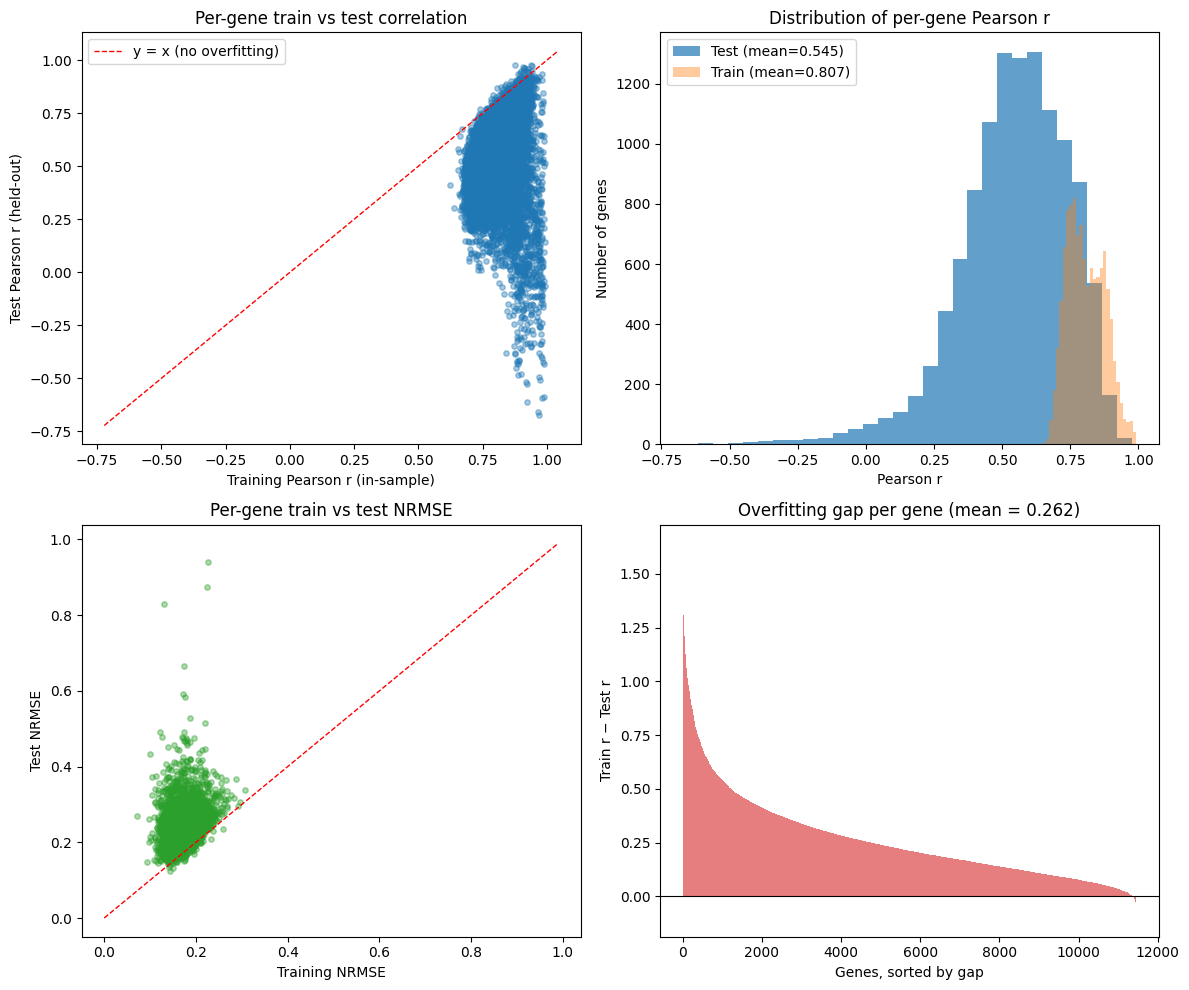

Mean train r: 0.8073  |  Mean test r: 0.5449  |  Mean gap: 0.2624
Mean train NRMSE: 0.1722  |  Mean test NRMSE: 0.2214


In [64]:
genes_common = list(dream_pearson_test.keys())
train_r = np.array([dream_pearson_train[g] for g in genes_common])
test_r  = np.array([dream_pearson_test[g] for g in genes_common])
train_nrmse = np.array([dream_nrmse_train[g] for g in genes_common])
test_nrmse  = np.array([dream_nrmse_test[g] for g in genes_common])
gap = train_r - test_r

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax = axes[0, 0]
ax.scatter(train_r, test_r, alpha=0.4, s=15)
lims = [min(train_r.min(), test_r.min()) - 0.05, max(train_r.max(), test_r.max()) + 0.05]
ax.plot(lims, lims, 'r--', linewidth=1, label='y = x (no overfitting)')
ax.set_xlabel('Training Pearson r (in-sample)')
ax.set_ylabel('Test Pearson r (held-out)')
ax.set_title('Per-gene train vs test correlation')
ax.legend()

ax = axes[0, 1]
ax.hist(test_r, bins=30, alpha=0.7, label=f'Test (mean={test_r.mean():.3f})', color='tab:blue')
ax.hist(train_r, bins=30, alpha=0.4, label=f'Train (mean={train_r.mean():.3f})', color='tab:orange')
ax.set_xlabel('Pearson r')
ax.set_ylabel('Number of genes')
ax.set_title('Distribution of per-gene Pearson r')
ax.legend()

ax = axes[1, 0]
ax.scatter(train_nrmse, test_nrmse, alpha=0.4, s=15, color='tab:green')
lims2 = [0, max(np.nanmax(train_nrmse), np.nanmax(test_nrmse)) + 0.05]
ax.plot(lims2, lims2, 'r--', linewidth=1)
ax.set_xlabel('Training NRMSE')
ax.set_ylabel('Test NRMSE')
ax.set_title('Per-gene train vs test NRMSE')

ax = axes[1, 1]
order = np.argsort(gap)[::-1]
ax.bar(range(len(gap)), gap[order], width=1.0, color='tab:red', alpha=0.6)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xlabel('Genes, sorted by gap')
ax.set_ylabel('Train r − Test r')
ax.set_title(f'Overfitting gap per gene (mean = {gap.mean():.3f})')

plt.tight_layout()
plt.savefig('protein_model_train_vs_test.png', dpi=150)
plt.savefig('models/protein_model_train_vs_test.png', dpi=150)
plt.show()

print(f"Mean train r: {train_r.mean():.4f}  |  Mean test r: {test_r.mean():.4f}  |  Mean gap: {gap.mean():.4f}")
print(f"Mean train NRMSE: {np.nanmean(train_nrmse):.4f}  |  Mean test NRMSE: {np.nanmean(test_nrmse):.4f}")

### OVERVIEW FOR THE RF MODEL

#### 1. Inputs
* **Features (X):** DepMap-only robust z-scored mRNA (`E_final`, 16,385 protein-coding genes) for the **369 cell lines** that also have proteomics.
* **Target (y):** Gygi mass-spectrometry protein levels. Isoforms were rolled up per gene (11,730 single-isoform genes; 385 collapsed by row mean when isoforms agree above a permutation-null Spearman threshold of 0.0972; 11 by row max otherwise), mapped to Cellosaurus and to Ensembl IDs (12,036 matched), then scaled with
  $$\text{scaled\_protein} = \tanh\left(\frac{\text{protein}}{k_{Pr}}\right), \quad k_{Pr} = 1.4826 \times \text{IQR} = 1.3682$$
* **Genes modeled:** 11,459 of the 11,716 overlapping genes (those with ≥ 20 measured cell lines).

#### 2. Per-gene model
1. **Stage 1:** OLS linear regression on the gene's own mRNA.
2. **Stage 2:** cuML GPU Random Forest on all 16,385 mRNA features (`max_depth=3`, `n_estimators=100`, `max_features='sqrt'`, `bootstrap=True`, `n_bins=min(32, n)`, `n_streams=1`, `random_state=42`).
3. **Ensemble:** 0.5 × Stage 1 + 0.5 × Stage 2.

A single 70/30 train/test split (`random_state=42`) is used for evaluation. The models are then refit on all measured cell lines and used to fill the missing protein values of those 369 cell lines (`protein_predicted`).

#### 3. Results (held-out 30%)
* Mean test Spearman r: **0.5072** (used for the Q1–Q4 confidence tiers)
* Mean train / test Pearson r: **0.8073 / 0.5449** (gap 0.2624)
* Mean train / test NRMSE: **0.1722 / 0.2214**
* 0 genes skipped. The 91,224 values still missing in `protein_predicted` belong to the 257 genes with fewer than 20 measured cell lines.


In [65]:
print(len(dream_pearson_test), len(dream_pearson_train))
print(len(set(dream_pearson_test.keys()) & set(valid_predict_genes)))

11459 11459
11459


### GRAPH FORMATIONS

#### Cosine similarity on raw mRNA features

In [66]:
# E_final: cell lines × genes (Cellosaurus-indexed)
X = E_final.copy()
cell_lines = X.index.tolist()
print(f"Cell lines: {len(cell_lines)}, Features: {X.shape[1]}")
print(f"NaNs in E_final at similarity step: {E_final.isna().sum().sum()} (should be 0)")

# NaN → 0 for cosine computation as a safety fallback
X_filled = X.fillna(0.0).values.astype(np.float32)

# Full pairwise cosine similarity between cell-line profiles.
# NOTE: this is cosine similarity, NOT Pearson correlation. The cosine-Pearson
# identity requires centering along the axis being summed (each cell line's
# profile across genes). E_final is centered per GENE (column-wise, by median),
# which does not row-center. Treat this as cosine similarity on robust-z-scored
# profiles and do not cite the cosine-Pearson equivalence for it.
sim_matrix = cosine_similarity(X_filled)
np.fill_diagonal(sim_matrix, 0.0)  # no self-loops

sim_df = pd.DataFrame(sim_matrix, index=cell_lines, columns=cell_lines)
print(f"Similarity matrix: {sim_df.shape}")
print(f"Value range: [{sim_matrix.min():.4f}, {sim_matrix.max():.4f}]")
print(f"Mean off-diagonal: {sim_matrix[np.triu_indices_from(sim_matrix, k=1)].mean():.4f}")

Cell lines: 1399, Features: 16385
NaNs in E_final at similarity step: 0 (should be 0)
Similarity matrix: (1399, 1399)
Value range: [-0.0635, 0.9526]
Mean off-diagonal: 0.1243


#### k-NN graph: keep top-K neighbors per cell line

In [67]:
K = 15

edges = []
for i, cl in enumerate(cell_lines):
    row = sim_df.iloc[i].drop(cl)
    top_k = row.nlargest(K)
    for neighbor, weight in top_k.items():
        edges.append((cl, neighbor, float(weight)))

edges_df = pd.DataFrame(edges, columns=['cell_line_a', 'cell_line_b', 'cosine_similarity'])
print(f"Directed edges (before symmetrisation): {len(edges_df)}")

# Symmetrise: if A→B exists but B→A doesn't, keep A→B anyway
# (k-NN is inherently asymmetric; we keep the union)
edge_set = set()
sym_edges = []
for _, row in edges_df.iterrows():
    a, b = row['cell_line_a'], row['cell_line_b']
    key = tuple(sorted([a, b]))
    if key not in edge_set:
        edge_set.add(key)
        sym_edges.append(row)

edges_sym = pd.DataFrame(sym_edges)
print(f"Undirected edges (symmetrised): {len(edges_sym)}")

Directed edges (before symmetrisation): 20985
Undirected edges (symmetrised): 15398


#### Lineage metadata

In [68]:
lineage_by_cello = (
    df_depmap_sample.dropna(subset=['RRID'])
    .drop_duplicates('RRID')
    .set_index('RRID')['lineage']
)

node_lineage = pd.Series(
    {c: lineage_by_cello.get(c, 'Unknown') for c in cell_lines},
    name='lineage'
)

# Tag edges with same-lineage flag (for downstream analysis, NOT filtering)
edges_sym['lineage_a'] = edges_sym['cell_line_a'].map(node_lineage)
edges_sym['lineage_b'] = edges_sym['cell_line_b'].map(node_lineage)
edges_sym['same_lineage'] = edges_sym['lineage_a'] == edges_sym['lineage_b']

same_pct = edges_sym['same_lineage'].mean() * 100
print(f"Same-lineage edges: {same_pct:.1f}%")
print(f"\nLineage distribution in nodes:")
print(node_lineage.value_counts().head(10))

# Coverage check — unmapped profiles won't have lineage
n_unknown = (node_lineage == 'Unknown').sum()
print(f"\nNodes with Unknown lineage: {n_unknown} / {len(cell_lines)} "
      f"({100*n_unknown/len(cell_lines):.1f}%) — profiles without RRID mapping in DepMap sample_info")

Same-lineage edges: 54.6%

Lineage distribution in nodes:
lineage
lung                      210
blood                     104
skin                       85
central_nervous_system     84
lymphocyte                 83
colorectal                 73
ovary                      65
breast                     63
soft_tissue                59
upper_aerodigestive        57
Name: count, dtype: int64

Nodes with Unknown lineage: 0 / 1399 (0.0%) — profiles without RRID mapping in DepMap sample_info


#### Save

In [69]:
edges_sym.to_csv('cellline_knn_edges.csv', index=False)

nodes_df = pd.DataFrame({'cell_line': cell_lines, 'lineage': node_lineage.values})
nodes_df.to_csv('cellline_nodes.csv', index=False)

print(f"\nSaved: cellline_knn_edges.csv ({len(edges_sym)} edges)")
print(f"Saved: cellline_nodes.csv ({len(nodes_df)} nodes)")


Saved: cellline_knn_edges.csv (15398 edges)
Saved: cellline_nodes.csv (1399 nodes)


#### Lineage-mismatch decomposition

In [70]:
print("Actual lineage labels (verify adjacency table matches these):")
print(node_lineage.value_counts().head(20))

# ── EDIT frozensets below if your lineage strings differ ──
LINEAGE_ADJACENCY = {
    frozenset(['esophagus', 'upper_aerodigestive']),
    frozenset(['esophagus', 'stomach']),
    frozenset(['bile_duct', 'pancreas']),
    frozenset(['bile_duct', 'liver']),
    frozenset(['uterus', 'ovary']),
    frozenset(['uterus', 'cervix']),
    frozenset(['blood', 'lymphocyte']),
    frozenset(['soft_tissue', 'bone']),
    frozenset(['kidney', 'urinary_tract']),
    frozenset(['colorectal', 'gastric']),
}

def classify_mismatch(lin_a, lin_b):
    if lin_a == lin_b:
        return 'match'
    if frozenset([lin_a, lin_b]) in LINEAGE_ADJACENCY:
        return 'adjacent (plausible biology)'
    return 'distant (unexplained)'

mismatched = edges_sym[~edges_sym['same_lineage']].copy()
mismatched['category'] = mismatched.apply(
    lambda r: classify_mismatch(r['lineage_a'], r['lineage_b']), axis=1)

total_edges = len(edges_sym)
mismatch_rate = len(mismatched) / total_edges
breakdown = mismatched['category'].value_counts()

print(f"\n{'─' * 55}")
print(f"Total edges:    {total_edges:,}")
print(f"Mismatch rate:  {mismatch_rate:.1%}")
print(f"\nMismatch decomposition (of mismatched edges only):")
print(breakdown)
print(f"\nAs % of ALL edges:")
print((breakdown / total_edges * 100).round(1).astype(str) + '%')

adjacent_n = breakdown.get('adjacent (plausible biology)', 0)
adjacent_frac = adjacent_n / len(mismatched) if len(mismatched) else 0.0
print(f"\nOf mismatched edges: {adjacent_frac:.1%} adjacency-explainable, "
      f"{1 - adjacent_frac:.1%} remain unexplained")

# ── Top unexplained lineage pairs ──
distant = mismatched[mismatched['category'] == 'distant (unexplained)'].copy()
distant['pair'] = distant.apply(
    lambda r: tuple(sorted([r['lineage_a'], r['lineage_b']])), axis=1)
print(f"\nTop 10 unexplained lineage pairs:")
print(distant['pair'].value_counts().head(10))

Actual lineage labels (verify adjacency table matches these):
lineage
lung                         210
blood                        104
skin                          85
central_nervous_system        84
lymphocyte                    83
colorectal                    73
ovary                         65
breast                        63
soft_tissue                   59
upper_aerodigestive           57
pancreas                      53
bile_duct                     41
gastric                       41
uterus                        40
kidney                        39
fibroblast                    38
bone                          38
urinary_tract                 37
peripheral_nervous_system     35
esophagus                     32
Name: count, dtype: int64

───────────────────────────────────────────────────────
Total edges:    15,398
Mismatch rate:  45.4%

Mismatch decomposition (of mismatched edges only):
category
distant (unexplained)           5926
adjacent (plausible biology)    1068
Name: c

#### Graph statistics + visualisation

Nodes: 1399
Edges: 15398
Connected components: 1
Density: 0.015746
Degree — min: 15, max: 75, mean: 22.0, median: 20.0


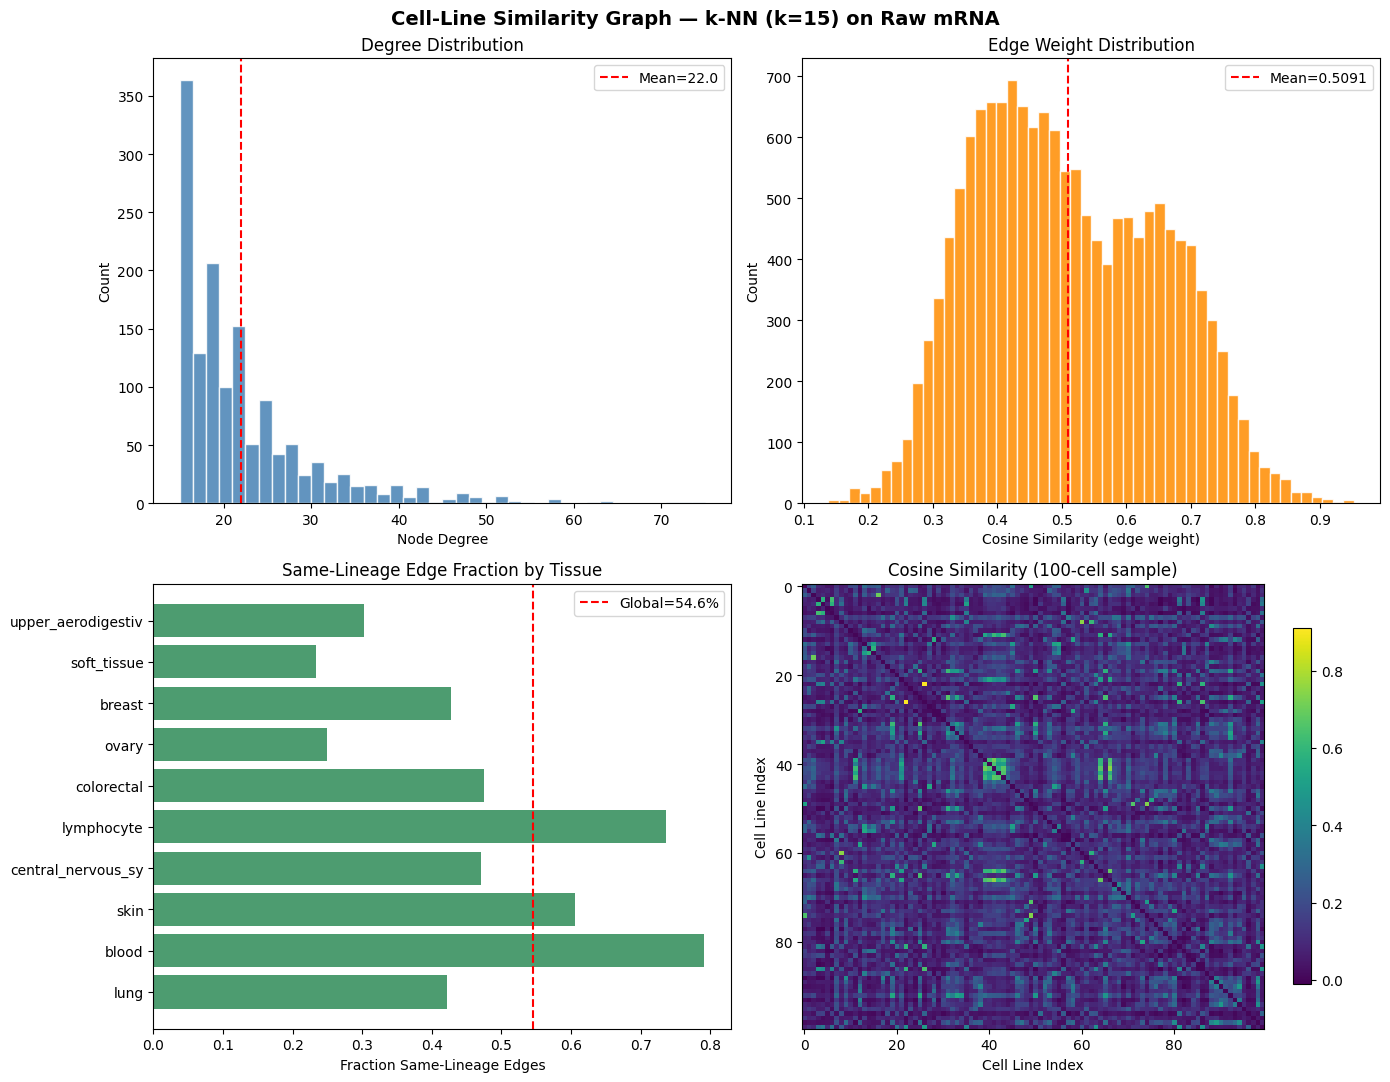

In [71]:
G = nx.Graph()
G.add_nodes_from(cell_lines)
for _, row in edges_sym.iterrows():
    G.add_edge(row['cell_line_a'], row['cell_line_b'], weight=row['cosine_similarity'])

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")
print(f"Connected components: {nx.number_connected_components(G)}")
print(f"Density: {nx.density(G):.6f}")

degrees = [d for _, d in G.degree()]
print(f"Degree — min: {min(degrees)}, max: {max(degrees)}, mean: {np.mean(degrees):.1f}, median: {np.median(degrees):.1f}")

# ── 4-panel diagnostic plot ──
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# 1. Degree distribution
axes[0, 0].hist(degrees, bins=40, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].axvline(np.mean(degrees), color='red', linestyle='--', label=f'Mean={np.mean(degrees):.1f}')
axes[0, 0].set_xlabel('Node Degree')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('Degree Distribution')
axes[0, 0].legend()

# 2. Edge weight distribution
weights = edges_sym['cosine_similarity'].values
axes[0, 1].hist(weights, bins=50, color='darkorange', edgecolor='white', alpha=0.85)
axes[0, 1].axvline(np.mean(weights), color='red', linestyle='--', label=f'Mean={np.mean(weights):.4f}')
axes[0, 1].set_xlabel('Cosine Similarity (edge weight)')
axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('Edge Weight Distribution')
axes[0, 1].legend()

# 3. Same-lineage fraction by top lineages
top_lineages = node_lineage.value_counts().head(10).index.tolist()
lineage_stats = []
for lin in top_lineages:
    lin_edges = edges_sym[(edges_sym['lineage_a'] == lin) | (edges_sym['lineage_b'] == lin)]
    if len(lin_edges) > 0:
        frac = lin_edges['same_lineage'].mean()
        lineage_stats.append((lin, frac, len(lin_edges)))

lin_names = [s[0][:18] for s in lineage_stats]
lin_fracs = [s[1] for s in lineage_stats]
bars = axes[1, 0].barh(lin_names, lin_fracs, color='seagreen', alpha=0.85)
axes[1, 0].axvline(same_pct / 100, color='red', linestyle='--', label=f'Global={same_pct:.1f}%')
axes[1, 0].set_xlabel('Fraction Same-Lineage Edges')
axes[1, 0].set_title('Same-Lineage Edge Fraction by Tissue')
axes[1, 0].legend()

# 4. Similarity heatmap (sampled — full cell×cell matrix too dense)
np.random.seed(42)
sample_idx = np.random.choice(len(cell_lines), size=min(100, len(cell_lines)), replace=False)
sample_idx.sort()
sim_sample = sim_matrix[np.ix_(sample_idx, sample_idx)]
im = axes[1, 1].imshow(sim_sample, cmap='viridis', aspect='auto')
axes[1, 1].set_title(f'Cosine Similarity (100-cell sample)')
axes[1, 1].set_xlabel('Cell Line Index')
axes[1, 1].set_ylabel('Cell Line Index')
plt.colorbar(im, ax=axes[1, 1], shrink=0.8)

plt.suptitle('Cell-Line Similarity Graph — k-NN (k=15) on Raw mRNA', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('cellline_graph_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

#### CELL LINE GRAPH VISUALIZATION

In [72]:
# ── Color scheme: top lineages get distinct colors, rest → grey ──
top_n = 12
lineage_counts = node_lineage.value_counts()
top_lineages = lineage_counts.head(top_n).index.tolist()

# Qualitative palette (colorblind-friendly, tab20 basis)
palette = plt.cm.tab20(np.linspace(0, 1, 20))
lineage_colors = {}
for i, lin in enumerate(top_lineages):
    lineage_colors[lin] = palette[i]
default_color = (0.75, 0.75, 0.75, 0.6)  # grey for minor lineages

node_color_list = [
    lineage_colors.get(node_lineage.get(n, 'Unknown'), default_color)
    for n in G.nodes()
]

# ── Degree → node size (log-scaled to tame hubs) ──
degrees_dict = dict(G.degree())
node_sizes = [3 + 2 * np.log1p(degrees_dict[n]) for n in G.nodes()]

# ── Layout: spring with higher k (spacing) and more iterations for separation ──
print(f"Computing layout (takes ~30s for {G.number_of_nodes():,} nodes)...")
pos = nx.spring_layout(G, k=0.35, iterations=80, seed=42, weight='weight')

Computing layout (takes ~30s for 1,399 nodes)...


#### FIGURE 1: Full network, colored by lineage

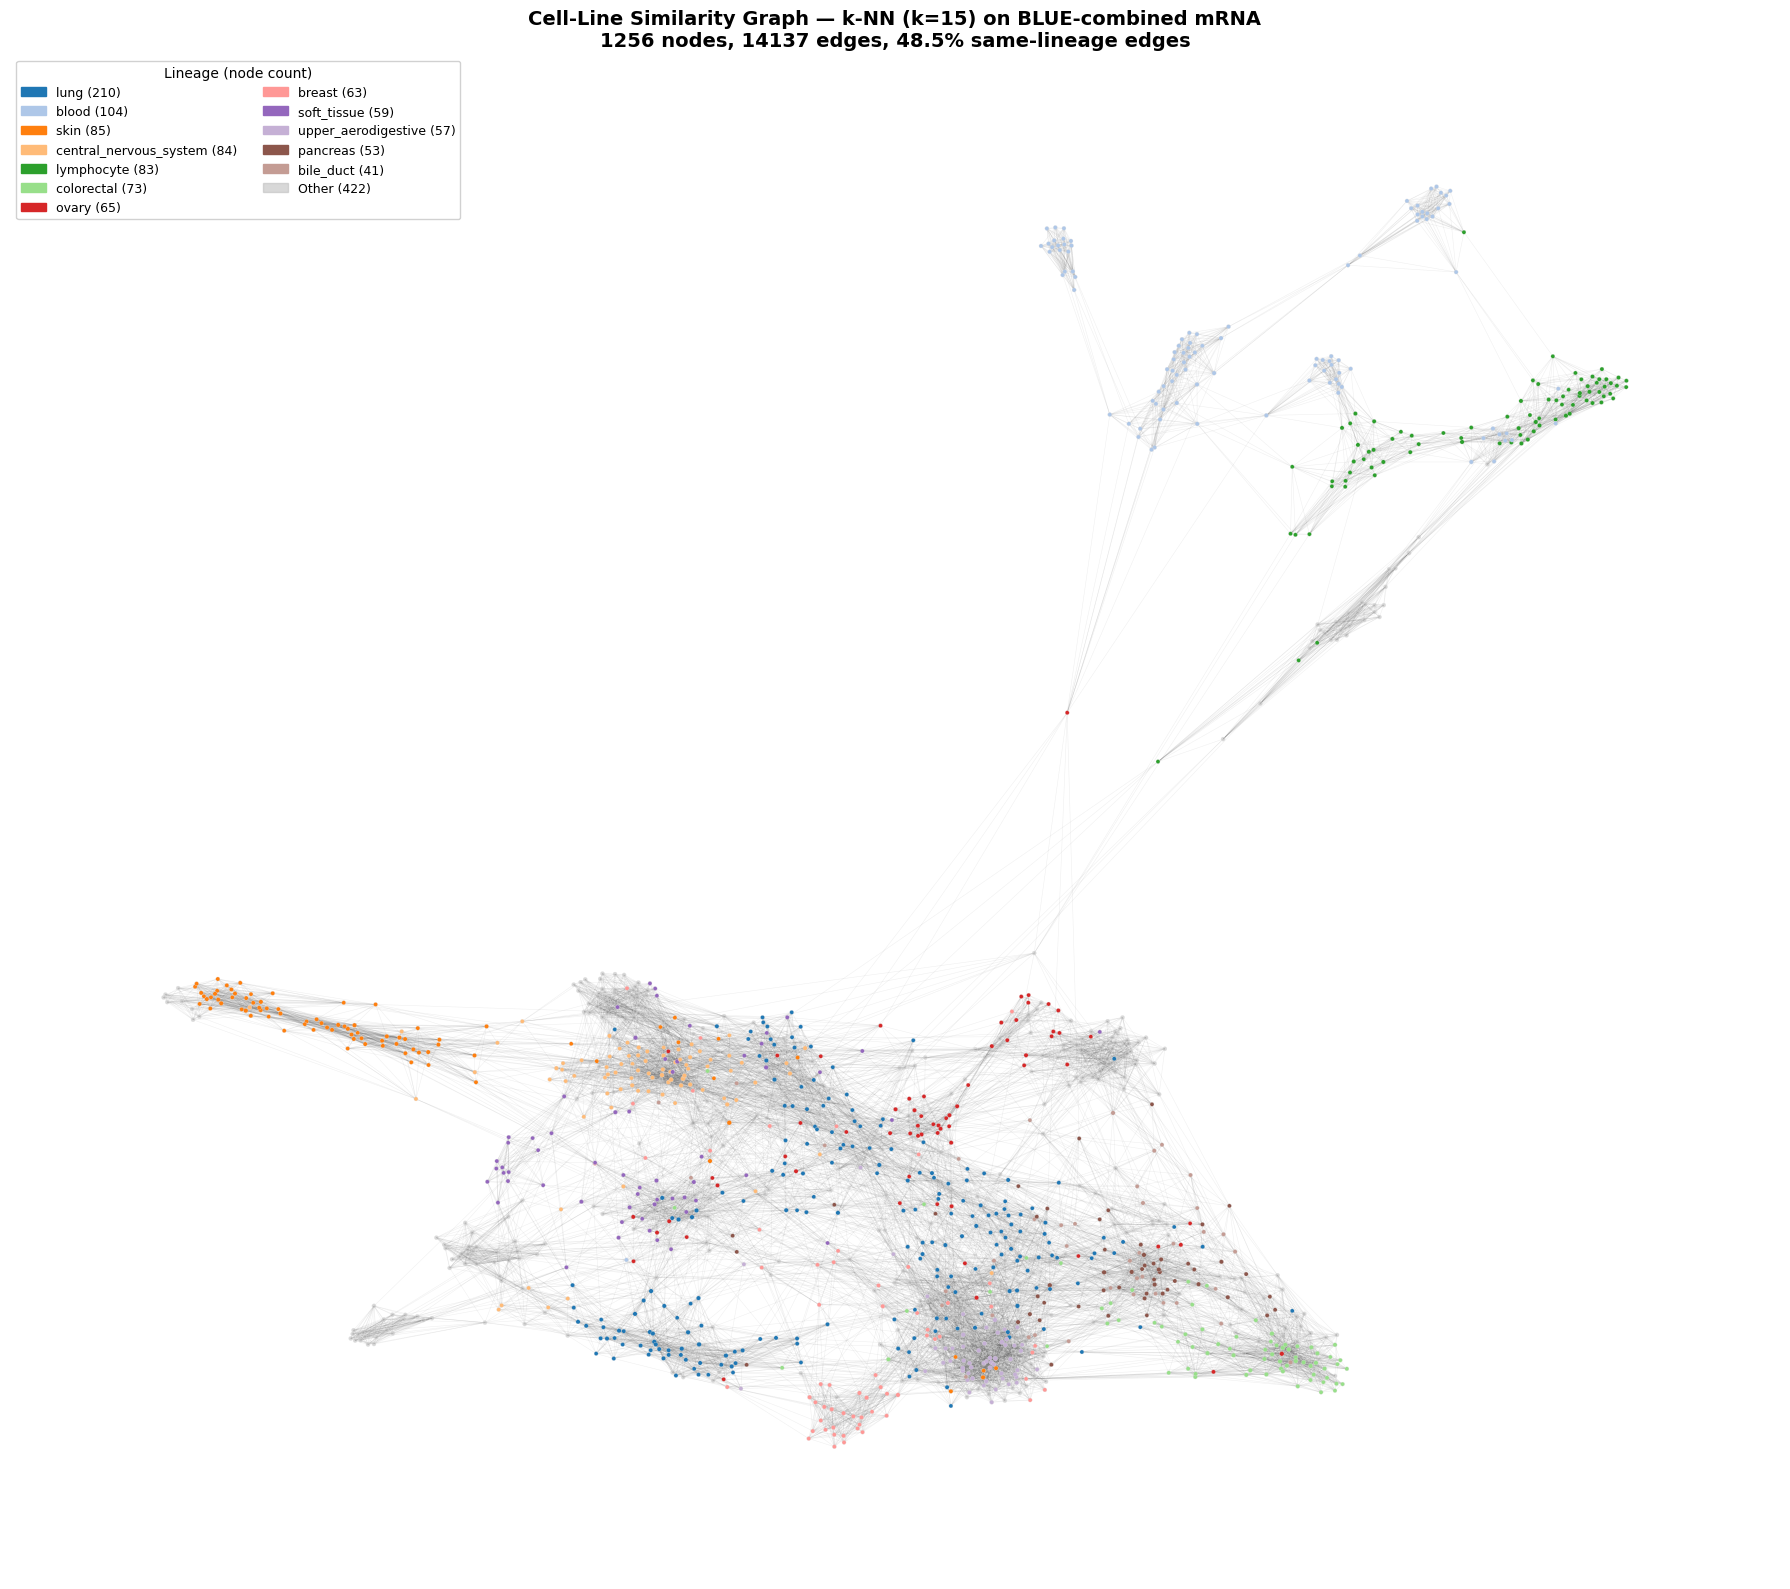

In [73]:
fig, ax = plt.subplots(figsize=(18, 16))

# Edges first (very thin, low alpha)
nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.08, width=0.4, edge_color='#404040')

# Nodes on top
nx.draw_networkx_nodes(G, pos, ax=ax,
                       node_color=node_color_list,
                       node_size=node_sizes,
                       linewidths=0.2,
                       edgecolors='#e0e0e0')

# Legend
legend_patches = [mpatches.Patch(color=lineage_colors[lin],
                                  label=f"{lin} ({lineage_counts[lin]})")
                  for lin in top_lineages]
legend_patches.append(mpatches.Patch(color=default_color, label=f"Other ({lineage_counts.iloc[top_n:].sum()})"))
ax.legend(handles=legend_patches, loc='upper left', fontsize=9,
          framealpha=0.9, ncol=2, title='Lineage (node count)')

ax.set_title('Cell-Line Similarity Graph — k-NN (k=15) on BLUE-combined mRNA\n'
             f'1256 nodes, 14137 edges, 48.5% same-lineage edges',
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('cellline_graph_full.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

#### FIGURE 2: Subgraph of top-3 lineages

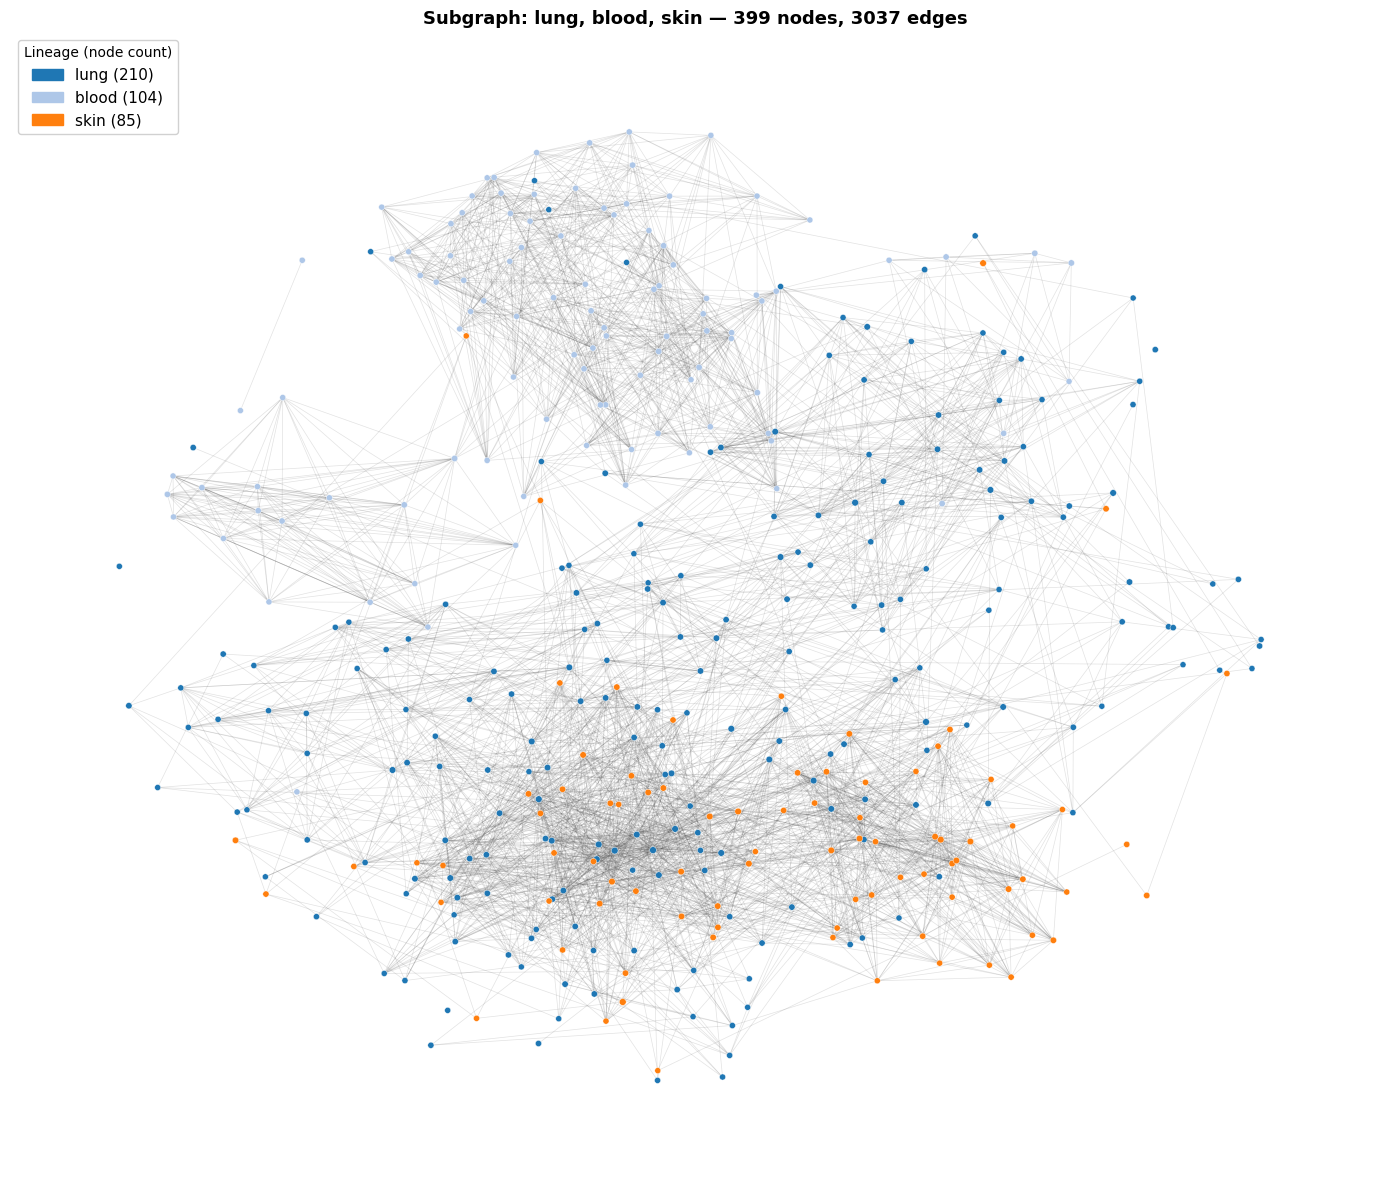

In [74]:
top3 = lineage_counts.head(3).index.tolist()  # lung, blood, lymphocyte
sub_nodes = [n for n in G.nodes() if node_lineage.get(n, 'Unknown') in top3]
G_sub = G.subgraph(sub_nodes).copy()

pos_sub = nx.spring_layout(G_sub, k=0.5, iterations=60, seed=42, weight='weight')

sub_colors = [lineage_colors.get(node_lineage.get(n, 'Unknown'), default_color)
              for n in G_sub.nodes()]
sub_sizes = [8 + 4 * np.log1p(degrees_dict[n]) for n in G_sub.nodes()]

fig2, ax2 = plt.subplots(figsize=(14, 12))
nx.draw_networkx_edges(G_sub, pos_sub, ax=ax2, alpha=0.15, width=0.5, edge_color='#404040')
nx.draw_networkx_nodes(G_sub, pos_sub, ax=ax2,
                       node_color=sub_colors,
                       node_size=sub_sizes,
                       linewidths=0.3,
                       edgecolors='white')

legend2 = [mpatches.Patch(color=lineage_colors[lin],
                           label=f"{lin} ({lineage_counts[lin]})")
           for lin in top3]
ax2.legend(handles=legend2, loc='upper left', fontsize=11, framealpha=0.9,
           title='Lineage (node count)')
ax2.set_title(f'Subgraph: {", ".join(top3)} — {G_sub.number_of_nodes()} nodes, '
              f'{G_sub.number_of_edges()} edges', fontsize=13, fontweight='bold')
ax2.axis('off')
plt.tight_layout()
plt.savefig('cellline_graph_top3_lineages.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()

#### FIGURE 3: Hub analysis - degree vs same-lineage neighbor fraction

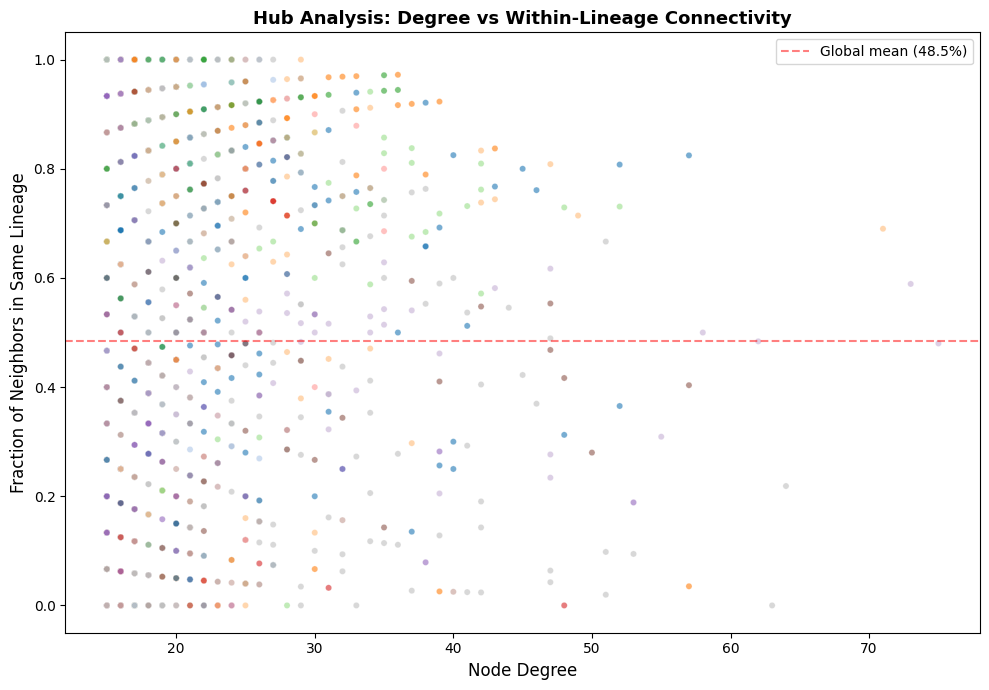

Done — 3 figures saved.


In [75]:
fig3, ax3 = plt.subplots(figsize=(10, 7))

node_list = list(G.nodes())
deg_arr = np.array([degrees_dict[n] for n in node_list])
same_lin_frac = []
for n in node_list:
    neighbors = list(G.neighbors(n))
    if len(neighbors) == 0:
        same_lin_frac.append(0)
        continue
    n_lin = node_lineage.get(n, 'Unknown')
    same = sum(1 for nb in neighbors if node_lineage.get(nb, 'Unknown') == n_lin)
    same_lin_frac.append(same / len(neighbors))
same_lin_frac = np.array(same_lin_frac)

scatter_colors = [lineage_colors.get(node_lineage.get(n, 'Unknown'), default_color)
                  for n in node_list]
ax3.scatter(deg_arr, same_lin_frac, c=scatter_colors, s=20, alpha=0.6, edgecolors='white', linewidths=0.3)
ax3.axhline(0.485, color='red', linestyle='--', alpha=0.5, label='Global mean (48.5%)')
ax3.set_xlabel('Node Degree', fontsize=12)
ax3.set_ylabel('Fraction of Neighbors in Same Lineage', fontsize=12)
ax3.set_title('Hub Analysis: Degree vs Within-Lineage Connectivity', fontsize=13, fontweight='bold')
ax3.legend(fontsize=10)
plt.tight_layout()
plt.savefig('cellline_graph_hub_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Done — 3 figures saved.")

#### COMPLETE BI-PARTITE GRAPH FORMATION

In [76]:
def compute_bipartite_evidence(
    E_final,                   # (n_cells × n_genes) mRNA expression
    protein_predicted,         # (m_cells × p_genes) RF-predicted protein levels
    gene_confidence_scores,    # dict: gene → Spearman r  (node attribute only)
    confidence_tiers,          # dict: gene → tier label   (node attribute only)
    node_lineage,              # Series: cell_line → lineage
    threshold=2.0              # |θ̂| cutoff for edge inclusion
):
    '''
    Build bipartite evidence edges between genes and cell lines.

    θ̂(g, c) = (z_E(g,c) + z_Pr(g,c)) / √2    — genes with both mRNA & protein
    θ̂(g, c) = z_E(g,c)                         — mRNA-only genes

    where:
        z_E  = gene-wise z-scored mRNA expression
        z_Pr = gene-wise z-scored RF-predicted protein level

    Equal-weighted combination: no confidence weighting on the protein arm.
    gene_confidence_scores feeds node attributes (rf_spearman_r) only.

    Sparsification: keep edges where |θ̂| > threshold.
    '''

    sqrt2 = np.sqrt(2.0)

    # Robust z-score, median / MAD, matching the mRNA pre-processing pipeline.
    # scipy.stats.median_abs_deviation defaults to scale=1.0 (raw MAD), so
    # scale='normal' is passed explicitly to apply the 1.4826 constant.
    # nan_policy='omit' preserves the NaN-skipping behaviour of the .std() calls
    # this replaces; without it a single NaN would propagate to the whole column.

    med_e = E_final.median(axis=0)
    mad_e = E_final.apply(median_abs_deviation, axis=0, scale='normal', nan_policy='omit')

    mad_e_safe = mad_e.copy()
    mad_e_safe[mad_e_safe == 0] = 1.0   # avoid div-by-zero; forced to 0 below

    E_z = ((E_final - med_e) / mad_e_safe).astype(np.float32)
    E_z.loc[:, mad_e == 0] = 0.0

    n_zero_var_e = int((mad_e == 0).sum())
    if n_zero_var_e > 0:
        print(f"  mRNA: {n_zero_var_e} genes with MAD=0 -> z set to 0")

    # Gene-wise robust z-score: protein.
    # protein_predicted is tanh-bounded to [-1, 1], so it genuinely needs
    # standardising before it can be combined with z_E under Stouffer's method.
    # Using the same estimator family as the mRNA arm keeps the two comparable.
    med_p = protein_predicted.median(axis=0)
    mad_p = protein_predicted.apply(median_abs_deviation, axis=0, scale='normal', nan_policy='omit')

    mad_p_safe = mad_p.copy()
    mad_p_safe[mad_p_safe == 0] = 1.0

    Pr_z = ((protein_predicted - med_p) / mad_p_safe).astype(np.float32)
    Pr_z.loc[:, mad_p == 0] = 0.0

    n_zero_var_p = int((mad_p == 0).sum())
    if n_zero_var_p > 0:
        print(f"  Protein: {n_zero_var_p} genes with MAD=0 -> z set to 0")

    # ── 3. Combine: θ̂ = (z_E + z_Pr) / √2 ──────────────
    #    mRNA-only genes: θ̂ = z_E (no division by √2 — single source)
    # float64: the combined (z_E + z_Pr)/√2 values are float64; writing them into a float32
    # frame made pandas upcast those columns with a FutureWarning (an error in future pandas).
    # Starting in float64 gives the same numbers without the implicit upcast.
    theta = E_z.astype(np.float64)

    olap_genes = sorted(set(theta.columns) & set(Pr_z.columns))
    olap_cells = sorted(set(theta.index)   & set(Pr_z.index))

    if olap_genes and olap_cells:
        Pr_olap = Pr_z.reindex(index=olap_cells, columns=olap_genes).fillna(0.0)
        # Equal-weighted average: (z_E + z_Pr) / √2
        theta.loc[olap_cells, olap_genes] = (
            (theta.loc[olap_cells, olap_genes].values + Pr_olap.values) / sqrt2
        )

    # ── 4. Threshold → edge list ────────────────────────
    theta_np = np.nan_to_num(theta.values, nan=0.0)
    abs_t    = np.abs(theta_np)
    ri, ci   = np.where(abs_t > threshold)

    genes = theta.columns.tolist()
    cells = theta.index.tolist()

    pr_cell_set = set(olap_cells)
    pr_gene_set = set(olap_genes)

    cell_arr = np.array([cells[r] for r in ri])
    gene_arr = np.array([genes[c] for c in ci])

    edges_df = pd.DataFrame({
        'gene':          gene_arr,
        'cell_line':     cell_arr,
        'theta':         theta_np[ri, ci],
        'abs_theta':     abs_t[ri, ci],
        'direction':     np.where(theta_np[ri, ci] > 0, 'up', 'down'),
        'evidence_type': np.where(
            np.isin(cell_arr, list(pr_cell_set)) & np.isin(gene_arr, list(pr_gene_set)),
            'mRNA+protein', 'mRNA_only'
        ),
    })

    # ── 5. Gene node attributes ────────────────────────-
    g_degree   = edges_df.groupby('gene').size()
    g_mean_abs = edges_df.groupby('gene')['abs_theta'].mean()
    g_up_count = edges_df[edges_df['direction'] == 'up'].groupby('gene').size()

    gene_nodes = pd.DataFrame(index=genes)
    gene_nodes.index.name = 'gene_id'

    gene_nodes['mean_expression']   = E_final[genes].mean(axis=0)
    gene_nodes['std_expression']    = E_final[genes].std(axis=0, ddof=1)
    gene_nodes['n_cells_measured']  = E_final[genes].notna().sum(axis=0)
    gene_nodes['has_protein_model'] = gene_nodes.index.isin(gene_confidence_scores)
    gene_nodes['rf_spearman_r']     = pd.Series(gene_confidence_scores)
    gene_nodes['confidence_tier']   = pd.Series(confidence_tiers).reindex(genes).fillna('no_model')
    gene_nodes['degree']            = g_degree.reindex(genes).fillna(0).astype(int)
    gene_nodes['mean_abs_theta']    = g_mean_abs.reindex(genes)
    gene_nodes['up_fraction']       = (g_up_count.reindex(genes).fillna(0)
                                       / gene_nodes['degree'].clip(lower=1))

    # ── 6. Cell-line node attributes ────────────────────
    c_degree   = edges_df.groupby('cell_line').size()
    c_mean_abs = edges_df.groupby('cell_line')['abs_theta'].mean()

    cell_nodes = pd.DataFrame(index=cells)
    cell_nodes.index.name = 'cell_line_id'

    cell_nodes['lineage']     = node_lineage.reindex(cells).fillna('Unknown')
    cell_nodes['has_protein'] = cell_nodes.index.isin(pr_cell_set)
    cell_nodes['degree']      = c_degree.reindex(cells).fillna(0).astype(int)
    cell_nodes['mean_abs_theta'] = c_mean_abs.reindex(cells)

    return edges_df, gene_nodes, cell_nodes, theta

In [77]:
# ── Run the bipartite evidence computation ──
edges_df, gene_nodes, cell_nodes, theta_matrix = compute_bipartite_evidence(
    E_final=E_final,
    protein_predicted=protein_predicted,
    gene_confidence_scores=gene_confidence_scores,
    confidence_tiers=confidence_tiers,
    node_lineage=node_lineage,
    threshold=2.0
)

# ── Quick summary ──
print(f"Edges:      {len(edges_df):,}")
print(f"Gene nodes: {len(gene_nodes)}  (with edges: {(gene_nodes['degree'] > 0).sum()})")
print(f"Cell nodes: {len(cell_nodes)}  (with edges: {(cell_nodes['degree'] > 0).sum()})")
print(f"θ̂ matrix:  {theta_matrix.shape}")
print()
print(f"Direction:     up={int((edges_df['direction']=='up').sum()):,}  "
      f"down={int((edges_df['direction']=='down').sum()):,}")
print(f"Evidence type: mRNA+protein={int((edges_df['evidence_type']=='mRNA+protein').sum()):,}  "
      f"mRNA_only={int((edges_df['evidence_type']=='mRNA_only').sum()):,}")

# ── Attach gene symbols to gene_nodes via HPA crosswalk ──
# hpa_gene_map is built in the RAM-cleanup cell (before training), where df_hpa is freed.
if 'hpa_gene_map' not in globals():
    hpa_gene_map = (
        df_hpa[['Gene', 'Gene name']]
        .drop_duplicates()
        .set_index('Gene')['Gene name']
        .to_dict()
    )
gene_nodes['gene_symbol'] = gene_nodes.index.map(hpa_gene_map)

n_mapped = gene_nodes['gene_symbol'].notna().sum()
n_total = len(gene_nodes)
print(f"\nGene symbol mapping: {n_mapped}/{n_total} genes resolved ({100*n_mapped/n_total:.1f}%)")
print(f"Unmapped genes (no symbol): {n_total - n_mapped}")

print("\nTop 5 genes by degree:")
print(gene_nodes.nlargest(5, 'degree')[['gene_symbol', 'degree', 'mean_abs_theta', 'confidence_tier']])
print()
print("Top 5 cell lines by degree:")
print(cell_nodes.nlargest(5, 'degree')[['degree', 'mean_abs_theta', 'lineage']])

# theta_matrix is not used past this cell (1399 x 16385); free it before building G.
del theta_matrix
_ = gc.collect()


  mRNA: 4 genes with MAD=0 -> z set to 0
Edges:      2,775,998
Gene nodes: 16385  (with edges: 16292)
Cell nodes: 1399  (with edges: 1399)
θ̂ matrix:  (1399, 16385)

Direction:     up=2,111,372  down=664,626
Evidence type: mRNA+protein=577,876  mRNA_only=2,198,122

Gene symbol mapping: 16385/16385 genes resolved (100.0%)
Unmapped genes (no symbol): 0

Top 5 genes by degree:
                gene_symbol  degree  mean_abs_theta confidence_tier
gene_id                                                            
ENSG00000173040        EVC2     660       29.348116        Q4 (Low)
ENSG00000198046      ZNF667     628       23.809246       Q2 (High)
ENSG00000197928      ZNF677     610       23.631336        no_model
ENSG00000125850       OVOL2     601        7.540678    Q1 (Highest)
ENSG00000175707        KDF1     601        9.914370    Q1 (Highest)

Top 5 cell lines by degree:
              degree  mean_abs_theta              lineage
cell_line_id                                             
CV

### Extend G with gene nodes + bipartite evidence edges

In [78]:
# G already has: cell-line nodes + similarity edges (cosine k-NN)
# This cell adds: gene nodes + gene↔cell evidence edges from θ̂
# Result: one heterogeneous graph with two node types, two edge types

print(f"G before extension: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# ── 1. Tag existing cell-cell edges ──
for u, v in G.edges():
    G[u][v]['edge_type'] = 'similarity'

# ── 2. Annotate existing cell-line nodes ──
for cid, row in cell_nodes.iterrows():
    if cid in G:
        G.nodes[cid]['node_type']       = 'cell_line'
        G.nodes[cid]['lineage']         = str(row['lineage'])
        G.nodes[cid]['has_protein']     = bool(row['has_protein'])
        G.nodes[cid]['degree_evidence'] = int(row['degree'])       # bipartite degree only
        G.nodes[cid]['mean_abs_theta']  = float(row['mean_abs_theta']) if pd.notna(row['mean_abs_theta']) else 0.0

# ── 3. Add gene nodes ──
n_before = G.number_of_nodes()
for gid, row in gene_nodes.iterrows():
    G.add_node(gid,
               node_type='gene',
               gene_symbol = row['gene_symbol'] if pd.notna(row['gene_symbol']) else None,
               mean_expression    = float(row['mean_expression']),
               std_expression     = float(row['std_expression']),
               n_cells_measured   = int(row['n_cells_measured']),
               has_protein_model  = bool(row['has_protein_model']),
               rf_spearman_r      = float(row['rf_spearman_r']) if pd.notna(row['rf_spearman_r']) else 0.0,
               confidence_tier    = str(row['confidence_tier']),
               degree_evidence    = int(row['degree']),
               mean_abs_theta     = float(row['mean_abs_theta']) if pd.notna(row['mean_abs_theta']) else 0.0)
print(f"Gene nodes added: {G.number_of_nodes() - n_before}")

# ── 4. Add gene ↔ cell-line evidence edges ──
e_before = G.number_of_edges()

# Same edges and attributes as before, streamed with a generator: the old version kept
# two extra 2.8M-element lists (edge_attrs, edge_tuples) alive for the rest of the run.
G.add_edges_from(
    (g, c, {'theta': t, 'abs_theta': a, 'direction': d, 'evidence_type': et,
            'edge_type': 'evidence'})
    for g, c, t, a, d, et in zip(edges_df['gene'], edges_df['cell_line'],
                                 edges_df['theta'], edges_df['abs_theta'],
                                 edges_df['direction'], edges_df['evidence_type'])
)

e_evidence = G.number_of_edges() - e_before
print(f"Evidence edges added: {e_evidence:,}")

# ── 5. Combined graph summary ──
gene_set = {n for n, d in G.nodes(data=True) if d.get('node_type') == 'gene'}
cell_set = {n for n, d in G.nodes(data=True) if d.get('node_type') == 'cell_line'}
sim_edges = sum(1 for _, _, d in G.edges(data=True) if d.get('edge_type') == 'similarity')
evi_edges = sum(1 for _, _, d in G.edges(data=True) if d.get('edge_type') == 'evidence')

print(f"\n{'─' * 55}")
print(f"Combined graph G")
print(f"  Nodes:           {G.number_of_nodes():>8,}  "
      f"(genes={len(gene_set):,}, cells={len(cell_set):,})")
print(f"  Edges:           {G.number_of_edges():>8,}")
print(f"    similarity:    {sim_edges:>8,}  (cell ↔ cell, cosine k-NN)")
print(f"    evidence:      {evi_edges:>8,}  (gene ↔ cell, |θ̂| > 2.0)")
print(f"  Density:         {nx.density(G):.6f}")
print(f"  Components:      {nx.number_connected_components(G)}")

iso_genes = sum(1 for g in gene_set if G.degree(g) == 0)
print(f"  Isolated genes:  {iso_genes}  (below threshold — no edges)")

G before extension: 1399 nodes, 15398 edges
Gene nodes added: 16385
Evidence edges added: 2,775,998

───────────────────────────────────────────────────────
Combined graph G
  Nodes:             17,784  (genes=16,385, cells=1,399)
  Edges:           2,791,396
    similarity:      15,398  (cell ↔ cell, cosine k-NN)
    evidence:      2,775,998  (gene ↔ cell, |θ̂| > 2.0)
  Density:         0.017653
  Components:      94
  Isolated genes:  93  (below threshold — no edges)


#### VISUALIZATIONS OF THE GRAPHS

In [79]:
# ── Plot the complete graph (genes + cell lines, both edge types) ──

gene_set = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'gene']
cell_set = [n for n, d in G.nodes(data=True) if d.get('node_type') == 'cell_line']

sim_edges = [(u, v) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'similarity']
evi_edges = [(u, v, d) for u, v, d in G.edges(data=True) if d.get('edge_type') == 'evidence']

print(f"Plotting: {len(cell_set):,} cells, {len(gene_set):,} genes, "
      f"{len(sim_edges):,} similarity edges, {len(evi_edges):,} evidence edges")

# ── Layout: spring on the full mixed graph (weighted by similarity where present) ──
print("Computing layout (heavier graph — may take 1-3 min)...")
pos = nx.spring_layout(G, k=0.25, iterations=50, seed=42, weight='weight')

# ── Node styling ──
degrees_dict = dict(G.degree())
cell_colors = [lineage_colors.get(node_lineage.get(n, 'Unknown'), default_color) for n in cell_set]
cell_sizes  = [3 + 2 * np.log1p(degrees_dict[n]) for n in cell_set]

tier_palette = {'Q1 (Highest)': '#d62728', 'Q2 (High)': '#ff7f0e',
                'Q3 (Moderate)': '#2ca02c', 'Q4 (Low)': '#1f77b4',
                'no_model': '#7f7f7f'}
gene_colors = [tier_palette.get(G.nodes[n].get('confidence_tier', 'no_model'), '#7f7f7f')
               for n in gene_set]
gene_sizes  = [5 + 3 * np.log1p(degrees_dict[n]) for n in gene_set]

Plotting: 1,399 cells, 16,385 genes, 15,398 similarity edges, 2,775,998 evidence edges
Computing layout (heavier graph — may take 1-3 min)...


#### FIGURE 1: Full combined graph

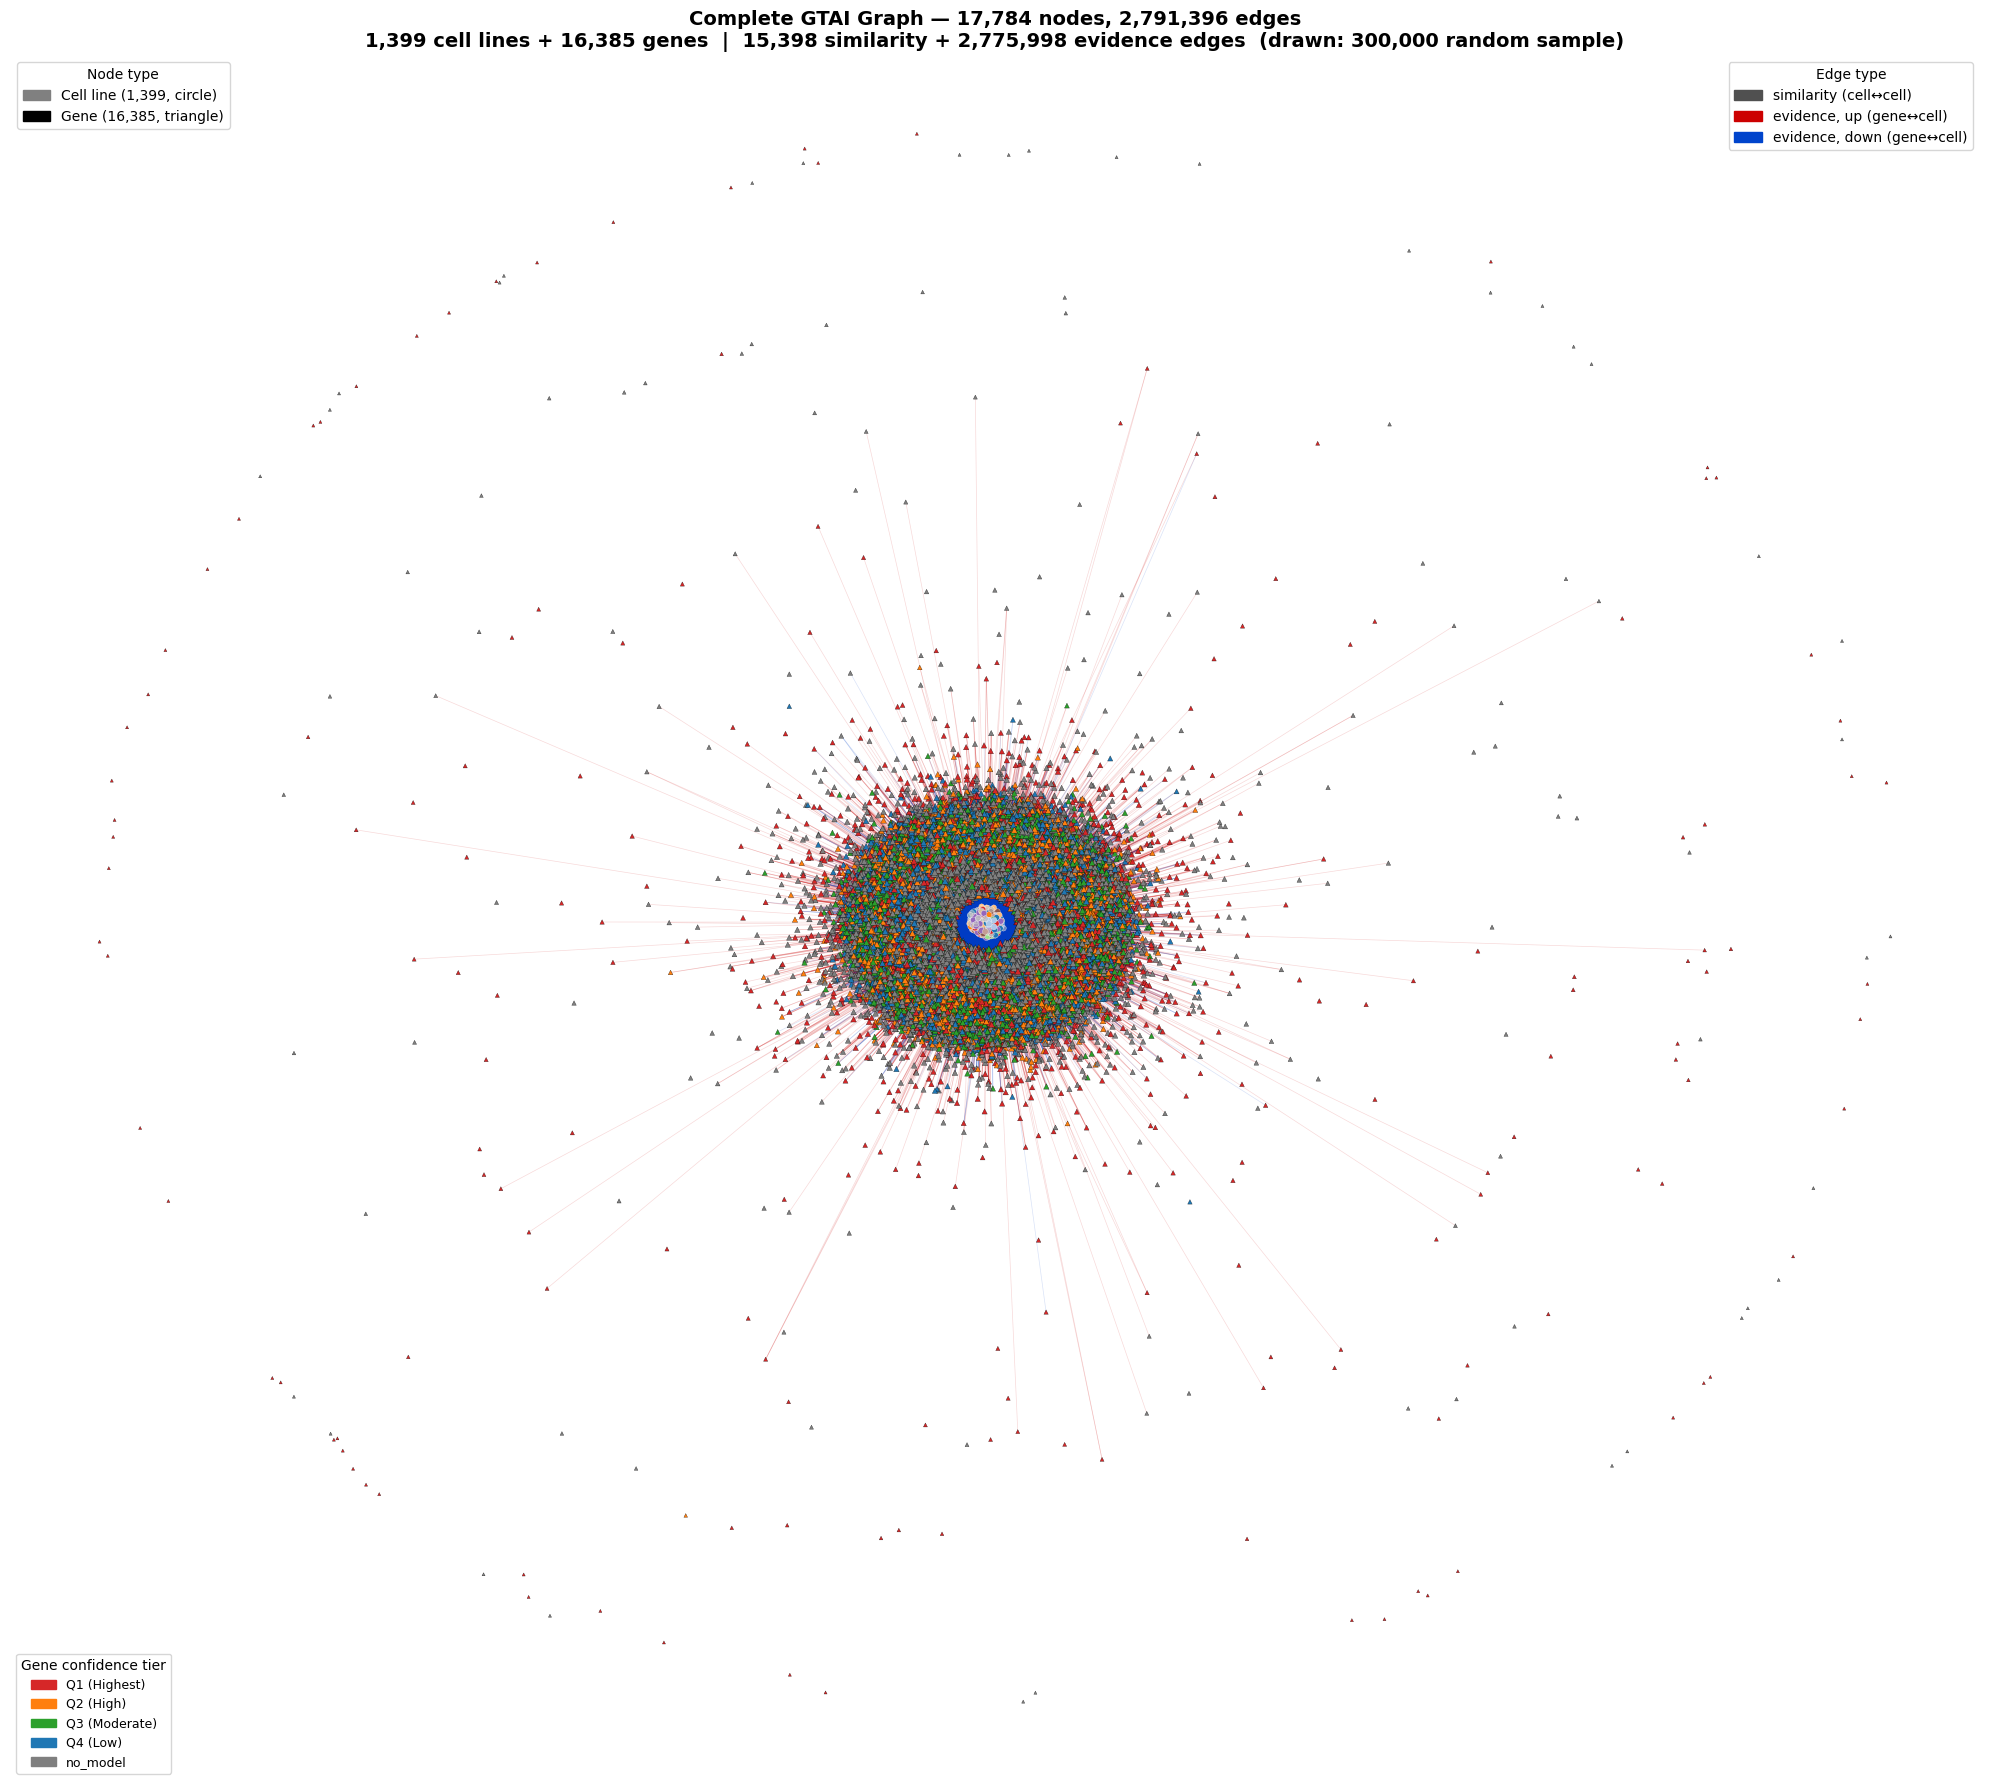

Saved: combined_graph_full.png


In [80]:
fig, ax = plt.subplots(figsize=(20, 18))

nx.draw_networkx_edges(G, pos, edgelist=sim_edges, ax=ax,
                        alpha=0.06, width=0.35, edge_color='#505050')

# Drawing all ~2.8M evidence edges takes 10+ min and ~1 GB and gives a saturated
# hairball. Draw a fixed random sample; the layout above still uses the FULL graph.
MAX_EVIDENCE_EDGES_TO_DRAW = 300_000          # set to None to draw every edge
evi_draw = evi_edges
if MAX_EVIDENCE_EDGES_TO_DRAW and len(evi_edges) > MAX_EVIDENCE_EDGES_TO_DRAW:
    _idx = np.random.default_rng(42).choice(len(evi_edges), MAX_EVIDENCE_EDGES_TO_DRAW,
                                            replace=False)
    evi_draw = [evi_edges[i] for i in _idx]
evi_up   = [(u, v) for u, v, d in evi_draw if d['direction'] == 'up']
evi_down = [(u, v) for u, v, d in evi_draw if d['direction'] == 'down']
nx.draw_networkx_edges(G, pos, edgelist=evi_up, ax=ax,
                        alpha=0.15, width=0.5, edge_color='#cc0000')
nx.draw_networkx_edges(G, pos, edgelist=evi_down, ax=ax,
                        alpha=0.15, width=0.5, edge_color='#0044cc')

nx.draw_networkx_nodes(G, pos, nodelist=cell_set, ax=ax,
                        node_color=cell_colors, node_size=cell_sizes,
                        node_shape='o', linewidths=0.2, edgecolors='white')
nx.draw_networkx_nodes(G, pos, nodelist=gene_set, ax=ax,
                        node_color=gene_colors, node_size=gene_sizes,
                        node_shape='^', linewidths=0.2, edgecolors='black')

node_legend = [mpatches.Patch(color='grey', label=f'Cell line ({len(cell_set):,}, circle)'),
               mpatches.Patch(color='black', label=f'Gene ({len(gene_set):,}, triangle)')]
edge_legend = [mpatches.Patch(color='#505050', label='similarity (cell↔cell)'),
               mpatches.Patch(color='#cc0000', label='evidence, up (gene↔cell)'),
               mpatches.Patch(color='#0044cc', label='evidence, down (gene↔cell)')]
tier_legend = [mpatches.Patch(color=c, label=t) for t, c in tier_palette.items()]

leg1 = ax.legend(handles=node_legend, loc='upper left', fontsize=10, title='Node type')
leg2 = ax.legend(handles=edge_legend, loc='upper right', fontsize=10, title='Edge type')
ax.add_artist(leg1); ax.add_artist(leg2)
ax.legend(handles=tier_legend, loc='lower left', fontsize=9, title='Gene confidence tier')

ax.set_title(f'Complete GTAI Graph — {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges\n'
             f'{len(cell_set):,} cell lines + {len(gene_set):,} genes  |  '
             f'{len(sim_edges):,} similarity + {len(evi_edges):,} evidence edges'
             + (f'  (drawn: {len(evi_draw):,} random sample)' if len(evi_draw) < len(evi_edges) else ''),
             fontsize=14, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('combined_graph_full.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: combined_graph_full.png")

#### Zoomed subgraph: top-degree genes + their evidence neighborhoods

Ego subgraph: 1378 nodes (8 focal genes), 4892 evidence edges


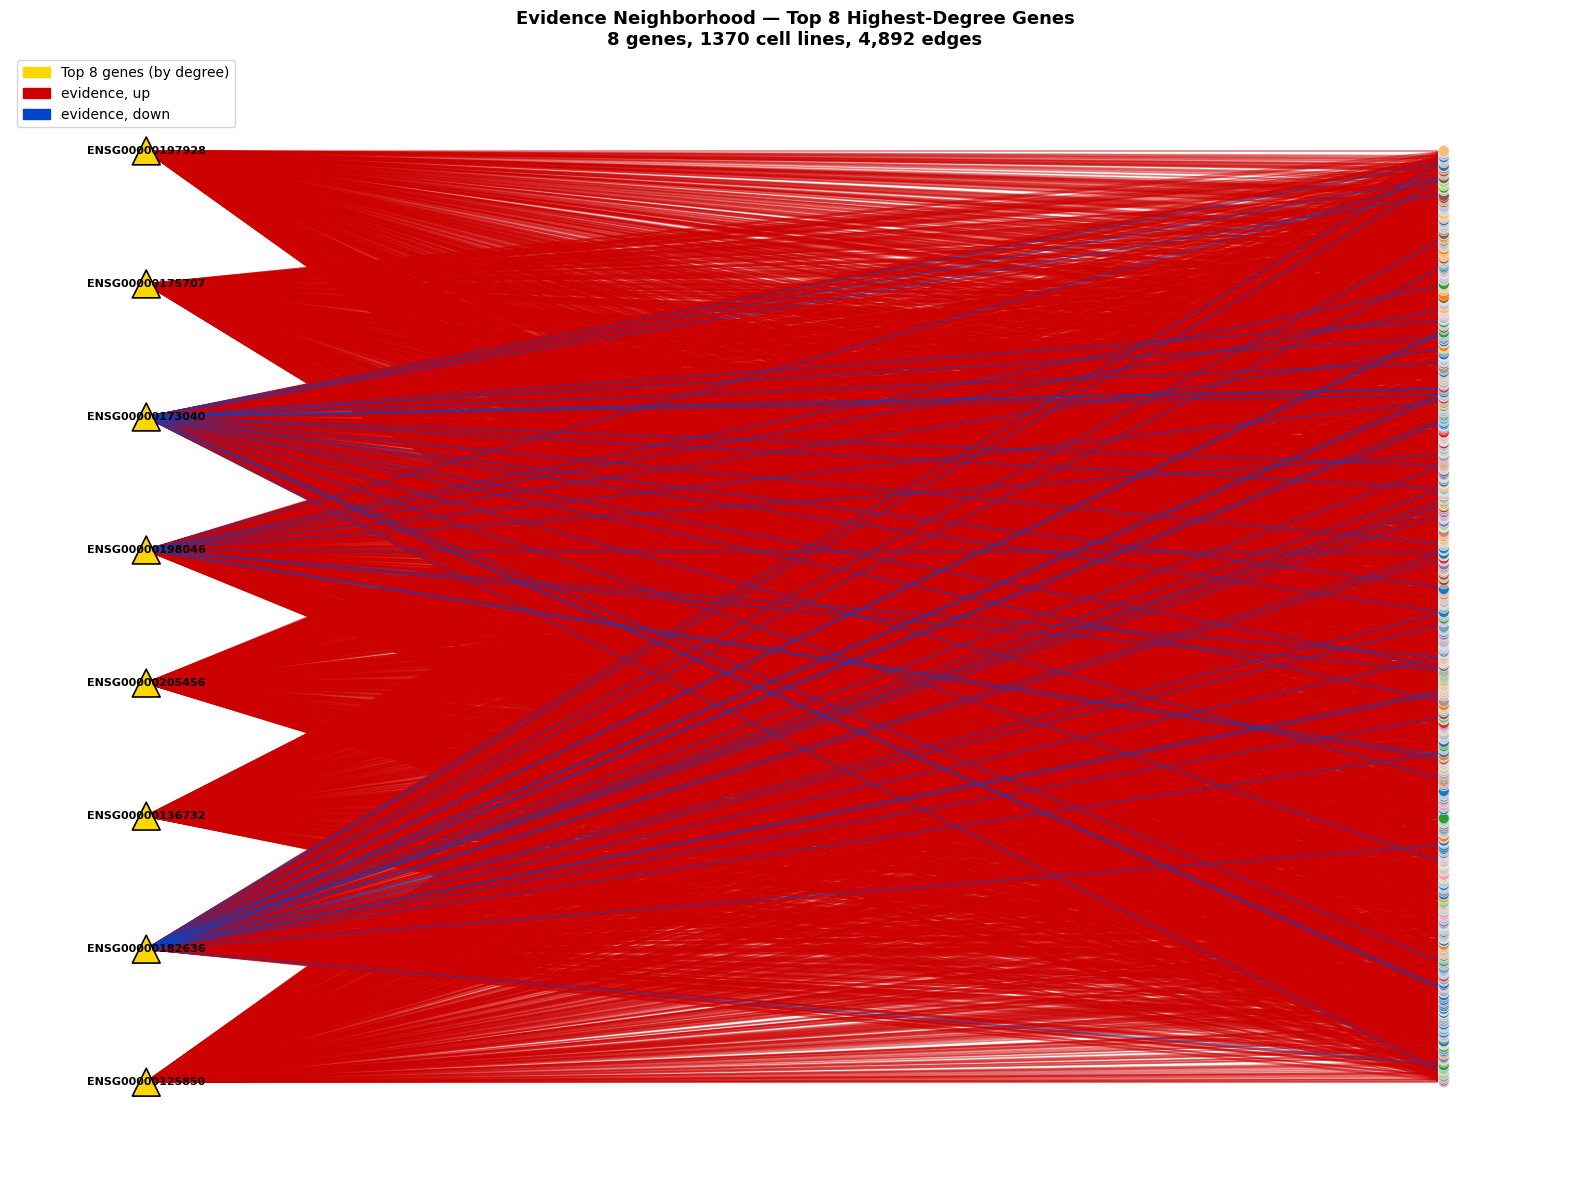

Saved: combined_graph_gene_ego.png

Focal genes:
                 degree  mean_abs_theta confidence_tier
gene_id                                                
ENSG00000173040     660       29.348116        Q4 (Low)
ENSG00000198046     628       23.809246       Q2 (High)
ENSG00000197928     610       23.631336        no_model
ENSG00000125850     601        7.540678    Q1 (Highest)
ENSG00000175707     601        9.914370    Q1 (Highest)
ENSG00000182636     599       33.811990       Q2 (High)
ENSG00000136732     597        9.047003    Q1 (Highest)
ENSG00000205456     596       36.367429        no_model


In [81]:
N_TOP_GENES = 8
top_genes = gene_nodes.nlargest(N_TOP_GENES, 'degree').index.tolist()

# Build ego subgraph: top genes + all their evidence neighbors
ego_nodes = set(top_genes)
for g in top_genes:
    ego_nodes.update(G.neighbors(g))

G_ego = G.subgraph(ego_nodes).copy()

# Keep only evidence edges in this view (drop cell-cell similarity clutter)
evi_only_edges = [(u, v) for u, v, d in G_ego.edges(data=True) if d.get('edge_type') == 'evidence']
G_ego_evi = G_ego.edge_subgraph(evi_only_edges).copy()

print(f"Ego subgraph: {G_ego_evi.number_of_nodes()} nodes "
      f"({len(top_genes)} focal genes), {G_ego_evi.number_of_edges()} evidence edges")

pos_ego = nx.bipartite_layout(G_ego_evi, nodes=top_genes) if nx.is_connected(G_ego_evi.to_undirected()) \
    else nx.spring_layout(G_ego_evi, k=0.6, iterations=100, seed=42)

fig, ax = plt.subplots(figsize=(16, 12))

genes_ego = [n for n in G_ego_evi.nodes() if G_ego_evi.nodes[n].get('node_type') == 'gene']
cells_ego = [n for n in G_ego_evi.nodes() if G_ego_evi.nodes[n].get('node_type') == 'cell_line']

up_e   = [(u, v) for u, v, d in G_ego_evi.edges(data=True) if d['direction'] == 'up']
down_e = [(u, v) for u, v, d in G_ego_evi.edges(data=True) if d['direction'] == 'down']
nx.draw_networkx_edges(G_ego_evi, pos_ego, edgelist=up_e, ax=ax,
                        alpha=0.5, width=1.2, edge_color='#cc0000')
nx.draw_networkx_edges(G_ego_evi, pos_ego, edgelist=down_e, ax=ax,
                        alpha=0.5, width=1.2, edge_color='#0044cc')

gene_colors_ego = ['gold' if g in top_genes else '#7f7f7f' for g in genes_ego]
cell_colors_ego = [lineage_colors.get(node_lineage.get(c, 'Unknown'), default_color) for c in cells_ego]

nx.draw_networkx_nodes(G_ego_evi, pos_ego, nodelist=genes_ego, ax=ax,
                        node_color=gene_colors_ego, node_shape='^',
                        node_size=400, linewidths=1.2, edgecolors='black')
nx.draw_networkx_nodes(G_ego_evi, pos_ego, nodelist=cells_ego, ax=ax,
                        node_color=cell_colors_ego, node_shape='o',
                        node_size=60, linewidths=0.3, edgecolors='white')

nx.draw_networkx_labels(G_ego_evi, pos_ego,
                         labels={g: g for g in genes_ego}, ax=ax,
                         font_size=8, font_weight='bold')

legend = [mpatches.Patch(color='gold', label=f'Top {N_TOP_GENES} genes (by degree)'),
          mpatches.Patch(color='#cc0000', label='evidence, up'),
          mpatches.Patch(color='#0044cc', label='evidence, down')]
ax.legend(handles=legend, loc='upper left', fontsize=10)

ax.set_title(f'Evidence Neighborhood — Top {N_TOP_GENES} Highest-Degree Genes\n'
             f'{len(genes_ego)} genes, {len(cells_ego)} cell lines, '
             f'{G_ego_evi.number_of_edges():,} edges', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig('combined_graph_gene_ego.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("Saved: combined_graph_gene_ego.png")
print("\nFocal genes:")
print(gene_nodes.loc[top_genes, ['degree', 'mean_abs_theta', 'confidence_tier']])

#### CELL LINE SIMILARITIES WITH LEIDEN'S CLUSTERING

In [82]:
def build_leiden_clusters(G, edge_type='similarity', weight_attr='weight',
                           resolution=1.0, seed=42):
    """
    Community detection on the cell-line similarity backbone via Leiden.

    Only edges tagged `edge_type` are clustered (default: 'similarity', i.e.
    cell↔cell cosine-similarity edges). Gene nodes and evidence edges are
    excluded — mixing edge semantics would bias modularity toward whichever
    edge type dominates in count/magnitude.

    Uses RBConfigurationVertexPartition (igraph/leidenalg's modularity-style
    partition, same default Scanpy uses for single-cell clustering).

    Parameters
    ----------
    G           : networkx.Graph — combined heterogeneous graph
    edge_type   : str  — which edge_type attribute to cluster on
    weight_attr : str  — edge attribute used as Leiden weight
    resolution  : float — RBConfiguration resolution (higher → more, smaller clusters)
    seed        : int  — RNG seed for reproducibility

    Returns
    -------
    cluster_labels : dict  — cell_line_id → cluster_id (int)
    modularity     : float — igraph modularity of the resulting partition
    n_clusters     : int
    """
    sim_edges = [(u, v, d.get(weight_attr, 1.0)) for u, v, d in G.edges(data=True)
                 if d.get('edge_type') == edge_type]

    if not sim_edges:
        raise ValueError(f"No edges found with edge_type='{edge_type}'.")

    nodes = sorted({u for u, v, w in sim_edges} | {v for u, v, w in sim_edges})
    node_idx = {n: i for i, n in enumerate(nodes)}

    g_ig = ig.Graph(n=len(nodes))
    g_ig.vs['name'] = nodes
    g_ig.add_edges([(node_idx[u], node_idx[v]) for u, v, w in sim_edges])
    g_ig.es['weight'] = [w for u, v, w in sim_edges]

    partition = la.find_partition(
        g_ig, la.RBConfigurationVertexPartition,
        weights='weight', resolution_parameter=resolution, seed=seed
    )

    cluster_labels = {nodes[i]: int(partition.membership[i]) for i in range(len(nodes))}
    modularity = g_ig.modularity(partition.membership, weights='weight')
    n_clusters = len(set(partition.membership))

    return cluster_labels, modularity, n_clusters

In [83]:
# ── Run Leiden clustering, attach labels, verify against known lineages ──

cluster_labels, modularity, n_clusters = build_leiden_clusters(
    G, edge_type='similarity', weight_attr='weight', resolution=1.0, seed=42
)

# Attach cluster id as a node attribute (cell-line nodes only)
for n, cl in cluster_labels.items():
    G.nodes[n]['leiden_cluster'] = cl

print(f"Clusters found: {n_clusters}")
print(f"Modularity:     {modularity:.4f}")

cluster_sizes = pd.Series(cluster_labels).value_counts().sort_values(ascending=False)
print(f"\nCluster size — min: {cluster_sizes.min()}, max: {cluster_sizes.max()}, "
      f"mean: {cluster_sizes.mean():.1f}, median: {cluster_sizes.median():.0f}")

# ── Verification: does Leiden recover known lineage structure? ──
# (this is the check — clusters with no relation to biology would mean the
#  resolution/weighting needs revisiting before trusting them downstream)
purity_rows = []
for cl_id in cluster_sizes.index:
    members = [n for n, c in cluster_labels.items() if c == cl_id]
    lineages = node_lineage.reindex(members).fillna('Unknown')
    top_lineage_counts = lineages.value_counts()
    purity = top_lineage_counts.iloc[0] / len(members)
    purity_rows.append({
        'cluster': cl_id, 'size': len(members),
        'top_lineage': top_lineage_counts.index[0], 'purity': purity
    })

purity_df = pd.DataFrame(purity_rows).sort_values('size', ascending=False)
weighted_purity = (purity_df['purity'] * purity_df['size']).sum() / purity_df['size'].sum()

print(f"\nSize-weighted lineage purity: {weighted_purity:.3f}  "
      f"(1.0 = every cluster is a single lineage; compare to your same-lineage "
      f"edge fraction of {same_pct:.1f}% as a rough floor)")
print(f"\nTop 10 clusters by size:")
print(purity_df.head(10).to_string(index=False))

Clusters found: 19
Modularity:     0.8216

Cluster size — min: 15, max: 252, mean: 73.6, median: 59

Size-weighted lineage purity: 0.519  (1.0 = every cluster is a single lineage; compare to your same-lineage edge fraction of 54.6% as a rough floor)

Top 10 clusters by size:
 cluster  size            top_lineage   purity
       0   252 central_nervous_system 0.277778
       1   166             colorectal 0.373494
       2   161    upper_aerodigestive 0.329193
       3   113                  ovary 0.353982
       4    88                 breast 0.465909
       5    87                   skin 0.827586
       6    78                   lung 0.730769
       7    69            soft_tissue 0.333333
       8    65             lymphocyte 0.815385
       9    59                   lung 0.491525


In [84]:
def query_network(gene=None, cell_line=None, G=G, edges_df=edges_df,
                   cluster_labels=None, node_lineage=node_lineage, top_n=10):
    """
    Look up gene ↔ cell-line relationships using the built graph + Leiden clusters.
    Does NOT re-run clustering — reads the labels build_leiden_clusters() produced.

    Modes (pass one or both)
    -------------------------
    gene only      : rank Leiden clusters by evidence strength (mean |θ̂|) for this gene
    cell_line only : report this cell line's cluster, its lineage mix, and its
                     top evidence genes
    both           : the two reports above, plus the direct gene↔cell edge if
                     it survived the |θ̂| > threshold cut

    Parameters
    ----------
    gene           : str or None — Ensembl gene ID (must be a gene node in G)
    cell_line      : str or None — Cellosaurus ID (must be a cell_line node in G)
    cluster_labels : dict or None — falls back to G's 'leiden_cluster' node attr

    Returns
    -------
    dict — keys present depend on which identifiers were passed
    """
    if gene is None and cell_line is None:
        raise ValueError("Provide at least one of `gene` or `cell_line`.")

    if cluster_labels is None:
        cluster_labels = {n: d['leiden_cluster'] for n, d in G.nodes(data=True)
                           if 'leiden_cluster' in d}

    result = {}

    # ── Gene provided: rank clusters by evidence strength ──
    if gene is not None:
        if gene not in G or G.nodes[gene].get('node_type') != 'gene':
            raise KeyError(f"Gene '{gene}' not found in graph.")

        g_edges = edges_df[edges_df['gene'] == gene].copy()
        g_edges['cluster'] = g_edges['cell_line'].map(cluster_labels)

        cluster_summary = (g_edges.groupby('cluster')
                            .agg(n_cells=('cell_line', 'size'),
                                 mean_abs_theta=('abs_theta', 'mean'),
                                 frac_up=('direction', lambda s: (s == 'up').mean()))
                            .sort_values('mean_abs_theta', ascending=False))

        result['gene'] = gene
        result['confidence_tier'] = G.nodes[gene].get('confidence_tier')
        result['n_evidence_cells'] = len(g_edges)
        result['cluster_ranking'] = cluster_summary
        result['top_cells'] = g_edges.nlargest(top_n, 'abs_theta')[
            ['cell_line', 'theta', 'direction', 'evidence_type', 'cluster']]

        print(f"Gene: {gene}  (confidence tier: {result['confidence_tier']})")
        print(f"Evidence cells: {result['n_evidence_cells']}")
        print(f"\nCluster ranking (by mean |θ̂|):")
        print(cluster_summary.head(top_n).to_string())
        print(f"\nTop {top_n} cell lines:")
        print(result['top_cells'].to_string(index=False))

    # ── Cell line provided: cluster + lineage + top genes ──
    if cell_line is not None:
        if cell_line not in G or G.nodes[cell_line].get('node_type') != 'cell_line':
            raise KeyError(f"Cell line '{cell_line}' not found in graph.")

        cl_id = cluster_labels.get(cell_line)
        cluster_members = [n for n, c in cluster_labels.items() if c == cl_id]
        cluster_lineages = node_lineage.reindex(cluster_members).value_counts()

        c_edges = edges_df[edges_df['cell_line'] == cell_line].sort_values(
            'abs_theta', ascending=False)

        result['cell_line'] = cell_line
        result['lineage'] = node_lineage.get(cell_line, 'Unknown')
        result['cluster'] = cl_id
        result['cluster_size'] = len(cluster_members)
        result['cluster_lineage_breakdown'] = cluster_lineages
        result['top_genes'] = c_edges.head(top_n)[
            ['gene', 'theta', 'direction', 'evidence_type']]

        print(f"Cell line: {cell_line}  (lineage: {result['lineage']})")
        print(f"Leiden cluster: {cl_id}  (size={result['cluster_size']})")
        print(f"\nCluster lineage breakdown:")
        print(cluster_lineages.head(10).to_string())
        print(f"\nTop {top_n} evidence genes for this cell line:")
        print(result['top_genes'].to_string(index=False))

    # ── Both provided: direct edge lookup ──
    if gene is not None and cell_line is not None:
        edge_row = edges_df[(edges_df['gene'] == gene) & (edges_df['cell_line'] == cell_line)]
        if len(edge_row):
            result['direct_edge'] = edge_row.iloc[0].to_dict()
            print(f"\nDirect evidence edge {gene} ↔ {cell_line}:")
            print(edge_row.to_string(index=False))
        else:
            result['direct_edge'] = None
            print(f"\nNo evidence edge above threshold between {gene} and {cell_line} "
                  f"(|θ̂| below 2.0, or one/both unmeasured).")

    return result

#### gene-conditioned similarity

In [85]:
def gene_conditioned_neighbors(query_gene, cell_line, E_final, node_lineage,
                                top_m=200, k=10, corr_method='spearman'):
    """
    Gene-conditioned RNA-similarity neighbor lookup.

    Parameters
    ----------
    query_gene   : str — Ensembl gene ID the user is asking about
    cell_line    : str — Cellosaurus ID to find neighbors for
    E_final      : DataFrame — cells x genes RNA matrix
    node_lineage : Series — cell_line -> lineage (for display only)
    top_m        : int — panel size: genes most correlated with query_gene
    k            : int — neighbors to return
    corr_method  : 'spearman' or 'pearson' — for panel selection

    Returns
    -------
    panel_genes  : list  — the M genes actually used for this query
    neighbors_df : DataFrame — top-k neighbors: similarity, lineage
    """
    if query_gene not in E_final.columns:
        raise KeyError(f"Gene '{query_gene}' not in E_final.")
    if cell_line not in E_final.index:
        raise KeyError(f"Cell line '{cell_line}' not in E_final.")

    # ── Panel selection: genes most correlated with the query gene ──
    gene_vec = E_final[query_gene]
    valid = gene_vec.notna()
    corrs = E_final.loc[valid].corrwith(gene_vec.loc[valid], method=corr_method)
    corrs = corrs.drop(index=query_gene, errors='ignore').abs().dropna()
    panel_genes = corrs.nlargest(top_m).index.tolist()

    # ── Restrict + z-score just this panel ──
    X = E_final[panel_genes].copy()
    X = X.loc[X.notna().sum(axis=1) > 0]
    mu, sd = X.mean(axis=0), X.std(axis=0, ddof=1)
    Xz = ((X - mu) / sd.replace(0, np.nan)).fillna(0.0)

    if cell_line not in Xz.index:
        raise KeyError(f"'{cell_line}' has no data in the {top_m}-gene panel for {query_gene}.")

    sims = cosine_similarity(Xz.values, Xz.loc[[cell_line]].values).flatten()
    sim_series = pd.Series(sims, index=Xz.index).drop(index=cell_line)
    top_k = sim_series.nlargest(k)

    neighbors_df = pd.DataFrame({
        'cell_line': top_k.index,
        'similarity': top_k.values.round(4),
        'lineage': [node_lineage.get(n, 'Unknown') for n in top_k.index]
    })
    return panel_genes, neighbors_df

###

In [86]:
def rank_cell_lines_for_gene(gene_query, G, node_lineage, direction=None, top_n=20):
    """
    Rank cell lines for a queried gene by |theta_hat| edge weight, reading
    everything directly off the graph G.

    Accepts either a gene symbol ('TP53') or an Ensembl ID directly.
    Resolution checks the node's own 'gene_symbol' attribute — the mapping
    lives on the node, not in a separate table.

    Parameters
    ----------
    gene_query   : str — gene symbol ('TP53') or Ensembl ID
    G            : networkx.Graph — the combined graph (genes + cell lines,
                   similarity + evidence edges)
    node_lineage : Series — cell_line -> lineage
    direction    : None / 'up' / 'down' — filter before ranking
    top_n        : int — how many ranked cell lines to return

    Returns
    -------
    DataFrame — rank, cell_line, theta, abs_theta, direction,
                evidence_type, lineage. Empty (not missing) if the gene
                is valid but has zero evidence edges above threshold —
                absence is reported as absence, never returned as noise.
    """
    gene_id = None

    if gene_query in G and G.nodes[gene_query].get('node_type') == 'gene':
        gene_id = gene_query
    else:
        matches = [n for n, d in G.nodes(data=True)
                   if d.get('node_type') == 'gene' and d.get('gene_symbol') == gene_query]
        if matches:
            gene_id = matches[0]

    if gene_id is None:
        n_genes_in_G = sum(1 for _, d in G.nodes(data=True) if d.get('node_type') == 'gene')
        raise KeyError(
            f"'{gene_query}' not found in G. The graph contains {n_genes_in_G} genes "
            f"that survived the mRNA pipeline. Genes are removed by Step 0 (not "
            f"protein-coding in HPA), Step 1 (>20% missing), Step 3 (zero variance) or "
            f"Step 4 (MAD = 0, i.e. more than half the cell lines share one value).\n"
            f"Try: gene_nodes[gene_nodes['gene_symbol'].str.contains('{gene_query}', na=False)] "
            f"to check, or query a high-variance gene instead."
        )

    gene_symbol = G.nodes[gene_id].get('gene_symbol')
    confidence_tier = G.nodes[gene_id].get('confidence_tier')

    # ── Pull evidence edges directly from G's own adjacency ──
    rows = []
    for neighbor, edge_data in G[gene_id].items():
        if edge_data.get('edge_type') != 'evidence':
            continue
        if direction in ('up', 'down') and edge_data.get('direction') != direction:
            continue
        rows.append({
            'cell_line': neighbor,
            'theta': edge_data['theta'],
            'abs_theta': edge_data['abs_theta'],
            'direction': edge_data['direction'],
            'evidence_type': edge_data['evidence_type'],
            'lineage': node_lineage.get(neighbor, 'Unknown'),
        })

    if not rows:
        print(f"'{gene_query}' ({gene_id}" + (f", {gene_symbol}" if gene_symbol else "") +
              ") has no evidence edges" +
              (f" in direction='{direction}'" if direction else "") +
              " above the |theta_hat| threshold — reporting absence, not returning noise.")
        return pd.DataFrame(columns=['rank', 'cell_line', 'theta', 'abs_theta',
                                      'direction', 'evidence_type', 'lineage'])

    ranked_df = (pd.DataFrame(rows)
                 .sort_values('abs_theta', ascending=False)
                 .head(top_n)
                 .reset_index(drop=True))
    ranked_df.insert(0, 'rank', range(1, len(ranked_df) + 1))

    # Resolve Cellosaurus accessions to human-readable cell line names
    cello_name_map = (
        df_cellosaurus
        .set_index('Accession (CVCL_xxxx)')['Identifier (cell line name)']
        .to_dict()
    )
    ranked_df.insert(2, 'cell_line_name',
                     ranked_df['cell_line'].map(cello_name_map).fillna('—'))

    print(f"Gene: {gene_query} ({gene_id})" +
          (f"  |  symbol: {gene_symbol}" if gene_symbol else "") +
          f"  |  confidence tier: {confidence_tier}")
    print(f"Total evidence cells: {len(rows)}  |  showing top {len(ranked_df)}")

    return ranked_df

In [87]:
result = rank_cell_lines_for_gene(
    gene_query="TP53",
    G=G,
    node_lineage=node_lineage,
    top_n=20
)
print(result.to_string(index=False))

Gene: TP53 (ENSG00000141510)  |  symbol: TP53  |  confidence tier: Q1 (Highest)
Total evidence cells: 153  |  showing top 20
 rank cell_line cell_line_name     theta  abs_theta direction evidence_type                lineage
    1 CVCL_4W66           NP-8 -4.844337   4.844337      down     mRNA_only central_nervous_system
    2 CVCL_2607          MM386 -4.743280   4.743280      down     mRNA_only                   skin
    3 CVCL_1113         CAL-72 -4.638103   4.638103      down     mRNA_only                   bone
    4 CVCL_2078          JJN-3 -4.509707   4.509707      down     mRNA_only            plasma_cell
    5 CVCL_1683          SCC-3 -4.383353   4.383353      down     mRNA_only             lymphocyte
    6 CVCL_2681     PE/CA-PJ49 -4.268000   4.268000      down     mRNA_only    upper_aerodigestive
    7 CVCL_WU66          OS252 -4.154065   4.154065      down     mRNA_only                   bone
    8 CVCL_LK56    NCC-LMS1-C1 -4.085674   4.085674      down     mRNA_only        

### Known limitations (PoC)

- **Tiny-MAD inflation.** Step 4 divides by 1.4826 × MAD. Genes whose MAD is not zero but very small (mostly-unexpressed genes with a few low values) get very large z-scores, so their |θ̂| is inflated (top-degree genes show mean |θ̂| of 24–36). These genes dominate degree/hub rankings. Genes with MAD = 0 (3,510) are dropped entirely, which removes many lineage-restricted markers.
- **Mixed train/test splits.** 10,133 genes were trained before the gene/cell order was made deterministic (`sorted(...)` in the alignment cell); 1,326 after. Each gene uses a valid 70/30 split with the same settings, but not the identical split. Set `FORCE_RETRAIN = True` once to put every gene on the same split (~5 h on a T4).
- **Lineage recovery is modest.** Leiden size-weighted lineage purity (≈0.52) does not exceed the same-lineage fraction of the k-NN edges (≈55%).
- **Single split, no CV.** Per-gene confidence is one held-out 70/30 split, not cross-validated.


# REFERENCES

- [1] M. Ghandi et al., "Next-generation characterization of the Cancer Cell Line Encyclopedia," Nature, vol. 569, pp. 503–508, 2019.
- [2] J. Barretina et al., "The Cancer Cell Line Encyclopedia enables predictive modelling of anticancer drug sensitivity," Nature, vol. 483, pp. 603–607, 2012.
- [3] D.P. Nusinow et al., "Quantitative Proteomics of the Cancer Cell Line Encyclopedia," Cell, vol. 180, no. 2, pp. 387–402, 2020.
- [4] M. Uhlén et al., "Tissue-based map of the human proteome," Science, vol. 347, no. 6220, 1260419, 2015.
- [5] A. Bairoch, "The Cellosaurus, a Cell-Line Knowledge Resource," J. Biomol. Tech., vol. 29, no. 2, pp. 25–38, 2018.
- [6] V.A. Traag, L. Waltman, and N.J. Van Eck, "From Louvain to Leiden: guaranteeing well-connected communities," Sci. Rep., vol. 9, 5233, 2019.
- [7] L. Breiman, "Random Forests," Mach. Learn., vol. 45, no. 1, pp. 5–32, 2001.
- [8] S.A. Stouffer et al., The American Soldier: Adjustment During Army Life, vol. 1. Princeton, NJ: Princeton Univ. Press, 1949.
- [9] T.M.J. Fruchterman and E.M. Reingold, "Graph drawing by force-directed placement," Softw. Pract. Exp., vol. 21, no. 11, pp. 1129–1164, 1991.
- [10] O. Troyanskaya et al., "Missing value estimation methods for DNA microarrays," Bioinformatics, vol. 17, no. 6, pp. 520–525, 2001.
- [11] B. Iglewicz and D.C. Hoaglin, Volume 16: How to Detect and Handle Outliers. Milwaukee, WI: ASQC Quality Press, 1993.
- [12] W. Dong, C. Moses, and K. Li, "Efficient k-nearest neighbor graph construction for generic similarity measures," in Proc. WWW '11, 2011, pp. 577–586.
- [13] P.J. Rousseeuw and C. Croux, "Alternatives to the Median Absolute Deviation," J. Amer. Statist. Assoc., vol. 88, no. 424, pp. 1273–1283, 1993.
- [14] A.A. Hagberg, D.A. Schult, and P.J. Swart, "Exploring Network Structure, Dynamics, and Function using NetworkX," in Proc. SciPy 2008, pp. 11–15.
- [15] F. Pedregosa et al., "Scikit-learn: Machine Learning in Python," J. Mach. Learn. Res., vol. 12, pp. 2825–2830, 2011.
- [16] V.A. Traag, leidenalg [Python package], 2024. [Online]. Available: https://github.com/vtraag/leidenalg
- [17] J. Li et al., "Characterization of Human Cancer Cell Lines by Reverse-Phase Protein Arrays," Cancer Cell, vol. 31, no. 2, pp. 225–239, 2017.
- [18] T. Guo et al., "Rapid mass spectrometric conversion of tissue biopsy samples into permanent quantitative digital proteome maps," Nat. Med., vol. 21, pp. 407–415, 2015.
- [19] J.C. Costello et al., "A community effort to assess and improve drug sensitivity prediction algorithms," Nat. Biotechnol., vol. 32, pp. 1202–1212, 2014.
